# Gaussian Process the LC

In [1]:
import os
#COCO_PATH=os.environ['COCO_PATH']
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
DATALC_PATH = COCO_PATH+"/Inputs/Photometry/4_LCs_late_extrapolated/"
DATASPEC_PATH = COCO_PATH+"/Inputs/Spectroscopy/"

DATAINFO_PATH= COCO_PATH+"Inputs/SNe_Info/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/"

OUTPUT_DIR = COCO_PATH+"Outputs/"

import sys
sys.path.insert(0, COCO_PATH+'what_the_flux/')
import what_the_flux as wtf

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import scipy.optimize as opt

import george
from george.kernels import ExpSquaredKernel, ConstantKernel, Matern32Kernel

%matplotlib inline

In [3]:
import csv

with open('/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Photometry/4_LCs_late_extrapolated/AT2017gfo.dat', newline="") as infile, open("AT2017gfo.dat", "w", newline="") as outfile:
    reader = csv.reader(infile)
    writer = csv.writer(outfile, delimiter="\t")
    for row in reader:
        writer.writerow(row)

In [4]:
info_objects = pd.read_csv(DATAINFO_PATH+'info.dat', comment='#', delimiter=' ')
name_type = dict(zip(info_objects['Name'], info_objects['Type']))

se_sne = [row.Name for i,row in info_objects.iterrows() if row.Type in ['IIb', 'Ib', 'Ic', 'Ic-BL', 'Ibc-pec']]
hydr_sne = [row.Name for i,row in info_objects.iterrows() if row.Type in ['IIn', 'II', 'IIL', 'IIP', '1987A', '87A']]

In [5]:
color_dict = {'Bessell_U': 'blue', 'Bessell_B': 'royalblue','Bessell_V':  'limegreen',
              'Bessell_R':  'red', 'Bessell_I':  'mediumvioletred',
              'sdss_g':'darkgreen','ptf_g':'darkgreen', "sdss_g'":'darkgreen','sdss_i':'indianred',
              "sdss_i'":'indianred','sdss_r': 'darkred', "sdss_r'":'darkred','sdss_z':'sienna', "sdss_z'":'sienna',
              'sdss_u': 'darkblue', "sdss_u'": 'darkblue', 'Y':'salmon','H':'darkred', 'J':  'k',
              'Ks':  'brown','K':  'brown', 'swift_UVW1':'indigo', 'swift_UVW2':'darkblue',
               'swift_UVM2':'darkmagenta','swift_U':'plum','swift_V':'teal','swift_B':'powderblue'}

mark_dict = {'Bessell_U': 'o','Bessell_B': 'o', 'Bessell_V':'o', 'Bessell_R':'o', 'Bessell_I': 'o', 
             'sdss_g':'s','ptf_g':'s', "sdss_g'":'s', 'sdss_i':'s', "sdss_i'":'s',
                'sdss_r':'s', "sdss_r'":'s', 'sdss_z':'s', "sdss_z'":'s', 'sdss_u': 's', "sdss_u'": 's',
                'Y':  'o','H':  'o', 'J':  'o', 'Ks':  'o','K':  'o',
                'swift_UVW1':'D', 'swift_UVW2':'D', 'swift_UVM2':'D', 'swift_U':'D',
                'swift_V':'D', 'swift_B':'D'}

#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y']
#exclude_filt = ['KS']

pre_bump = ['SN2011dh','SN1993J','SN2008D','SN2011fu','SN2006aj','SN1987A','SN2013df']


In [7]:
color_dict = {
    # Existing matches from your example
    'Swope_i': 'indianred',
    'FourStar_H': 'darkred',
    'FourStar_J': 'black',
    'DECam_i': 'orangered',
    'DECam_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FourStar_Ks': 'brown',
    'UVOT_U': 'teal',
    'Skymapper_i': 'slateblue',
    'Sinistro_g': 'darkgreen',
    'Sinistro_r': 'crimson',
    'Skymapper_r': 'deeppink',
    'Skymapper_g': 'forestgreen',
    'EFOSC2_V': 'limegreen',
    'Sinistro_i': 'firebrick',
    'DECam_r': 'darkorange',
    'DECam_g': 'mediumspringgreen',
    'DECam_u': 'navy',
    'Swope_V': 'green',
    'FourStar_J1': 'dimgray',
    'Swope_B': 'royalblue',
    'Swope_r': 'red',
    'Swope_g': 'darkseagreen',
    'EFOSC2_U': 'blue',
    'Sinistro_V': 'mediumaquamarine',
    'Sinistro_z': 'sienna',
    'IMACS_r': 'darkred',
    'LRIS_I': 'mediumvioletred',
    'SOFI_H': 'firebrick',
    'SOFI_Ks': 'saddlebrown',

    # New assignments (color-coded by band)
    'VISTA_Ks': 'saddlebrown',
    'VISTA_J': 'dimgray',
    'VISTA_Y': 'salmon',
    'FLAMINGOS-2_Ks': 'sienna',
    'UVOT_M2': 'darkviolet',
    'UVOT_W1': 'purple',
    'UVOT_W2': 'indigo',
    'HSC_z': 'darkslategray',
    'GFC_i': 'firebrick',
    'GFC_y': 'goldenrod',
    'GFC_z': 'maroon',
    'GFC_r': 'tomato',
    'SIRIUS_H': 'darkred',
    'SIRIUS_J': 'black',
    'SIRIUS_Ks': 'brown',
    'T80Cam_g': 'seagreen',
    'GROND_H': 'maroon',
    'GROND_J': 'dimgray',
    'GROND_K': 'saddlebrown',
    'GROND_g': 'mediumseagreen',
    'GROND_i': 'orangered',
    'GROND_r': 'crimson',
    'GROND_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FLAMINGOS-2_H': 'firebrick',
    'IMACS_i': 'orangered',
    'FLAMINGOS-2_J': 'black',
    'UVOT_B': 'dodgerblue',
    'GMOS_g': 'green',
    'GMOS_i': 'indianred',
    'GMOS_r': 'red',
    'GMOS_z': 'darkslategray',
    'FORS2_R': 'crimson',
    'VIMOS_z': 'maroon',
    'FORS2_I': 'mediumvioletred',
    'FORS2_B': 'blue',
    'FORS2_V': 'limegreen',
    'ANDICAM_K': 'brown',
    'MOIRCS_Ks': 'sienna',
    'HAWKI_Ks': 'brown'
}

exclude_filt = []
#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'FourStar_J1',
#                'RetroCam_Y', 'RetroCam_H', 'RetroCam_J', 'SOFI_H', 'SOFI_Ks']

# mark_dict = {
#     # Swope
#     'Swope_i': 'o',
#     'Swope_V': 'o',
#     'Swope_B': 'o',
#     'Swope_r': 'o',
#     'Swope_g': 'o',

#     # FourStar
#     'FourStar_H': 'o',
#     'FourStar_J': 'o',
#     'FourStar_Ks': 'o',
#     'FourStar_J1': 'o',

#     # RetroCam
#     'RetroCam_Y': 'o',
#     'RetroCam_H': 'o',
#     'RetroCam_J': 'o',

#     # SOFI
#     'SOFI_H': 'o',
#     'SOFI_Ks': 'o',

#     # Sinistro
#     'Sinistro_w': 's',
#     'Sinistro_g': 's',
#     'Sinistro_r': 's',
#     'Sinistro_i': 's',
#     'Sinistro_z': 's',
#     'Sinistro_V': 's',

#     # EFOSC2
#     'EFOSC2_V': 'D',
#     'EFOSC2_U': 'D',
#     'EFOSC2_g': 'D',
#     'EFOSC2_r': 'D',
#     'EFOSC2_i': 'D',

#     # LRIS
#     'LRIS_I': 'D',
#     'LRIS_g': 'D',

#     # IMACS
#     'IMACS_r': 's',
#     'IMACS_V1': 's',
#     'IMACS_V2': 's',

#     # DECam
#     'DECam_i': '^',   # triangle up
#     'DECam_z': '^',
#     'DECam_Y': '^',
#     'DECam_u': '^',
#     'DECam_r': '^',
#     'DECam_g': '^',

#     # ACS_WFC
#     'ACS_WFC_F625W': 'v',   # triangle down
#     'ACS_WFC_F475W': 'v',
#     'ACS_WFC_F850W': 'v',
#     'ACS_WFC_F775W': 'v',

#     # WFC3
#     'WFC3_UVIS1_F336W': '*',   # star
#     'WFC3_IR_F160W': '*',
#     'WFC3_IR_F110W': '*',

#     # skymapper
#     'skymapper_g': 'P',   # plus-filled
#     'skymapper_r': 'P',
#     'skymapper_i': 'P',

#     # UVOT
#     'UVOT_U': 'X',   # cross
# }

mark_dict = {
    # Swope (Circle)
    'Swope_i': 'o',
    'Swope_V': 'o',
    'Swope_B': 'o',
    'Swope_r': 'o',
    'Swope_g': 'o',

    # FourStar (Circle)
    'FourStar_H': 'o',
    'FourStar_J': 'o',
    'FourStar_Ks': 'o',
    'FourStar_J1': 'o',
    'FourStar_Ks': 'o',

    # VISTA (Circle - keeping consistent with other IR survey survey data)
    'VISTA_Ks': 'o',
    'VISTA_J': 'o',
    'VISTA_Y': 'o',

    # SOFI (Circle)
    'SOFI_H': 'o',
    'SOFI_Ks': 'o',

    # ANDICAM (Circle)
    'ANDICAM_K': 'o',

    # DECam (Triangle Up)
    'DECam_i': '^',
    'DECam_z': '^',
    'DECam_Y': '^',
    'DECam_r': '^',
    'DECam_g': '^',
    'DECam_u': '^',

    # HSC (Triangle Right - distinct from DECam but similar large imager)
    'HSC_z': '>',

    # MOIRCS (Triangle Right - Subaru)
    'MOIRCS_Ks': '>',

    # FLAMINGOS-2 (Triangle Down - Gemini IR)
    'FLAMINGOS-2_Ks': 'v',
    'FLAMINGOS-2_H': 'v',
    'FLAMINGOS-2_J': 'v',

    # GMOS (Triangle Left - Gemini Optical)
    'GMOS_g': '<',
    'GMOS_i': '<',
    'GMOS_r': '<',
    'GMOS_z': '<',

    # FORS2 (Triangle Left - VLT)
    'FORS2_R': '<',
    'FORS2_I': '<',
    'FORS2_B': '<',
    'FORS2_V': '<',

    # VIMOS (Triangle Left - VLT)
    'VIMOS_z': '<',

    # HAWKI (Triangle Left - VLT)
    'HAWKI_Ks': '<',

    # UVOT (Cross)
    'UVOT_M2': 'X',
    'UVOT_W1': 'X',
    'UVOT_U': 'X',
    'UVOT_W2': 'X',
    'UVOT_B': 'X',

    # GFC / Pan-STARRS (Pentagon)
    'GFC_i': 'p',
    'GFC_y': 'p',
    'GFC_z': 'p',
    'GFC_r': 'p',

    # Skymapper (Plus Filled)
    'Skymapper_i': 'P',
    'Skymapper_r': 'P',
    'Skymapper_g': 'P',

    # Sinistro (Square)
    'Sinistro_g': 's',
    'Sinistro_r': 's',
    'Sinistro_i': 's',
    'Sinistro_V': 's',
    'Sinistro_z': 's',

    # IMACS (Square)
    'IMACS_i': 's',
    'IMACS_r': 's',

    # SIRIUS (Diamond - grouped with other medium aperture IR like SOFI/RetroCam? or Diamond like EFOSC2)
    'SIRIUS_H': 'D',
    'SIRIUS_J': 'D',
    'SIRIUS_Ks': 'D',

    # EFOSC2 (Diamond)
    'EFOSC2_V': 'D',
    'EFOSC2_U': 'D',

    # LRIS (Diamond)
    'LRIS_I': 'D',

    # T80Cam (Star - distinct small survey)
    'T80Cam_g': '*',

    # GROND (Hexagon - multi-channel instrument)
    'GROND_H': 'h',
    'GROND_J': 'h',
    'GROND_K': 'h',
    'GROND_g': 'h',
    'GROND_i': 'h',
    'GROND_r': 'h',
    'GROND_z': 'h'
}

In [8]:
def err_to_log10(flux, err_flux):
    flux=np.array(flux, dtype=float)
    err_flux=np.array(err_flux, dtype=float)
    return 1./np.log(10.) * err_flux/flux

def err_from_log10(logflux, logerr_flux):
    return np.log(10.) * 10**logflux * logerr_flux



In [9]:
class SNPhotometryClass():
    """Class with photometry for each object:
            - load the photometry from the DATA folder
            - get the phootmetry in each filter
            - plot the raw photometry 
            - fit the photometry using GP
    """
    
    def __init__(self,snname, verbose=False):
        """
        """
        ## Initialise the class variables
        self.lc_data_path = DATALC_PATH
        self.snname = snname   
        self.set_data_directory(verbose)

    def set_data_directory(self, verbose):
        """
        Set a new data directory path.
        Enables the data directory to be changed by the user.
        """
        SNphotometry_PATH = os.path.join(self.lc_data_path, '%s.dat'%self.snname)
        
        try:
            if verbose: print('Looking for Photometry for %s in%s'%(self.snname, SNphotometry_PATH))
            if os.path.isfile(SNphotometry_PATH):
                if verbose: print ('Got it!')
                self.sn_rawphot_file = SNphotometry_PATH
                pass
            else:
                if not os.path.isdir(self.lc_data_path):
                    print ('I cant find the directory with photometry. Check %s'%self.lc_data_path)
                    pass
                else: 
                    print ('I cant find the file with photometry. Check %s'%SNphotometry_PATH)
                    pass
    
        except Exception as e:
            print (e)

    def load(self, verbose = False):
        """
        Loads a single photometry file.
        with ('MJD', 'Flux', 'Flux_err', 'band')
        
        Parameters
        - verbose
        ----------
        Returns
        - photometry in all filters
        -------
        """
        if verbose: print('Loading %s'%self.sn_rawphot_file)
        try:
            lc_file = np.genfromtxt(self.sn_rawphot_file, dtype=None, encoding="utf-8", 
                                    names=True)
            mask_filt = np.array([f not in exclude_filt for f in lc_file['band']])
            lc_no_badfilters = lc_file[mask_filt]
            mask_filt = np.array([~np.isnan(f) for f in lc_no_badfilters['Flux']])
            self.phot = lc_no_badfilters[mask_filt]
            
            self.avail_filters = np.unique(self.phot['band'])

            self.clipped_phot = self.phot
            print ('Photometry loaded')

            
        except Exception as e:
            print (e)
            print ('Are you sure you gave me the right format? Check documentation in case.')

    def get_availfilter(self, verbose = False):
        """
        get available filter for this SN
        """
        if (not hasattr(self, "phot"))|(not hasattr(self, "avail_filters")):
            self.load()
        return self.avail_filters
        
    def get_singlefilter(self, single_filter, extended_clipped = False, verbose = False):
        """
        Loads from photometry file just 1 filter photometry.
        with ('MJD', 'Flux', 'Flux_err', 'band')
        """
        if not hasattr(self, "phot"):
            self.load()

        if not (isinstance(single_filter, str)):
            print ('Single filter string please')
            return None
        
        if single_filter not in self.avail_filters:
            print ('Looks like the filter you are looking for is not available')
            return None
        
        if extended_clipped:
            if not hasattr(self, "clipped_phot"):
                self.clip_photometry()
            filt_index = self.clipped_phot['band']==single_filter
            return self.clipped_phot[filt_index] 
        else: 
            filt_index = self.phot['band']==single_filter
            return self.phot[filt_index]
        
    def get_mjdpeak(self, verbose = False):
        """
        Loads from photometry for each filter, measure peak for each filter
        get a rough estimate of the paek_mjd
        """
        if not hasattr(self, "phot"):
            self.load()
            
        mjd_peaks_list=[]
        for f in self.avail_filters:
            phot_perfilt = self.get_singlefilter(f)
            mjd_peak = phot_perfilt['MJD'][np.argmax(phot_perfilt['Flux'])]
            mjd_peaks_list.append(mjd_peak)
            
        return np.min(mjd_peaks_list)
    
    def plot_raw_phot(self, filt_list=None, plt_extended_clipped=False, save_fig=False, \
                      save_format='png', output_path_name=None):
        if not hasattr(self, "phot"):
            self.load()
        if (plt_extended_clipped)&(not hasattr(self, "clipped_phot")):
            self.extend_photometry()

        if filt_list:
            filt_toplot = filt_list
        else:
            filt_toplot = self.avail_filters
        fig = plt.figure(1)
        for f in filt_toplot:
            phot_f = self.get_singlefilter(f, extended_clipped=plt_extended_clipped)
            plt.errorbar(phot_f['MJD'], phot_f['Flux'], phot_f['Flux_err'],\
                         marker='.', linestyle='None', label=f)
        plt.legend(loc='best')
        plt.show()
        if save_fig:
            if output_path_name:
                fig.savefig(output_path_name)
            else:
                fig.savefig(self.sn_rawphot_file.replace('.dat', '_raw_photo.%s'%save_format))
        return None

    def plot_GP_fit_phot(self, filt_list=None, save_fig=False, save_format='png', output_path_name=None):
        if not hasattr(self, "phot"):
            self.load()
        
        if not hasattr(self, "gp"):
            self.load()

        if filt_list:
            filt_toplot = filt_list
        else:
            filt_toplot = self.avail_filters
        fig = plt.figure(1)
        for f in filt_toplot:
            phot_f = self.get_singlefilter(f)
            plt.errorbar(phot_f['MJD'], phot_f['Flux'], yerr=phot_f['Flux_err'],\
                         marker='.', linestyle='None', label=f)
        plt.legend(loc='best')
        plt.show()
        if save_fig:
            if output_path_name:
                fig.savefig(output_path_name)
            else:
                fig.savefig(self.sn_rawphot_file.replace('.dat', '_raw_photo.%s'%save_format))
        return None

    def clip_LC_filter(self, filter_name, clipping_mjd_delta = 0.5, pre_bump=False):
        
        def clip_one_point(mjd_unclipped, flux_unclipped, fluxerr_unclipped, filtset_unclipped, instr_unclipped, phase_unclipped, logphase_unclipped, logflux_unclipped, logfluxerr_unclipped, clipping_index):
            mjd_tbc = np.array([mjd_unclipped[clipping_index], mjd_unclipped[clipping_index+1]])
            flux_tbc = np.array([flux_unclipped[clipping_index], flux_unclipped[clipping_index+1]])
            flux_err_tbc = np.array([fluxerr_unclipped[clipping_index], fluxerr_unclipped[clipping_index+1]])
            mjd_avg = np.average(mjd_tbc)
            flux_avg, sum_w = np.average(flux_tbc, weights= 1./(flux_err_tbc)**2, returned=True)
            flux_err_avg = max([np.std(flux_tbc), np.sqrt(1./sum_w)])
            
            # Re-calculate log values directly from the new averaged linear values for accuracy
            t0_fix = self.phot['MJD'][0] - self.phot['Phase'][0]
            phase_avg = mjd_avg - t0_fix
            logphase_avg = np.log10(phase_avg) if phase_avg > 0 else -5.0
            logflux_avg = np.log10(flux_avg) if flux_avg > 0 else -25.0
            logfluxerr_avg = flux_err_avg / (flux_avg * np.log(10)) if flux_avg > 0 else 0.1
            
            clipped_mjd_sorted = np.delete(mjd_unclipped, clipping_index)
            clipped_flux_sorted = np.delete(flux_unclipped, clipping_index)
            clipped_flux_err_sorted = np.delete(fluxerr_unclipped, clipping_index)
            clipped_filtset_sorted = np.delete(filtset_unclipped, clipping_index)
            clipped_instr_sorted = np.delete(instr_unclipped, clipping_index)
            clipped_phase_sorted = np.delete(phase_unclipped, clipping_index)
            clipped_logphase_sorted = np.delete(logphase_unclipped, clipping_index)
            clipped_logflux_sorted = np.delete(logflux_unclipped, clipping_index)
            clipped_logfluxerr_sorted = np.delete(logfluxerr_unclipped, clipping_index)
            
            clipped_mjd_sorted[clipping_index] = mjd_avg
            clipped_flux_sorted[clipping_index] = flux_avg
            clipped_flux_err_sorted[clipping_index] = flux_err_avg
            clipped_phase_sorted[clipping_index] = phase_avg
            clipped_logphase_sorted[clipping_index] = logphase_avg
            clipped_logflux_sorted[clipping_index] = logflux_avg
            clipped_logfluxerr_sorted[clipping_index] = logfluxerr_avg
            
            return clipped_mjd_sorted, clipped_flux_sorted, clipped_flux_err_sorted, clipped_filtset_sorted, clipped_instr_sorted, clipped_phase_sorted, clipped_logphase_sorted, clipped_logflux_sorted, clipped_logfluxerr_sorted
    
        LC_filt = self.get_singlefilter(filter_name)
        mjd_sorted = np.sort(LC_filt['MJD'])
        sort_idx = np.argsort(LC_filt['MJD'])
        
        flux_sorted = LC_filt['Flux'][sort_idx]
        flux_err_sorted = LC_filt['Flux_err'][sort_idx]
        filtset_sorted = LC_filt['FilterSet'][sort_idx]
        instr_sorted = LC_filt['Instr'][sort_idx]
        phase_sorted = LC_filt['Phase'][sort_idx]
        logphase_sorted = LC_filt['Log_Phase'][sort_idx]
        logflux_sorted = LC_filt['Log_Flux'][sort_idx]
        logfluxerr_sorted = LC_filt['Log_Flux_err'][sort_idx]
        
        if pre_bump:
            mask_bump = mjd_sorted>min(mjd_sorted)+10.
            new_mjd_sorted = np.array([round(m,2) for m in mjd_sorted])[mask_bump]
            double = np.where(np.abs(new_mjd_sorted[:-1]-new_mjd_sorted[1:])<clipping_mjd_delta)
            new_flux_sorted = np.copy(flux_sorted)[mask_bump]
            new_flux_err_sorted = np.copy(flux_err_sorted)[mask_bump]
            new_filtset_sorted = np.copy(filtset_sorted)[mask_bump]
            new_Instr_sorted = np.copy(instr_sorted)[mask_bump]
            new_phase_sorted = np.copy(phase_sorted)[mask_bump]
            new_logphase_sorted = np.copy(logphase_sorted)[mask_bump]
            new_logflux_sorted = np.copy(logflux_sorted)[mask_bump]
            new_logfluxerr_sorted = np.copy(logfluxerr_sorted)[mask_bump]
        else:
            new_mjd_sorted = np.array([round(m,2) for m in mjd_sorted])
            double = np.where(np.abs(new_mjd_sorted[:-1]-new_mjd_sorted[1:])<clipping_mjd_delta)
            new_flux_sorted = np.copy(flux_sorted)
            new_flux_err_sorted = np.copy(flux_err_sorted)
            new_filtset_sorted = np.copy(filtset_sorted) 
            new_Instr_sorted = np.copy(instr_sorted) 
            new_phase_sorted = np.copy(phase_sorted)
            new_logphase_sorted = np.copy(logphase_sorted)
            new_logflux_sorted = np.copy(logflux_sorted)
            new_logfluxerr_sorted = np.copy(logfluxerr_sorted)
            
        while len(np.where(np.abs(new_mjd_sorted[:-1]-new_mjd_sorted[1:])<clipping_mjd_delta)[0])>=1:
            tbc_indexes = np.where(np.abs(new_mjd_sorted[:-1]-new_mjd_sorted[1:])<clipping_mjd_delta)[0]
            ind = tbc_indexes[0]
            R = clip_one_point(new_mjd_sorted, new_flux_sorted, new_flux_err_sorted, new_filtset_sorted, new_Instr_sorted, new_phase_sorted, new_logphase_sorted, new_logflux_sorted, new_logfluxerr_sorted, ind)
            new_mjd_sorted, new_flux_sorted, new_flux_err_sorted, new_filtset_sorted, new_Instr_sorted, new_phase_sorted, new_logphase_sorted, new_logflux_sorted, new_logfluxerr_sorted = R

        if pre_bump:
            new_mjd_sorted = np.concatenate([mjd_sorted[~mask_bump], new_mjd_sorted])
            new_flux_sorted = np.concatenate([flux_sorted[~mask_bump], new_flux_sorted])
            new_flux_err_sorted = np.concatenate([flux_err_sorted[~mask_bump], new_flux_err_sorted])
            new_filtset_sorted = np.concatenate([filtset_sorted[~mask_bump], new_filtset_sorted])      
            new_Instr_sorted = np.concatenate([instr_sorted[~mask_bump], new_Instr_sorted])      
            new_phase_sorted = np.concatenate([phase_sorted[~mask_bump], new_phase_sorted])
            new_logphase_sorted = np.concatenate([logphase_sorted[~mask_bump], new_logphase_sorted])
            new_logflux_sorted = np.concatenate([logflux_sorted[~mask_bump], new_logflux_sorted])
            new_logfluxerr_sorted = np.concatenate([logfluxerr_sorted[~mask_bump], new_logfluxerr_sorted])

        new_filter_sorted = np.full(len(new_mjd_sorted), filter_name, dtype='|S20')
        new_LC=[]
        for i in zip(new_mjd_sorted, new_filter_sorted, new_flux_sorted, new_flux_err_sorted, new_filtset_sorted, new_Instr_sorted, new_phase_sorted, new_logphase_sorted, new_logflux_sorted, new_logfluxerr_sorted):
            new_LC.append(i)
        new_LC = np.array(new_LC, LC_filt.dtype)
        
        print (filter_name, 'Before clipping %i, after %i'%(len(mjd_sorted), len(new_LC)))
        return new_LC
    
    def clip_photometry(self, pre_bump=False, verbose = False):
        if not hasattr(self, "phot"):
            self.load()
        
        filt_avail = self.avail_filters
        
        clipping_mjd_delta = 0.01
        LC_clipped = np.array([], self.phot.dtype) 
        for ff in filt_avail:
            LC_xfilter = self.clip_LC_filter(ff, clipping_mjd_delta, pre_bump=pre_bump)
            LC_clipped = np.concatenate([LC_clipped, LC_xfilter])
        self.clipped_phot = LC_clipped
        return None
    
    def get_spec_mjd(self, verbose=False):
        phase_list_file = DATASPEC_PATH + '2_spec_lists_smoothed/' + self.snname+'.list'
        try: 
            parse_phase = np.genfromtxt(phase_list_file, dtype=None, encoding="utf-8")
            return parse_phase['f0']
        except: 
            print ('I looked into %s and I found NO spectra? Ooops'%phase_list_file)
            return np.array([])
            
    # NEW FUNCTION: Mirrors get_spec_mjd but converts the spectra dates to Log_Phase
    def get_spec_log_phase(self, verbose=False):
        spec_mjds = self.get_spec_mjd(verbose)
        if len(spec_mjds) == 0: 
            return np.array([])
        t0_fix = self.phot['MJD'][0] - self.phot['Phase'][0]
        spec_phases = spec_mjds - t0_fix
        spec_phases[spec_phases <= 0] = 1e-5
        return np.log10(spec_phases)
        
    def get_spec_list(self, verbose=False):
        phase_list_file = DATASPEC_PATH + '/2_spec_lists_smoothed/' + self.snname+'.list'
        try: 
            parse_phase = np.genfromtxt(phase_list_file, dtype=None,encoding="utf-8")
            
            return parse_phase['f2']
        except: 
            print ('I looked into %s and I found NO spectra? Ooops'%phase_list_file)
            return np.array([])

    def LCfit_withGP_xfilter(self, filt, minLogPhase=None, maxLogPhase=None):
        if not hasattr(self, "phot"):
            self.load()

        def ll(p):
            gp.set_parameter_vector(p)
            return -gp.lnlikelihood(flux_norm, quiet=False)#

        def grad_ll(p):
            gp.set_parameter_vector(p)
            return -gp.grad_lnlikelihood(flux_norm, quiet=False)
                        
        mjd_peak = self.get_mjdpeak()
        
        # MAPPED TO LOG SPACE
        log_phase_spectra = self.get_spec_log_phase()
        if minLogPhase is None:
            minLogPhase= min([min(log_phase_spectra),np.min(self.clipped_phot['Log_Phase'])])  
        if maxLogPhase is None:
            maxLogPhase= np.max(self.phot['Log_Phase'])
        
        print ('Log_Phase range', maxLogPhase-minLogPhase)
        # Using 0.01 step size for log space
        new_log_phase = np.arange(minLogPhase, maxLogPhase, 0.01)

        LC_filt_extended = self.get_singlefilter(filt, extended_clipped=True)
        log_phase = LC_filt_extended['Log_Phase']
        log_phase_T = np.atleast_2d(log_phase).T
        
        orig_flux = (LC_filt_extended['Log_Flux'])
        orig_flux_err = LC_filt_extended['Log_Flux_err']

        # No TRY_LOG needed since data is already in log space
        flux_gp = (LC_filt_extended['Log_Flux'])
        flux_err_gp = LC_filt_extended['Log_Flux_err']

        # LOG-SPACE SHIFT: Log fluxes are negative. Division flips them. Subtraction standardizes them safely.
        norm = np.median(flux_gp)
        flux_norm = flux_gp - norm
        err_flux_norm = flux_err_gp 
                                
        if (self.snname in list(kernel_settings_dict.keys())):
            if filt in list(kernel_settings_dict[self.snname].keys()):
                set_scale = kernel_settings_dict[self.snname][filt]['scale']
                set_optimization = kernel_settings_dict[self.snname][filt]['opt']
                set_mean = kernel_settings_dict[self.snname][filt]['mean']
            else:
                set_scale, set_optimization, set_mean = set_default_kernel_settings(filt)
        else:
            set_scale, set_optimization, set_mean = set_default_kernel_settings(filt)
        if set_mean: set_fit_mean = True
        else: set_fit_mean=False
            
        k= np.var(flux_norm)* Matern32Kernel(set_scale)
        gp = george.GP(k, mean=set_mean, fit_mean=set_fit_mean)#, 
                       #white_noise=10**-5, fit_white_noise=True)
        
        gp.compute(log_phase_T, err_flux_norm)
        if set_optimization:
            p0=gp.get_parameter_vector()
            results = opt.minimize(ll, p0, jac=grad_ll)
        print ('results ',filt, np.exp(gp.get_parameter_vector()))
        
        mu_gp, cov = gp.predict(flux_norm, new_log_phase)
        std_gp = np.sqrt(np.diag(cov))
        
        # LOG-SPACE UNSHIFT: Restore the median we subtracted earlier
        mu = mu_gp + norm
        std = std_gp
        
        mu_mjdspec, cov_mjdspec = gp.predict(flux_norm, log_phase_spectra)
        std_mjdspec = np.sqrt(np.diag(cov_mjdspec))
        mu_mjdspec = (mu_mjdspec + norm)
        std_mjdspec = std_mjdspec
        
        sudo_pts = LC_filt_extended['FilterSet']=='SUDO_PTS'
        if type(sudo_pts) == bool:
            sudo_pts = LC_filt_extended['FilterSet'] == b'SUDO_PTS'

        self.fitted_phot[filt] = {'clipped_extended_data': [log_phase, orig_flux, orig_flux_err, sudo_pts],
                                  'fit_highcadence':  [new_log_phase, mu, std],
                                 'fit_mjdspec':  [log_phase_spectra, mu_mjdspec, std_mjdspec]}
        return None

    def LCfit_withGP(self, minLogPhase=None, maxLogPhase=None):
        if not hasattr(self, "phot"):
            self.load()

        if not hasattr(self, "fitted_phot"):
            print ('Computing GP fit (for the first time)')
            self.fitted_phot = dict(zip(self.avail_filters, np.zeros(len(self.avail_filters))))
        else:
            print ('Forcing to do GP fit again')
            self.fitted_phot = dict(zip(self.avail_filters, np.zeros(len(self.avail_filters))))
        
        for f in self.avail_filters:
            self.LCfit_withGP_xfilter(f, minLogPhase=minLogPhase, maxLogPhase=maxLogPhase)
        return None
        
        
    def save_plot_GPfit(self, save_fig_output=None):
        if not hasattr(self, "results_mainpath"):
            self.create_results_folder()

        if not hasattr(self, "fitted_phot"):
            self.LCfit_withGP()
        else:
            print ("""LC fit already done. I will use the one that it.s available.
If you want to do again the LC fit call the function self.LCfit_withGP() again.""")

        max_flux = [-np.inf]
        fig = plt.figure(figsize=(14,6))
        plt.rc('font', family='serif')
        plt.rc('xtick', labelsize=13)
        plt.rc('ytick', labelsize=13)
        for f in self.avail_filters:
            c = color_dict[f]
            log_phase, log_flux, err_log_flux, sudo_mask = self.fitted_phot[f]['clipped_extended_data'] 
            
            new_log_phase, mu, std= self.fitted_phot[f]['fit_highcadence'] 

            if 'swift' in f: flabel = f.split('_')[1]+'(Swift)'
            else: flabel = f.split('_')[1]
            a=plt.errorbar(log_phase[~sudo_mask], log_flux[~sudo_mask], yerr=err_log_flux[~sudo_mask],
                           fmt=mark_dict[f],mfc= c, ms =5, color= c,
                           linestyle='None', label=flabel)
            a=plt.errorbar(log_phase[sudo_mask], log_flux[sudo_mask], yerr=err_log_flux[sudo_mask], 
                           fmt=mark_dict[f], mfc='white',mec=c, ms=5, mew=0.5, color= c,linestyle='None')

            plt.plot(new_log_phase, mu, color=a[0].get_color())#, label=flabel)
            plt.fill_between(new_log_phase, (mu+std), (mu-std), color=a[0].get_color(), alpha=0.1)
            max_flux.append(max(log_flux))

        # Replaced plot boundary modifiers (*0.95 -> -0.5) to handle negative log values safely
        spec_log_phases = self.get_spec_log_phase()
        if len(spec_log_phases) > 0:
            plt.vlines(spec_log_phases, min(self.clipped_phot['Log_Flux']) - 0.5, max(max_flux) + 0.5, lw=0.8,
                       linestyle='-', color='k', label='Spectra')
        try:
            plt.xlim(min(self.clipped_phot['Log_Phase'])-0.2, max(self.clipped_phot['Log_Phase'])+0.2)
        except:
            pass

        plt.xlabel(r'Log Time ($\log_{10}(\rm{Phase})$)', fontsize=13)
        plt.ylabel(r'Log Flux ($\log_{10}(\rm{erg \ s^{-1} cm^{-2} \AA^{-1}})$)', fontsize=13)
        plt.ylim(min(self.clipped_phot['Log_Flux'])-1.0, max(max_flux)+1.0)
        plt.legend(fontsize=13, ncol=2, loc='center right', fancybox=True, framealpha=0.5)
        plt.title(self.snname+' light curve fitting using Gaussian Processes (Log-Space)', fontsize=15)
        if save_fig_output is None:
            fig.savefig(self.results_mainpath+'fittedGP_%s_.pdf'%self.snname, bbox_inches='tight')
        else:
            fig.savefig(save_fig_output, bbox_inches='tight')
        return None
    
    def save_plot_GPfit_spec(self, save_fig_output=None):
        if not hasattr(self, "results_mainpath"):
            self.create_results_folder()

        if not hasattr(self, "fitted_phot"):
            self.LCfit_withGP()
        else:
            print ("""LC fit already done. I will use the one that it.s available.
If you want to do a
gain the LC fit call the function self.LCfit_withGP() again.""")
        fig = plt.figure(figsize=(9,4))
        max_flux=[];min_flux=[]
        for f in self.avail_filters:
            c = color_dict[f]
            hc_log_phase, hc_mu, hc_std = self.fitted_phot[f]['fit_highcadence'] 
            new_log_phase, mu, std= self.fitted_phot[f]['fit_mjdspec'] 
            min_lp = (min(self.get_singlefilter(f, extended_clipped=False)['Log_Phase'])-0.1)
            max_lp = (max(self.get_singlefilter(f, extended_clipped=False)['Log_Phase'])+0.1)
            inrange = (new_log_phase>=min_lp)&(new_log_phase<= max_lp)
            a=plt.errorbar(new_log_phase[inrange], mu[inrange], yerr=std[inrange], fmt=mark_dict[f], 
                           mfc= c, ms=3, elinewidth=0.8, color= c,linestyle='None')
            plt.plot(hc_log_phase, hc_mu, color=a[0].get_color(), label=f, alpha=0.3)
            hc_mu_valid = hc_mu[~np.isnan(hc_mu)]
            if hc_mu_valid.size > 0:
                print('GP worked for:')
                print(f)
                max_flux.append(max(hc_mu_valid))
                min_flux.append(min(hc_mu_valid))
        if len(new_log_phase)==0: new_log_phase, mu, std, sudo_mask= self.fitted_phot[f]['clipped_extended_data'] 
        
        plt.ylim(min(self.clipped_phot['Log_Flux'])-1.0, max(max_flux)+1.0)
        # plt.yscale('log') <- Removed, data is natively logarithmic now
        plt.title(self.snname+' fitted photometry for mangling (Log-Space)')
        if save_fig_output is None:
            fig.savefig(self.results_mainpath+'fittedGPspec_%s_.pdf'%self.snname, bbox_inches='tight')
        else:
            fig.savefig(save_fig_output,bbox_inches='tight')
        return None
        

    def mangling_GPfile(self, name_file = None):
        if not hasattr(self, "results_mainpath"):
            self.create_results_folder()

        if not hasattr(self, "fitted_phot"):
            self.LCfit_withGP()
        else:
            print ("""LC fit already done. I will use the one that it.s available.
If you want to do again the LC fit call the function self.LCfit_withGP() again.""")
            
        fit_result2mangling = pd.DataFrame()
        fit_result2mangling['spec_file'] = self.get_spec_list()
        fit_result2mangling['spec_mjd'] = self.get_spec_mjd()
        fit_result2mangling['spec_log_phase'] = self.get_spec_log_phase() # Included log phase mapping
        # Same x-axis as GP fit_mjdspec; matches TwoD `%%.6f_spec_extended*.txt` filename stem in log pipeline
        _lp0, _, _ = self.fitted_phot[self.avail_filters[0]]['fit_mjdspec']
        fit_result2mangling['ext_grid_phase'] = _lp0

        for f in self.avail_filters:
            min_lp = min(self.get_singlefilter(f, extended_clipped=False)['Log_Phase'])
            max_lp = max(self.get_singlefilter(f, extended_clipped=False)['Log_Phase'])
            log_phase, log_flux, err_log_flux = self.fitted_phot[f]['fit_mjdspec'] 
            inrange = np.array([ (m>= min_lp)&(m<= max_lp) for m in log_phase])
            
            # Use 'log_flux' labels to seamlessly link to your mangling notebook
            fit_result2mangling[f+'_fit_log_flux'] = log_flux
            fit_result2mangling[f+'_fit_log_fluxerr'] = err_log_flux
            fit_result2mangling[f+'_inrange'] = inrange
        
        fit_result2mangling.to_csv(self.results_mainpath+'fitted_phot4mangling_%s.dat'%self.snname,\
                                  sep='\t', index=False)
        return fit_result2mangling

    def full_fitted_LC_file(self, name_file = None):
        if not hasattr(self, "results_mainpath"):
            self.create_results_folder()

        if not hasattr(self, "fitted_phot"):
            self.LCfit_withGP()
        else:
            print ("""LC fit already done. I will use the one that it.s available.
If you want to do again the LC fit call the function self.LCfit_withGP() again.""")
        
        df = pd.DataFrame()
        log_phases = self.fitted_phot[self.avail_filters[0]]['fit_highcadence'][0]
        df['Log_Phase'] = log_phases
        
        for i in self.avail_filters:
            lc_filt = self.get_singlefilter(i)
            min_lp = min(lc_filt['Log_Phase'])
            max_lp = max(lc_filt['Log_Phase'])
            log_flux = self.fitted_phot[i]['fit_highcadence'][1]
            log_flux_err = self.fitted_phot[i]['fit_highcadence'][2]
            
            # The exact mask logic you designed originally, working flawlessly on the global grid
            mask_out = (log_phases<=min_lp)|(log_phases>=max_lp)
            
            log_flux[mask_out] = np.nan
            log_flux_err[mask_out] = np.nan
            
            df[i+'_log_flux'] = log_flux
            df[i+'_log_flux_err'] = log_flux_err
        
        df.to_csv(self.results_mainpath+'fitted_phot_logspace_%s.dat'%self.snname,\
                                  sep='\t', index=False,na_rep='nan')
        return df
    
    def create_results_folder(self):
        results_directory = OUTPUT_DIR+'/%s/'%self.snname
        if not os.path.exists(results_directory):
            os.makedirs(results_directory)
        self.results_mainpath = results_directory

In [10]:
def set_default_kernel_settings(filt):
    if filt not in ['swift_UVW1', 'swift_UVM2','swift_UVW2', 'Bessell_U', 'swift_U']:
        return 10., False, None
    elif filt in ['swift_UVW1', 'swift_UVM2','swift_UVW2', 'Bessell_U', 'swift_U']:
        return 150., True, None


kernel_settings_dict = {
 'ASASSN14jb': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 1000},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 1000},
  'sdss_g': {'mean': None, 'opt': False, 'scale': 1000},
  'sdss_r': {'mean': None, 'opt': False, 'scale': 1000},
  'swift_B': {'mean': None, 'opt': False, 'scale': 100},
  'swift_U': {'mean': None, 'opt': False, 'scale': 100}},
 'ASASSN15oz': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 500},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 500},
  'sdss_i': {'mean': None, 'opt': False, 'scale': 1500},
  'sdss_r': {'mean': None, 'opt': False, 'scale': 1500},
  'swift_U': {'mean': 0.2, 'opt': False, 'scale': 70},
  'swift_UVM2': {'mean': 0.2, 'opt': False, 'scale': 40},
  'swift_UVW1': {'mean': 0.2, 'opt': False, 'scale': 40},
  'swift_UVW2': {'mean': 0.5, 'opt': False, 'scale': 40}},
 'SN1993J': {'Bessell_R': {'mean': None, 'opt': False, 'scale': 10}},
 'SN1994I': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 800},
  'Bessell_U': {'mean': None, 'opt': False, 'scale': 100}},
 'SN1999dn': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 400},
  'Bessell_R': {'mean': None, 'opt': False, 'scale': 400},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 400}},
 'SN1999em': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 1000},
  'Bessell_I': {'mean': None, 'opt': False, 'scale': 1000},
  'Bessell_R': {'mean': None, 'opt': False, 'scale': 1000},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 1000}},
 'SN2004aw': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 100},
  'Bessell_I': {'mean': None, 'opt': False, 'scale': 100},
  'Bessell_R': {'mean': None, 'opt': False, 'scale': 100},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 100}},
 'SN2004et': {'Bessell_B': {'mean': 0.7, 'opt': False, 'scale': 2000},
  'Bessell_R': {'mean': 0.7, 'opt': False, 'scale': 2000},
  'Bessell_V': {'mean': 0.7, 'opt': False, 'scale': 2000}},
 'SN2004fe': {'sdss_u': {'mean': None, 'opt': False, 'scale': 100}},
 'SN2004gq': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 70},
  'sdss_u': {'mean': None, 'opt': False, 'scale': 70}},
 'SN2004gv': {'sdss_u': {'mean': None, 'opt': False, 'scale': 70}},
 'SN2004gt': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 300},
  'sdss_g': {'mean': None, 'opt': False, 'scale': 300},
  'sdss_r': {'mean': None, 'opt': False, 'scale': 300}},
 'SN2005cs': {'Bessell_B': {'mean': 1, 'opt': False, 'scale': 200},
  'Bessell_V': {'mean': 1, 'opt': False, 'scale': 500}},
 'SN2006aj': {'swift_B': {'mean': None, 'opt': False, 'scale': 100},
  'swift_U': {'mean': None, 'opt': False, 'scale': 100},
  'swift_UVW1': {'mean': None, 'opt': False, 'scale': 100},
  'swift_UVW2': {'mean': 0.1, 'opt': False, 'scale': 3},
  'swift_V': {'mean': None, 'opt': False, 'scale': 40}},
 'SN2006ep': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 500},
  'sdss_g': {'mean': None, 'opt': False, 'scale': 500},
  'sdss_u': {'mean': None, 'opt': False, 'scale': 50}},
 'SN2007Y': {'swift_UVM2': {'mean': 0.5, 'opt': False, 'scale': 50}},
 'SN2007gr': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 150},
  'Bessell_U': {'mean': 0.5, 'opt': False, 'scale': 70}},
 'SN2007od': {'Bessell_V': {'mean': None, 'opt': False, 'scale': 200}},
 'SN2007pk': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 300},
  'Bessell_R': {'mean': None, 'opt': False, 'scale': 300},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 300},
  'swift_U': {'mean': None, 'opt': False, 'scale': 100}},
 'SN2007ru': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 1000},
  'Bessell_R': {'mean': None, 'opt': False, 'scale': 1200},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 1200}},
 'SN2008D': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 300},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 300},
  "sdss_i'": {'mean': None, 'opt': False, 'scale': 300},
  "sdss_r'": {'mean': None, 'opt': False, 'scale': 300},
  'swift_U': {'mean': None, 'opt': False, 'scale': 50},
  'swift_UVW1': {'mean': 0.5, 'opt': False, 'scale': 200}},
 'SN2008bj': {'Bessell_V': {'mean': None, 'opt': False, 'scale': 200},
  "sdss_i'": {'mean': None, 'opt': False, 'scale': 500}},
 'SN2008bo': {'swift_U': {'mean': None, 'opt': False, 'scale': 100}},
 'SN2008in': {'Bessell_V': {'mean': 0.6, 'opt': False, 'scale': 500},
             'swift_U': {'mean': 0., 'opt': False, 'scale': 100}},
 'SN2009bw': {'Bessell_U': {'mean': None, 'opt': False, 'scale': 100},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 2000}},
 'SN2009dd': {'Bessell_U': {'mean': 0.1, 'opt': False, 'scale': 100},
  'Bessell_V': {'mean': 0.05, 'opt': False, 'scale': 500}},
 'SN2009ib': {"sdss_u'": {'mean': 3.0, 'opt': False, 'scale': 50}},
 'SN2009jf': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 1000}},
 'SN2009kr': {'Bessell_V': {'mean': None, 'opt': False, 'scale': 1000}},
 'SN2011dh': {'Bessell_R': {'mean': None, 'opt': False, 'scale': 50},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 50},
  "sdss_g'": {'mean': None, 'opt': False, 'scale': 50}},
 'SN2011ei': {'swift_U': {'mean': None, 'opt': False, 'scale': 50}},
 'SN2011fu': {'Bessell_R': {'mean': None, 'opt': False, 'scale': 70},
  'Bessell_U': {'mean': 0.05, 'opt': False, 'scale': 100},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 70}},
 'SN2011hs': {"sdss_u'": {'mean': None, 'opt': False, 'scale': 40}},
 'SN2011ht': {'Bessell_I': {'mean': None, 'opt': False, 'scale': 700},
  'Bessell_R': {'mean': None, 'opt': False, 'scale': 700},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 700}},
 'SN2012A': {'Bessell_V': {'mean': None, 'opt': False, 'scale': 1000}},
 'SN2012au': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 100},
  'swift_U': {'mean': None, 'opt': False, 'scale': 100}},
 'SN2012aw': {'Bessell_U': {'mean': None, 'opt': False, 'scale': 500},
  'swift_UVW1': {'mean': None, 'opt': False, 'scale': 50},
  'swift_UVW2': {'mean': None, 'opt': False, 'scale': 50}},
 'SN2013ab': {'Bessell_I': {'mean': None, 'opt': False, 'scale': 500},
  'Bessell_V': {'mean': None, 'opt': False, 'scale': 500},
  'Bessell_B': {'mean': None, 'opt': False, 'scale': 500},
  'sdss_g': {'mean': None, 'opt': False, 'scale': 500},
  'swift_U': {'mean': None, 'opt': False, 'scale': 100}},
 'SN2013am': {'Bessell_I': {'mean': 0.5, 'opt': False, 'scale': 1000},
  'Bessell_R': {'mean': 0.7, 'opt': False, 'scale': 500},
  'Bessell_V': {'mean': 0.8, 'opt': False, 'scale': 80},
  'sdss_i': {'mean': None, 'opt': False, 'scale': 500}},
 'SN2013by': {'swift_UVM2': {'mean': 0.8, 'opt': False, 'scale': 50},
  'swift_UVW1': {'mean': 0.8, 'opt': False, 'scale': 50},
  'swift_UVW2': {'mean': 0.8, 'opt': False, 'scale': 50}},
 'SN2013df': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 200},
  'Bessell_I': {'mean': None, 'opt': False, 'scale': 1000},
  'Bessell_U': {'mean': None, 'opt': False, 'scale': 100}},
 'SN2013ej': {'Bessell_U': {'mean': None, 'opt': False, 'scale': 35}},
 'SN2013fs': {'Bessell_B': {'mean': 0.1, 'opt': False, 'scale': 1000},
  'Bessell_I': {'mean': 0.1, 'opt': False, 'scale': 1000},
  'Bessell_V': {'mean': 0.1, 'opt': False, 'scale': 700},
  'swift_UVM2': {'mean': None, 'opt': False, 'scale': 40},
  'swift_UVW1': {'mean': None, 'opt': False, 'scale': 40},
  'swift_UVW2': {'mean': None, 'opt': False, 'scale': 40}},
 'SN2013ge': {'Bessell_V': {'mean': None, 'opt': False, 'scale': 300},
  'swift_U': {'mean': None, 'opt': False, 'scale': 50}},
 'SN2014G': {'Bessell_U': {'mean': None, 'opt': False, 'scale': 1000},
  'swift_UVW1': {'mean': None, 'opt': False, 'scale': 25}},
 'SN2016X': {'Bessell_U': {'mean': None, 'opt': False, 'scale': 100}},
 'SN2016gkg': {'Bessell_B': {'mean': None, 'opt': False, 'scale': 1000}},
 'iPTF13bvn': {'swift_UVW2': {'mean': 0.6, 'opt': False, 'scale': 20}}
#  'AT2017gfo': {'Swope_i': {'mean': None, 'opt': False, 'scale': 150},
#     'FourStar_H': {'mean': None, 'opt': False, 'scale': 150},
#     'FourStar_J': {'mean': None, 'opt': False, 'scale': 150},
#     'Sinistro_w': {'mean': None, 'opt': False, 'scale': 200},
#     'FourStar_Ks': {'mean': None, 'opt': False, 'scale': 150},
#     'Sinistro_g': {'mean': None, 'opt': False, 'scale': 150},
#     'Sinistro_r': {'mean': None, 'opt': False, 'scale': 150},
#     'EFOSC2_V': {'mean': None, 'opt': False, 'scale': 150},
#     'Sinistro_i': {'mean': None, 'opt': False, 'scale': 150},
#     'Swope_V': {'mean': None, 'opt': False, 'scale': 150},
#     'FourStar_J1': {'mean': None, 'opt': False, 'scale': 150},
#     'Swope_B': {'mean': None, 'opt': False, 'scale': 150},
#     'Swope_r': {'mean': None, 'opt': False, 'scale': 150},
#     'EFOSC2_U': {'mean': None, 'opt': False, 'scale': 150},
#     'Swope_g': {'mean': None, 'opt': False, 'scale': 150},
#     'Sinistro_z': {'mean': None, 'opt': False, 'scale': 150},
#     'IMACS_r': {'mean': None, 'opt': False, 'scale': 150},
#     'RetroCam_Y': {'mean': None, 'opt': False, 'scale': 150},
#     'RetroCam_H': {'mean': None, 'opt': False, 'scale': 150},
#     'RetroCam_J': {'mean': None, 'opt': False, 'scale': 150},
#     'LRIS_I': {'mean': None, 'opt': False, 'scale': 150},
#     'LRIS_g': {'mean': None, 'opt': False, 'scale': 150},
#     'SOFI_H': {'mean': None, 'opt': False, 'scale': 150},
#     'SOFI_Ks': {'mean': None, 'opt': False, 'scale': 150}}
 }

In [11]:
TRY_LOG=False

In [12]:
SN = SNPhotometryClass(snname='AT2017gfo', verbose=True)

Looking for Photometry for AT2017gfo in/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Photometry/4_LCs_late_extrapolated/AT2017gfo.dat
Got it!


In [13]:
SN.load()
SN.get_availfilter()
SN.clip_photometry()

Photometry loaded
ANDICAM_K Before clipping 4, after 4
DECam_Y Before clipping 10, after 10
DECam_g Before clipping 7, after 7
DECam_i Before clipping 23, after 23
DECam_r Before clipping 8, after 8
DECam_u Before clipping 3, after 3
DECam_z Before clipping 28, after 28
EFOSC2_U Before clipping 1, after 1
EFOSC2_V Before clipping 14, after 10
FLAMINGOS-2_H Before clipping 10, after 10
FLAMINGOS-2_J Before clipping 5, after 5
FLAMINGOS-2_Ks Before clipping 17, after 16
FORS2_B Before clipping 2, after 2
FORS2_I Before clipping 5, after 5
FORS2_R Before clipping 4, after 4
FORS2_V Before clipping 4, after 4
FourStar_H Before clipping 13, after 13
FourStar_J Before clipping 16, after 16
FourStar_J1 Before clipping 2, after 2
FourStar_Ks Before clipping 17, after 17
GFC_i Before clipping 22, after 16
GFC_r Before clipping 1, after 1
GFC_y Before clipping 23, after 18
GFC_z Before clipping 23, after 17
GMOS_g Before clipping 1, after 1
GMOS_i Before clipping 2, after 2
GMOS_r Before clippin

In [14]:
SN.LCfit_withGP()

Computing GP fit (for the first time)
Log_Phase range 4.364132652212639
results  ANDICAM_K [ 0.014552 10.      ]
Log_Phase range 4.364132652212639
results  DECam_Y [ 0.27408656 10.        ]
Log_Phase range 4.364132652212639
results  DECam_g [ 0.30940735 10.        ]
Log_Phase range 4.364132652212639
results  DECam_i [ 0.29908976 10.        ]
Log_Phase range 4.364132652212639
results  DECam_r [ 0.23796975 10.        ]
Log_Phase range 4.364132652212639
results  DECam_u [ 0.28012089 10.        ]
Log_Phase range 4.364132652212639
results  DECam_z [ 0.27069872 10.        ]
Log_Phase range 4.364132652212639
results  EFOSC2_U [ 0. 10.]
Log_Phase range 4.364132652212639
results  EFOSC2_V [ 0.16117581 10.        ]
Log_Phase range 4.364132652212639
results  FLAMINGOS-2_H [ 0.24999056 10.        ]
Log_Phase range 4.364132652212639
results  FLAMINGOS-2_J [ 0.31933696 10.        ]
Log_Phase range 4.364132652212639
results  FLAMINGOS-2_Ks [ 0.23834459 10.        ]
Log_Phase range 4.364132652212639
r

/opt/anaconda3/envs/SED_clean/lib/python3.12/site-packages/george/kernels.py:94: RuntimeWarning: divide by zero encountered in log
  log_constant = np.log(float(b)/self.ndim)


In [15]:
df = SN.full_fitted_LC_file()

LC fit already done. I will use the one that it.s available.
If you want to do again the LC fit call the function self.LCfit_withGP() again.


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_55229/622032463.py:569: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[i+'_log_flux_err'] = log_flux_err
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_55229/622032463.py:568: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[i+'_log_flux'] = log_flux
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_55229/622032463.py:569: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

LC fit already done. I will use the one that it.s available.
If you want to do again the LC fit call the function self.LCfit_withGP() again.
LC fit already done. I will use the one that it.s available.
If you want to do again the LC fit call the function self.LCfit_withGP() again.


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_55229/622032463.py:533: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fit_result2mangling[f+'_fit_log_flux'] = log_flux
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_55229/622032463.py:534: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fit_result2mangling[f+'_fit_log_fluxerr'] = err_log_flux
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_55229/622032463.py:535: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of cal

LC fit already done. I will use the one that it.s available.
If you want to do a
gain the LC fit call the function self.LCfit_withGP() again.
GP worked for:
ANDICAM_K
GP worked for:
DECam_Y
GP worked for:
DECam_g
GP worked for:
DECam_i
GP worked for:
DECam_r
GP worked for:
DECam_u
GP worked for:
DECam_z
GP worked for:
EFOSC2_V
GP worked for:
FLAMINGOS-2_H
GP worked for:
FLAMINGOS-2_J
GP worked for:
FLAMINGOS-2_Ks
GP worked for:
FORS2_B
GP worked for:
FORS2_I
GP worked for:
FORS2_R
GP worked for:
FORS2_V
GP worked for:
FourStar_H
GP worked for:
FourStar_J
GP worked for:
FourStar_J1
GP worked for:
FourStar_Ks
GP worked for:
GFC_i
GP worked for:
GFC_y
GP worked for:
GFC_z
GP worked for:
GMOS_i
GP worked for:
GMOS_r
GP worked for:
GROND_H
GP worked for:
GROND_J
GP worked for:
GROND_K
GP worked for:
GROND_g
GP worked for:
GROND_i
GP worked for:
GROND_r
GP worked for:
GROND_z
GP worked for:
HAWKI_Ks
GP worked for:
HSC_z
GP worked for:
SIRIUS_H
GP worked for:
SIRIUS_J
GP worked for:
SIRIUS_Ks

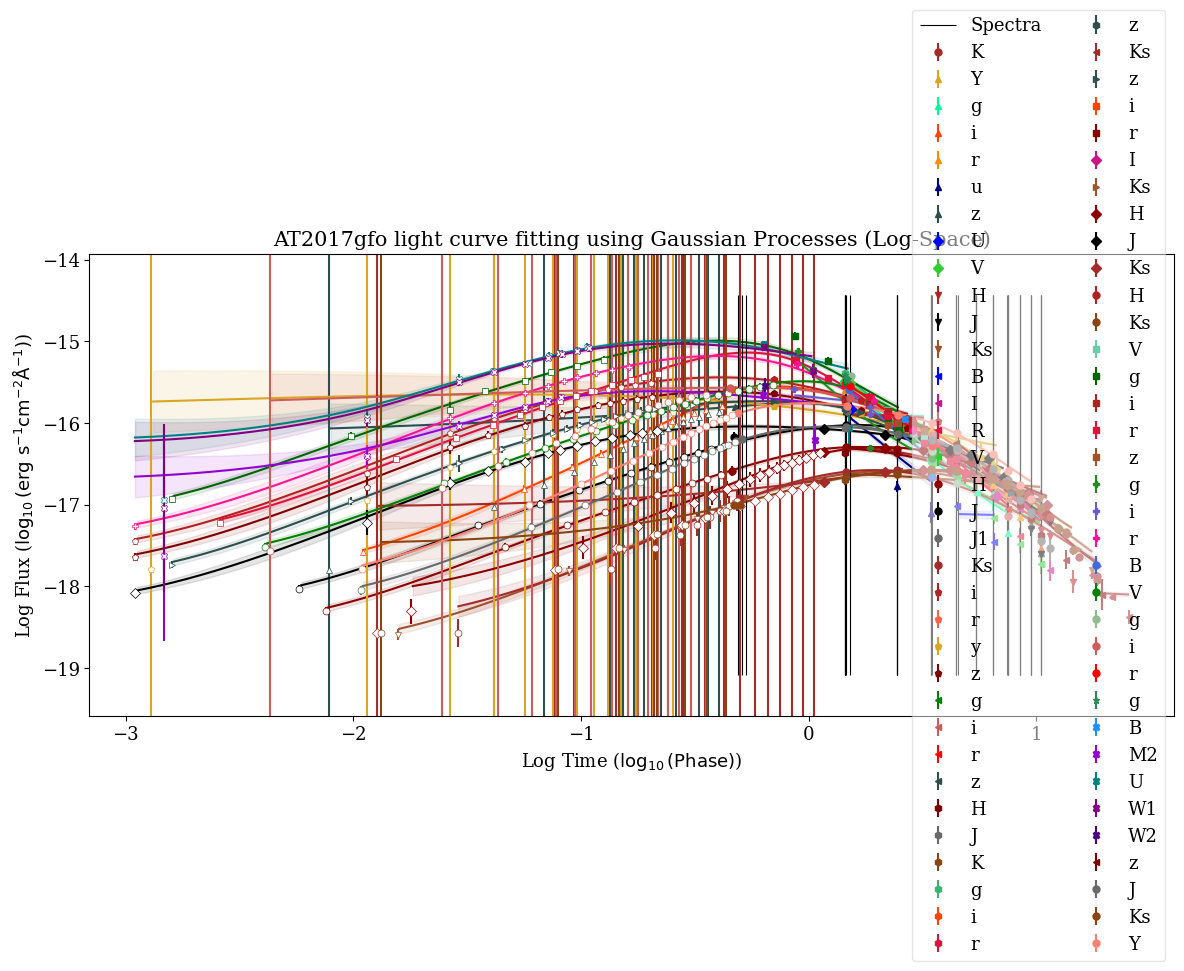

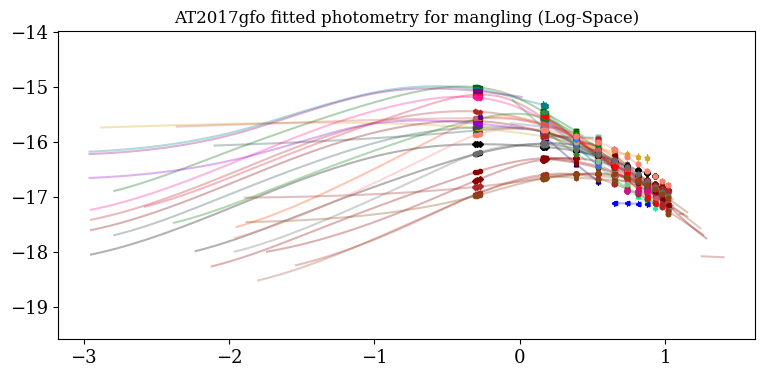

In [16]:
cvs_file=SN.mangling_GPfile()
SN.save_plot_GPfit()
SN.save_plot_GPfit_spec()
#print_separate(SN)

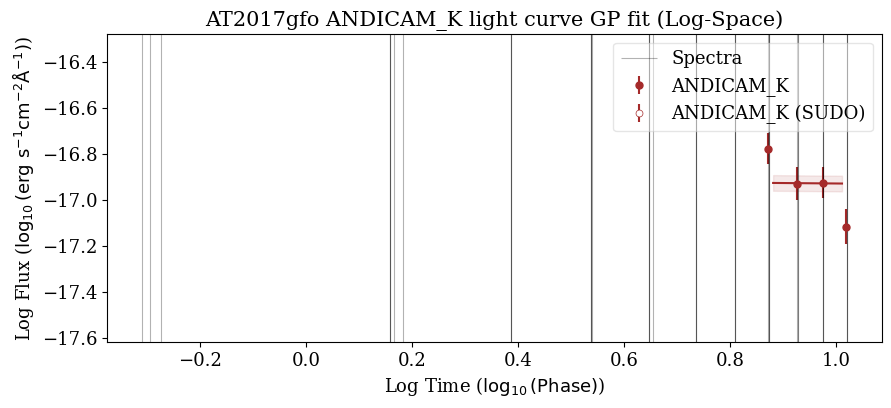

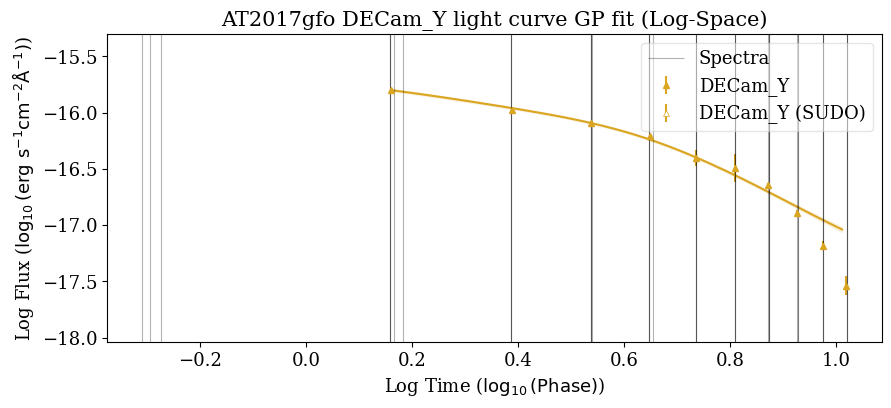

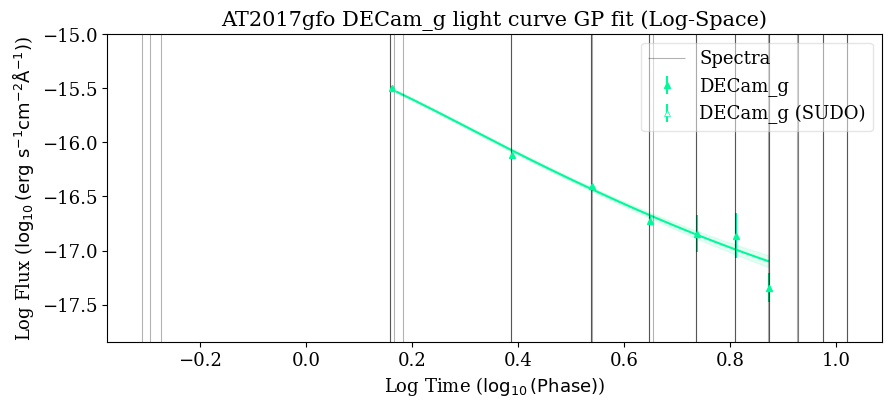

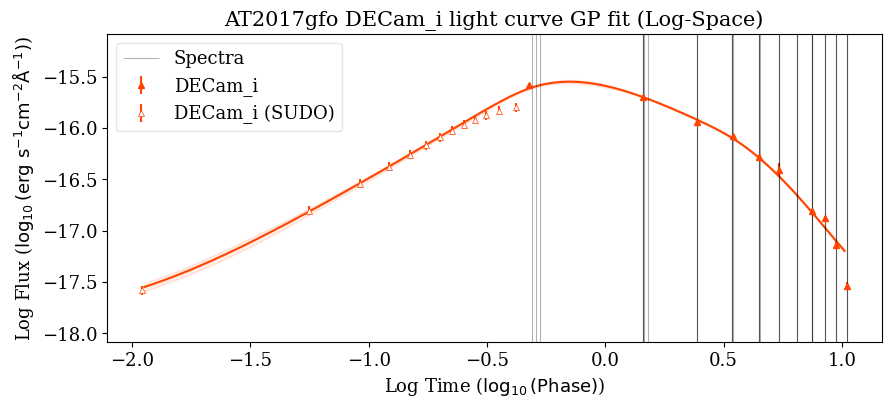

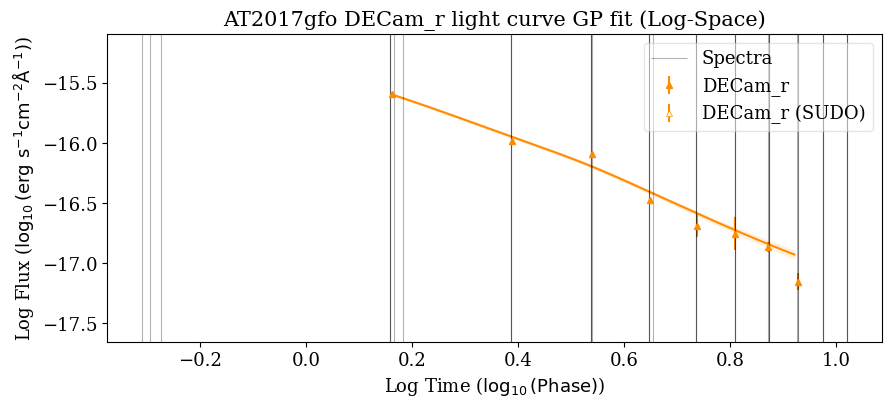

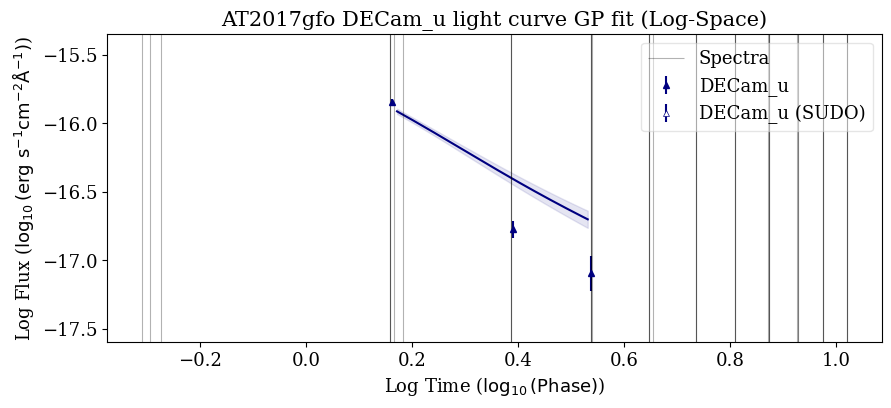

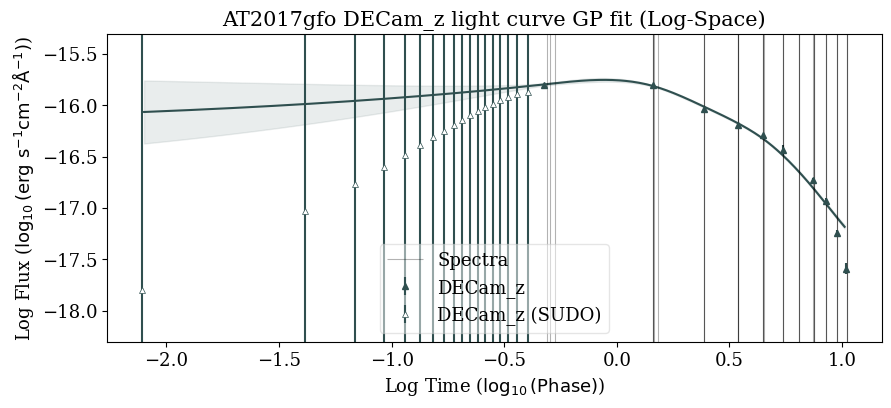

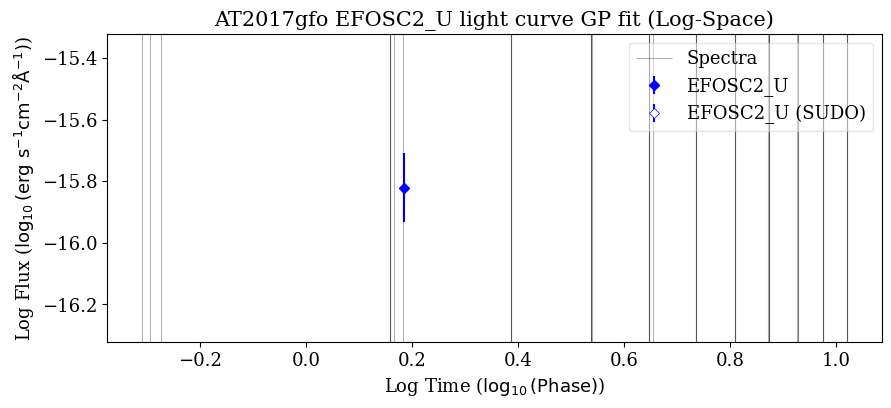

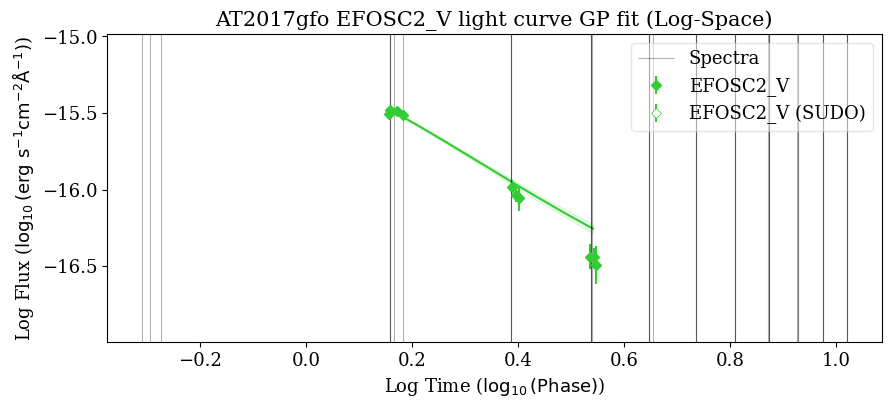

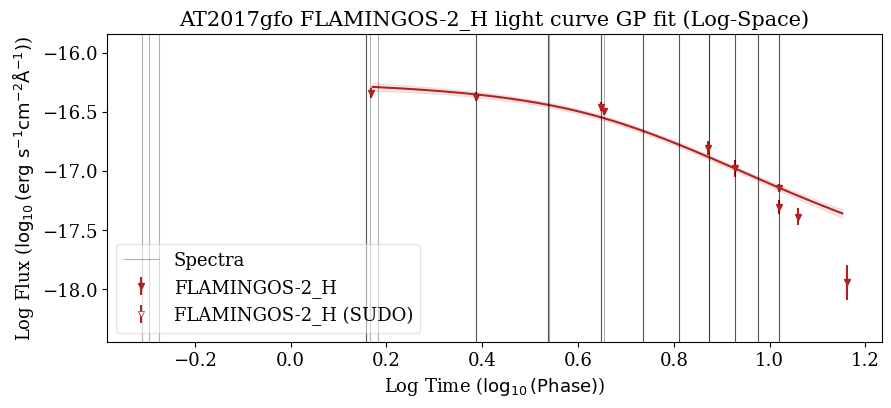

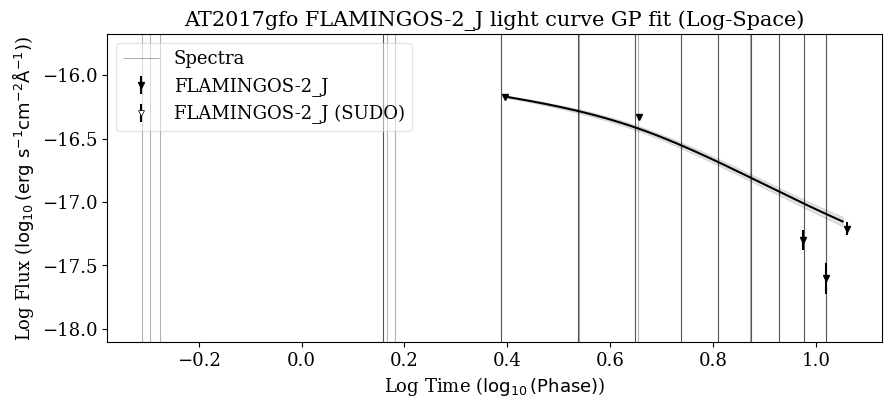

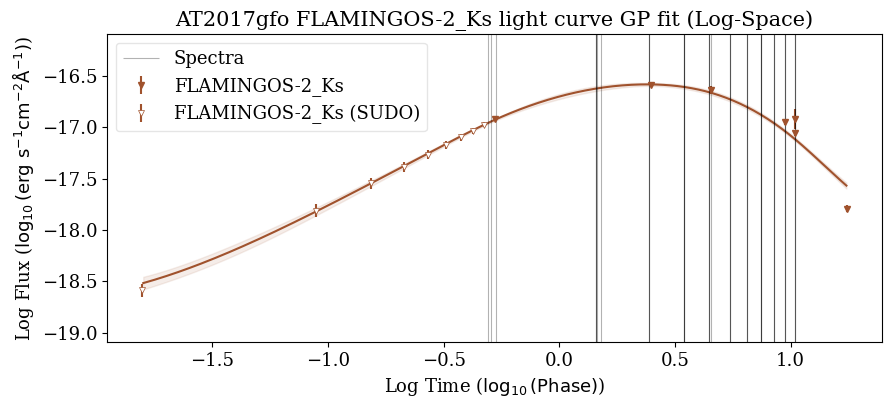

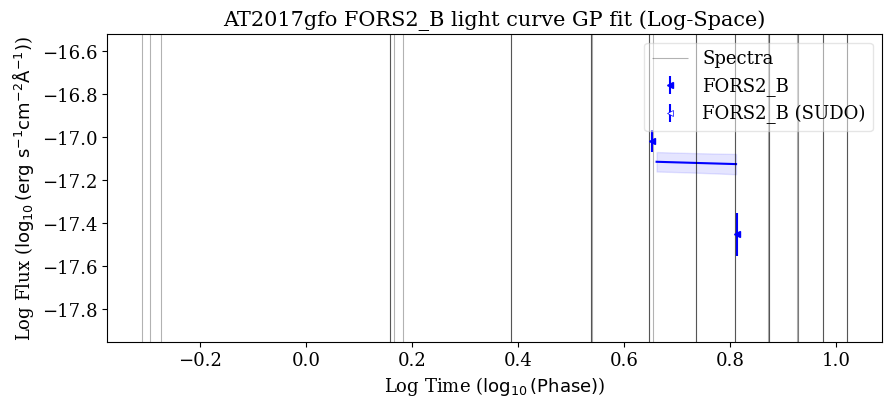

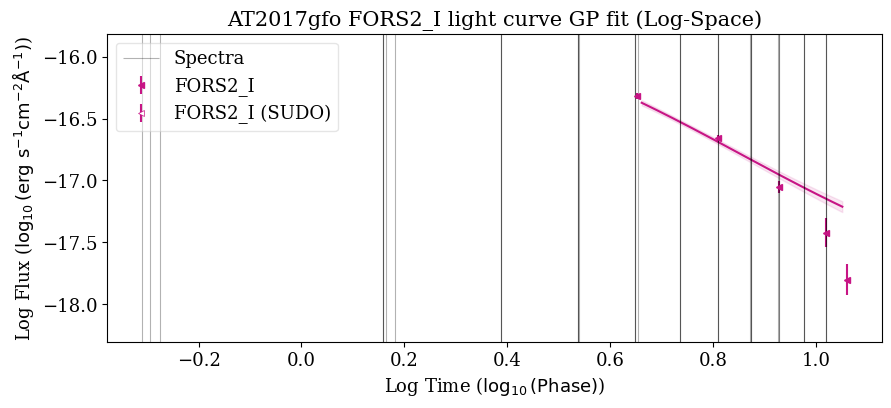

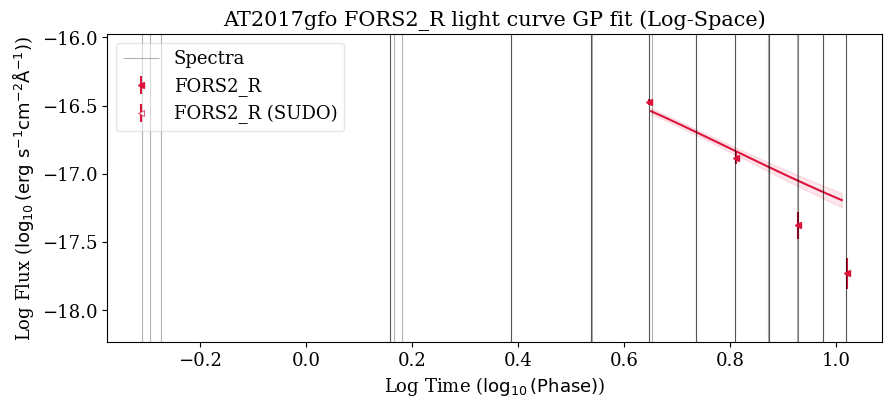

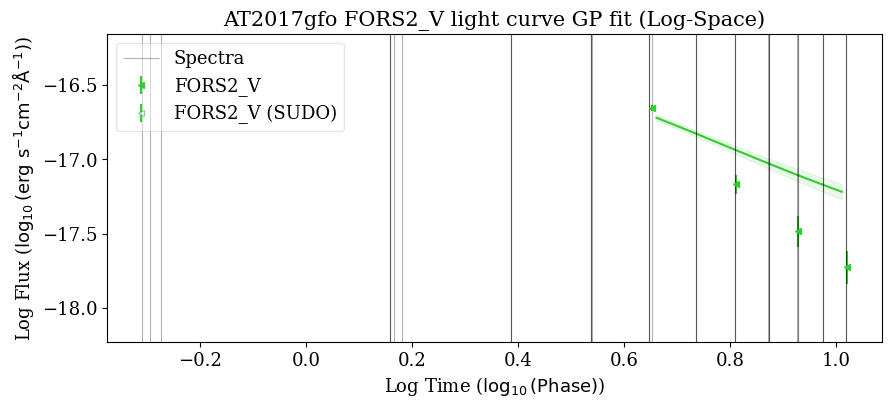

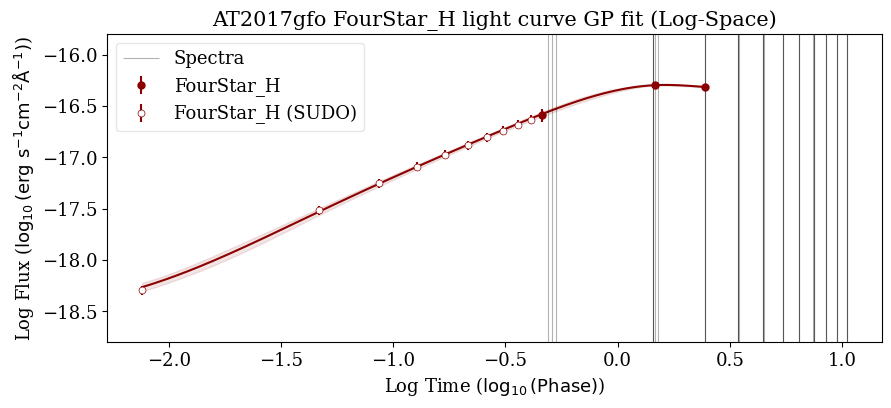

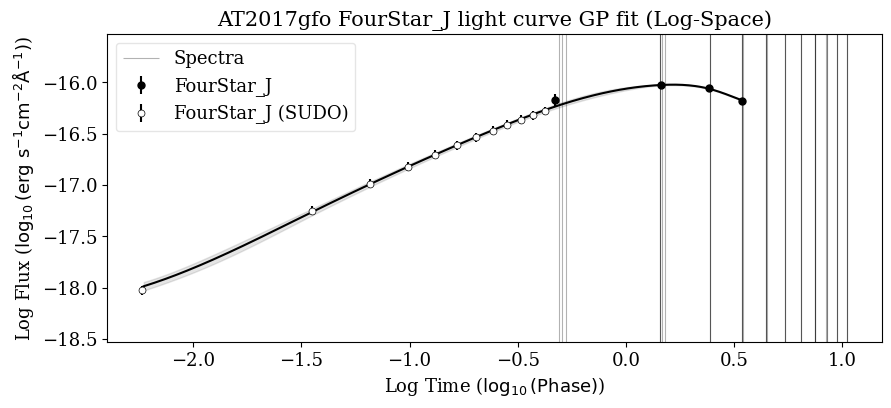

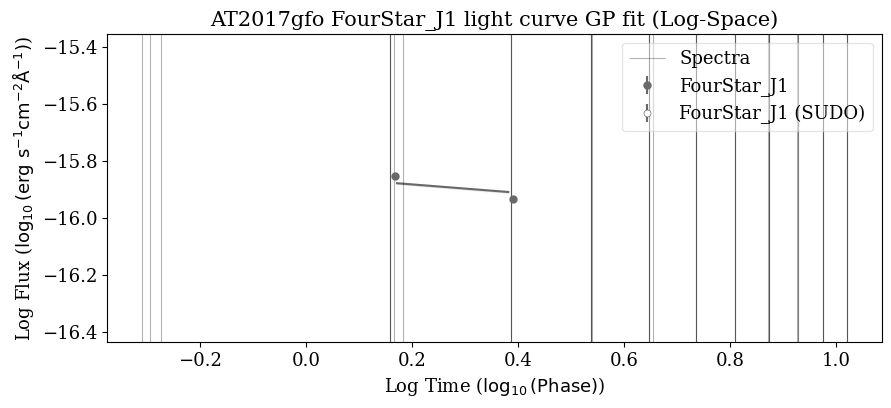

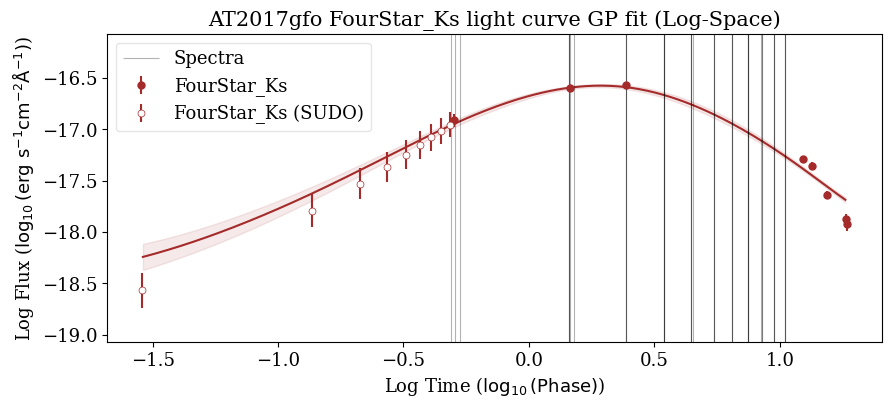

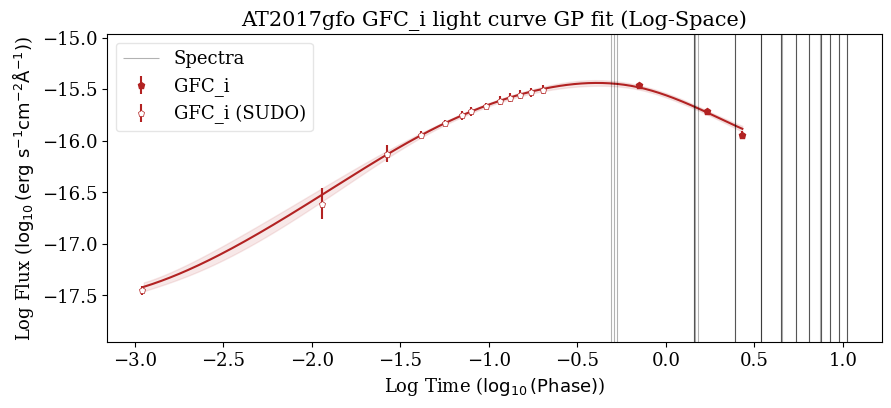

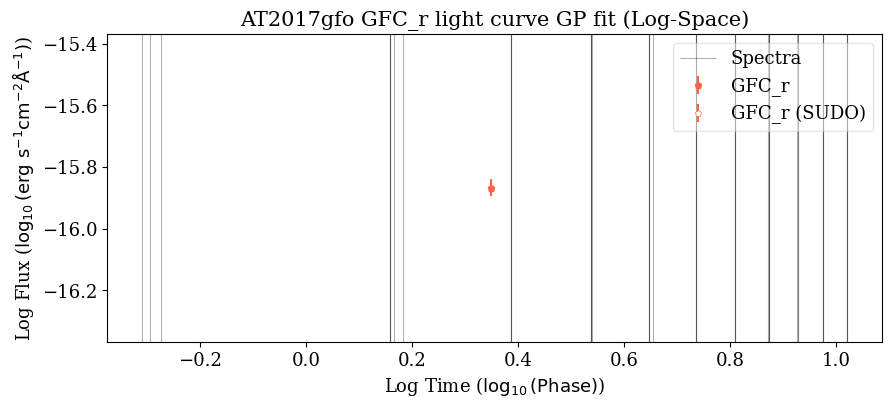

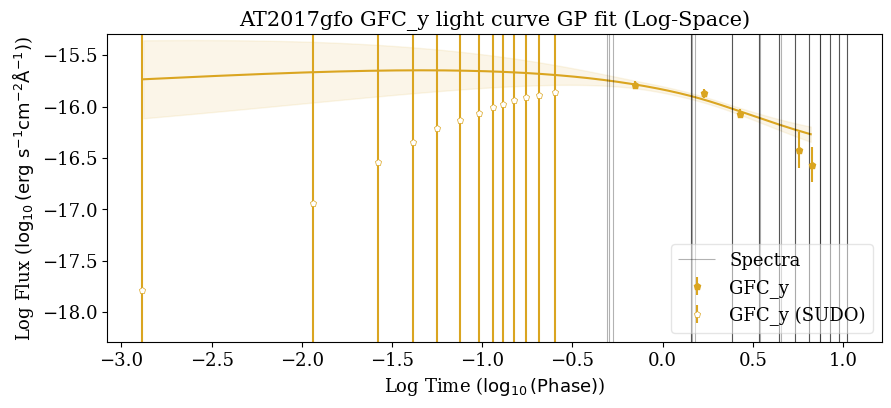

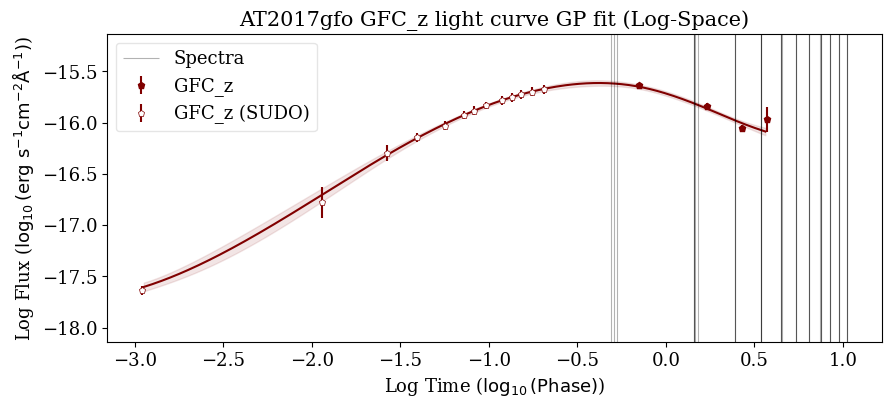

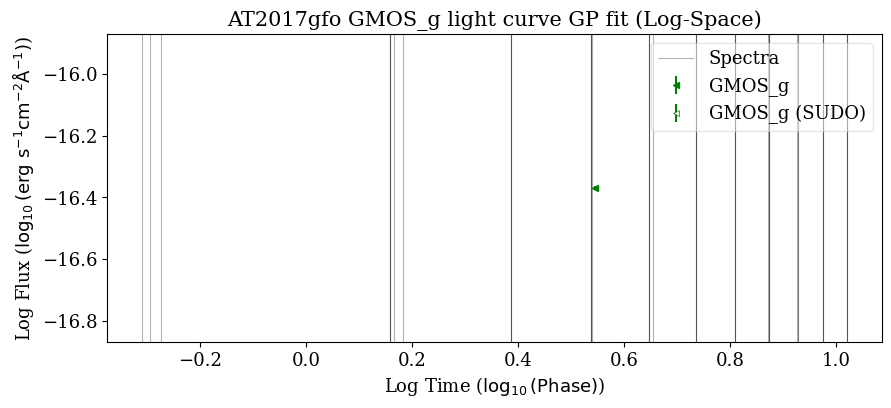

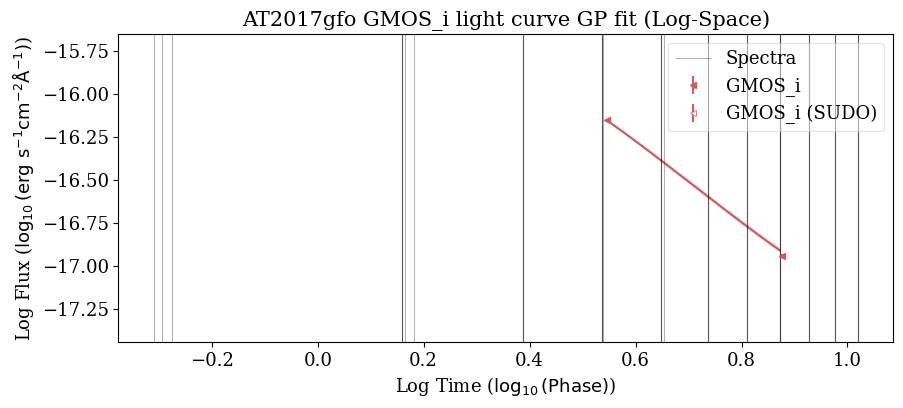

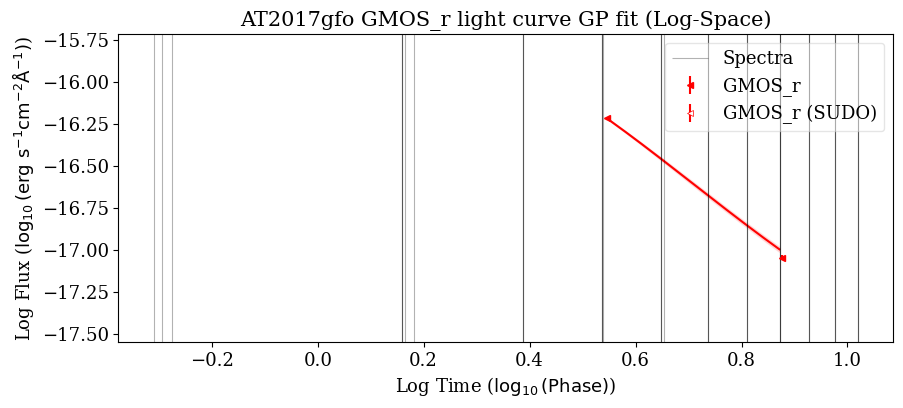

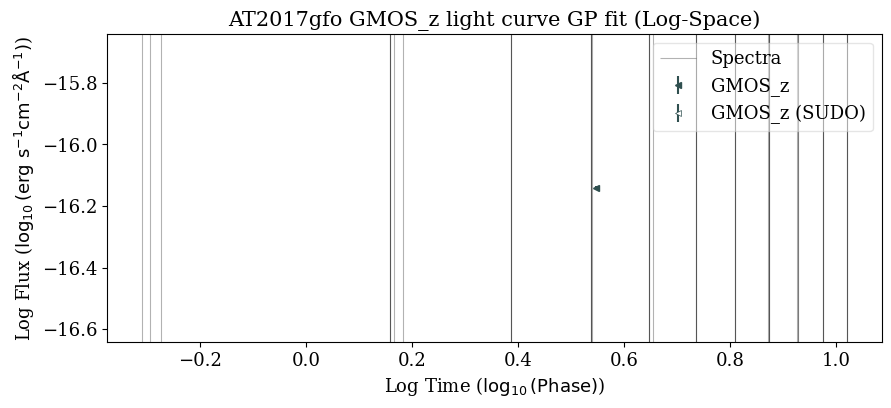

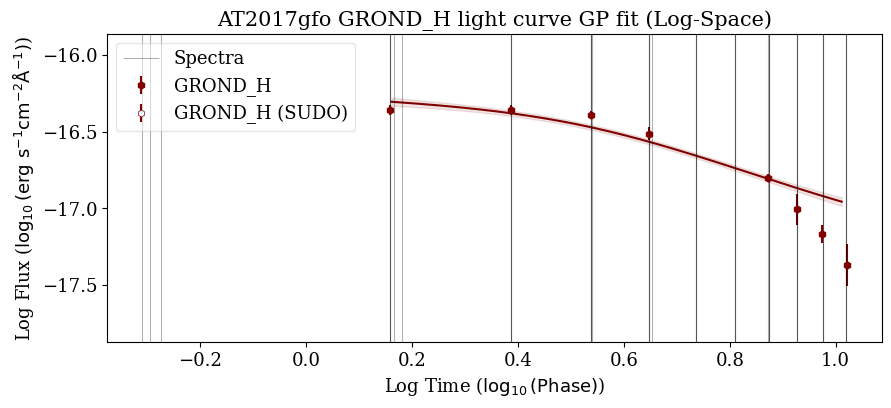

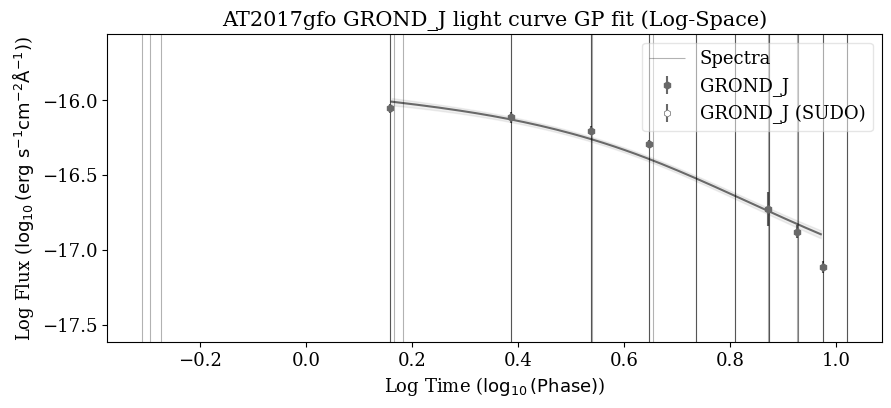

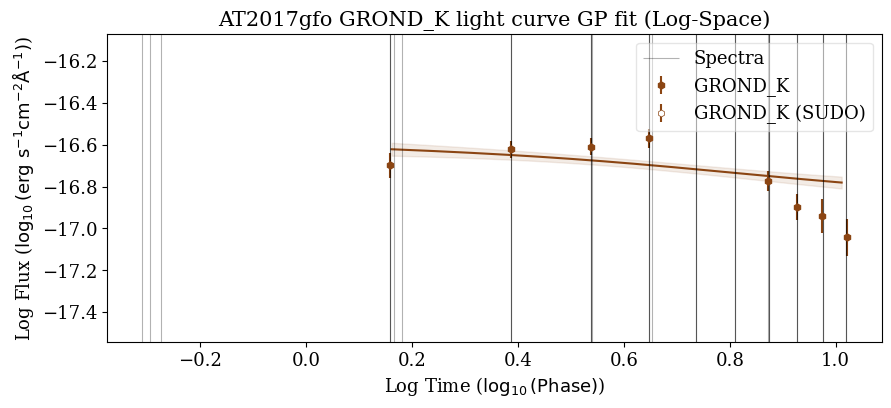

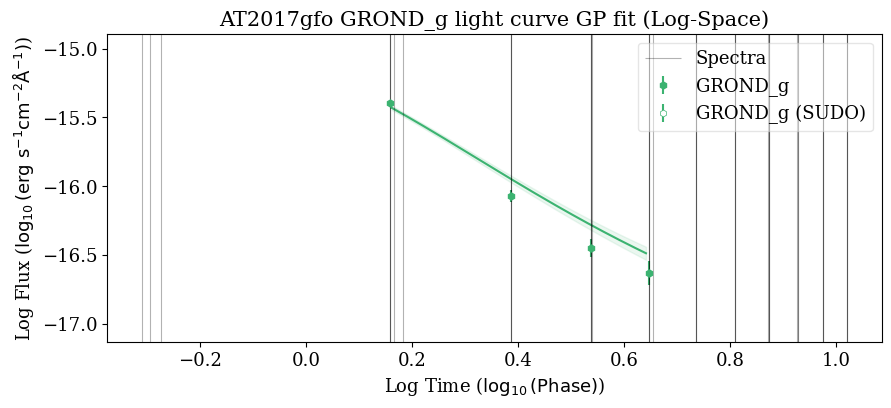

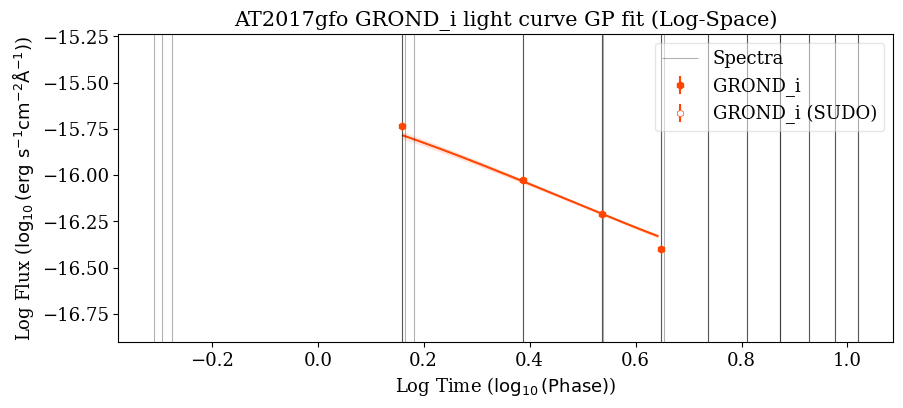

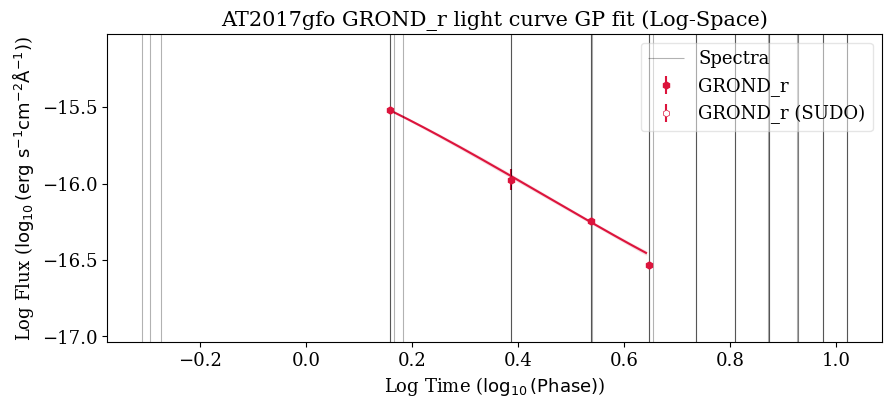

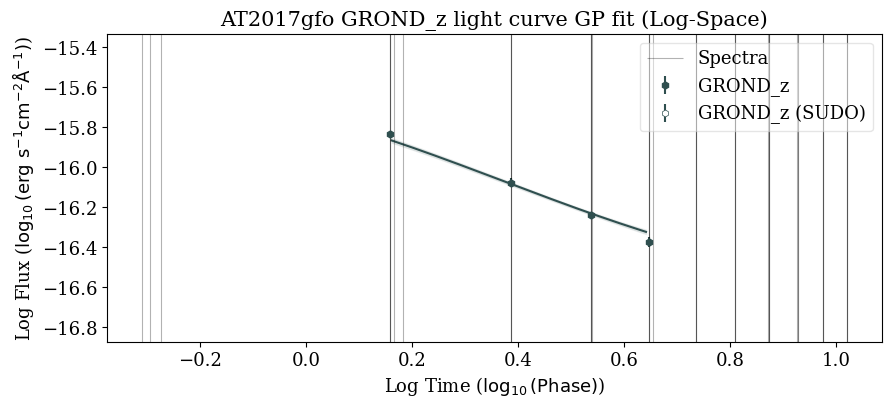

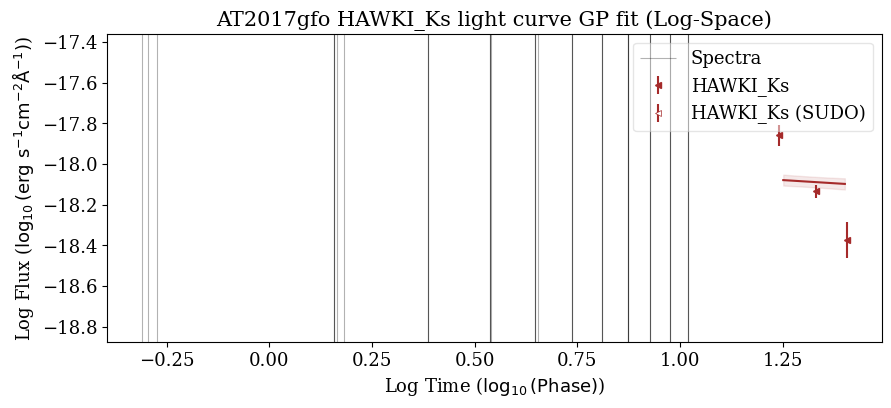

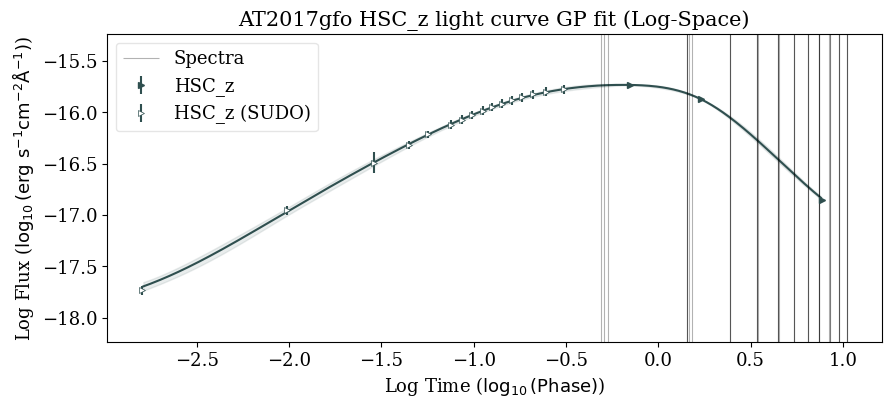

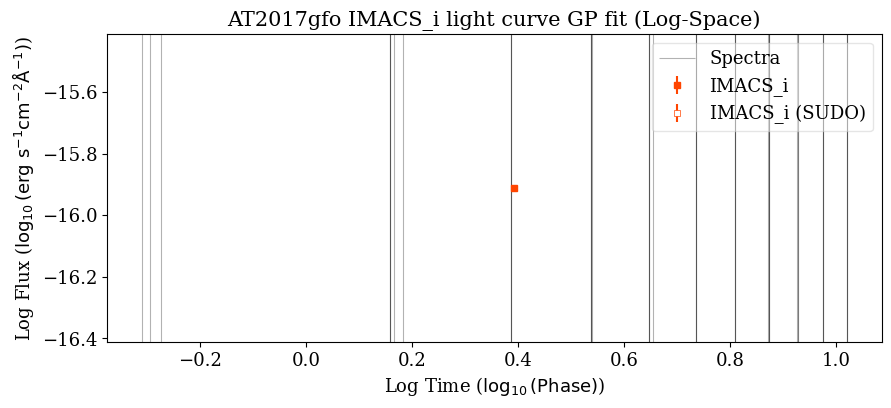

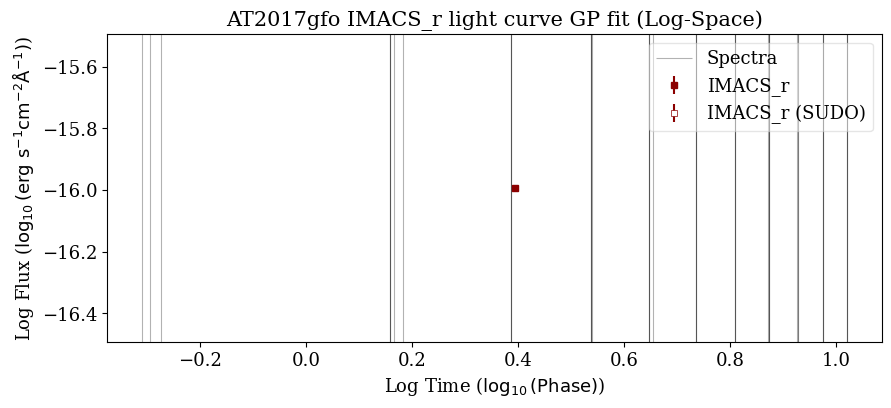

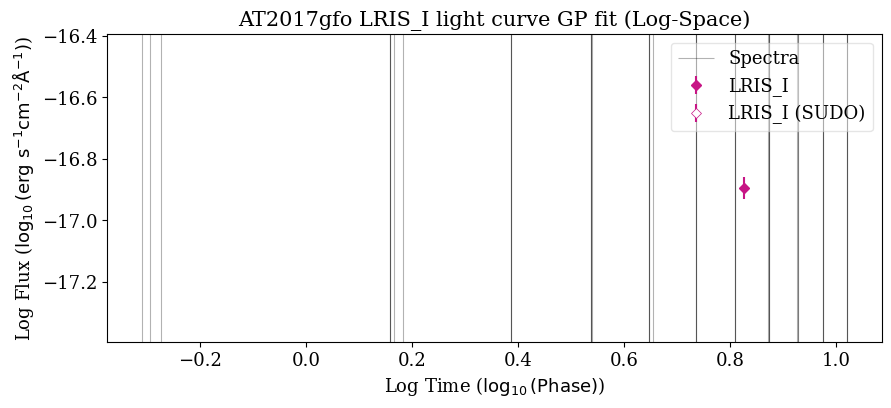

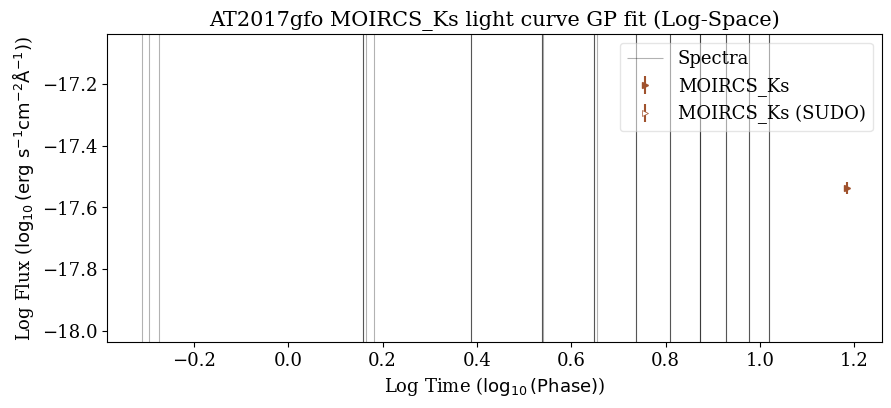

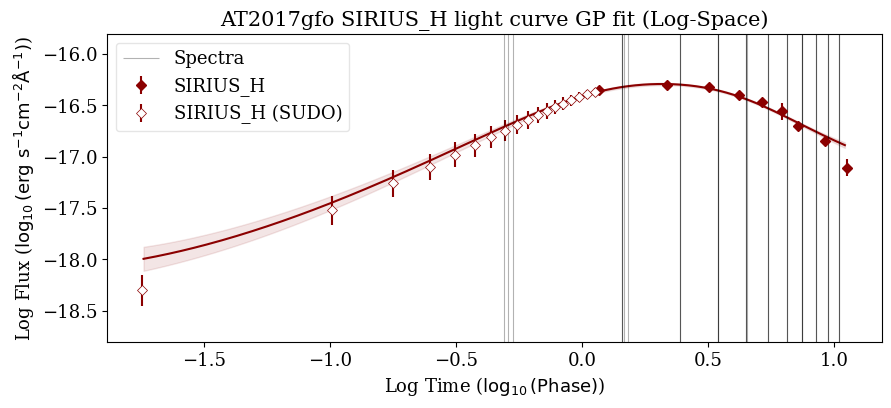

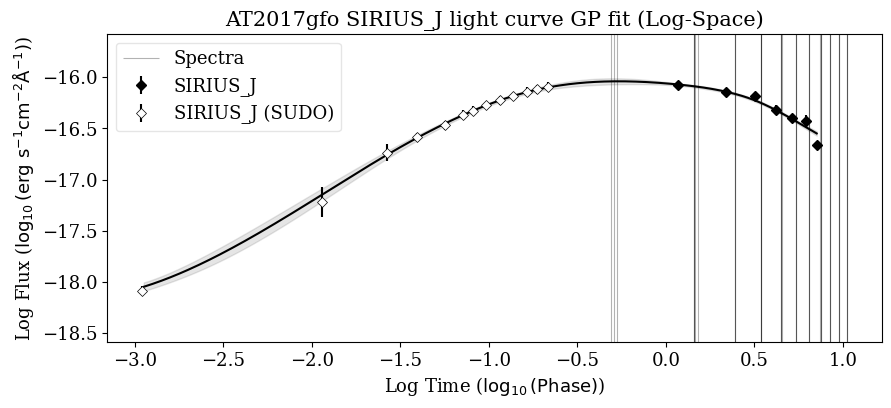

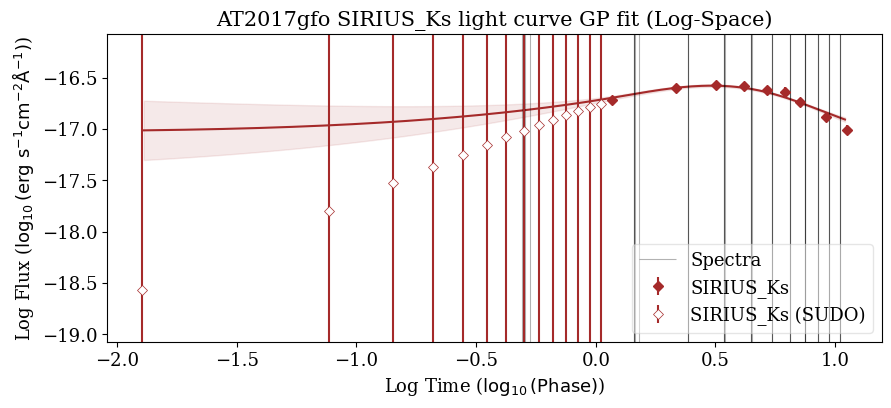

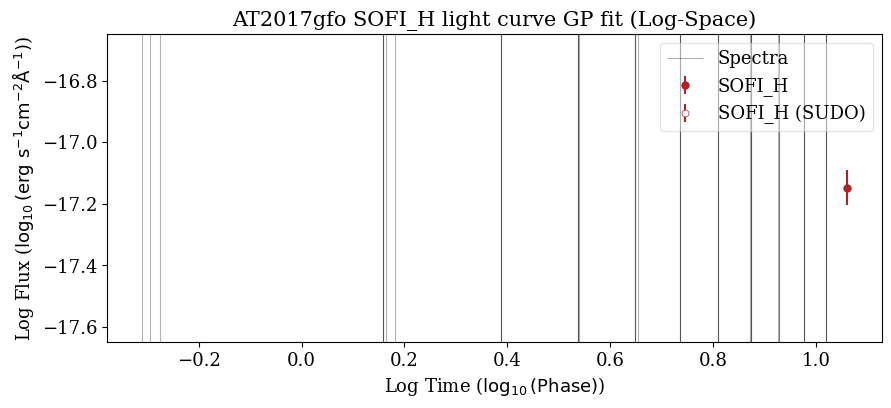

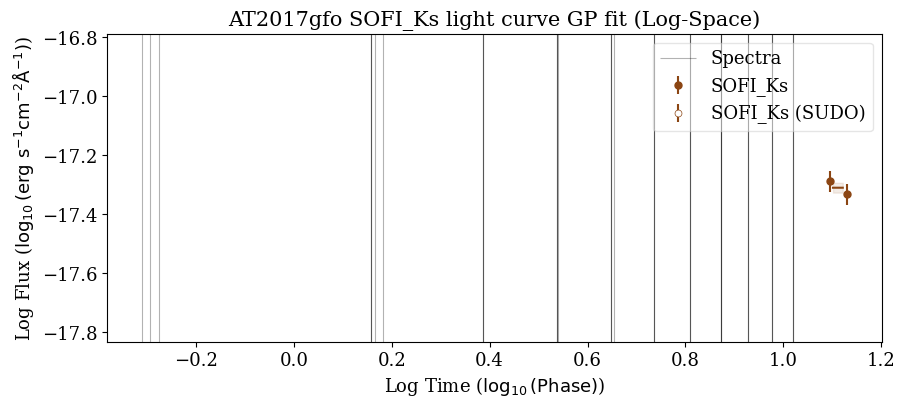

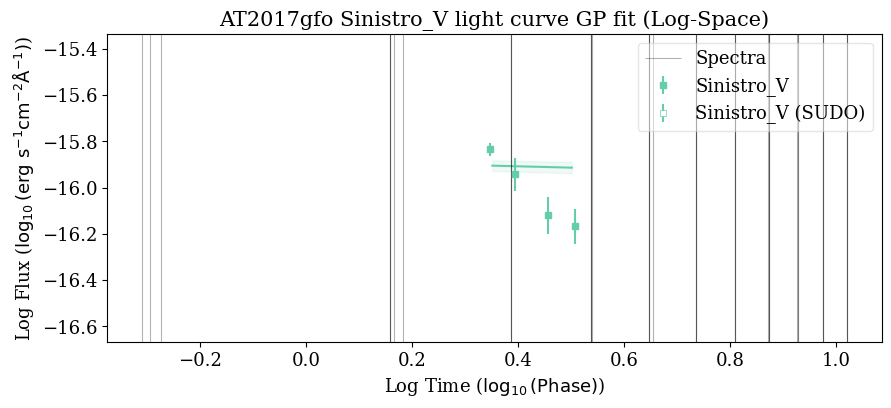

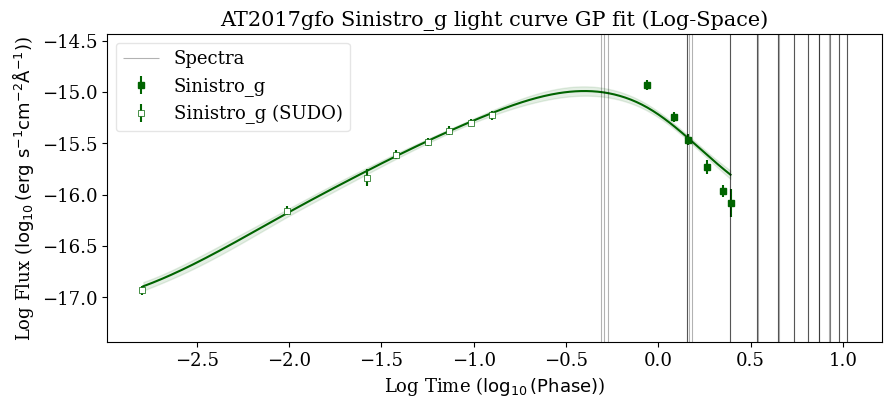

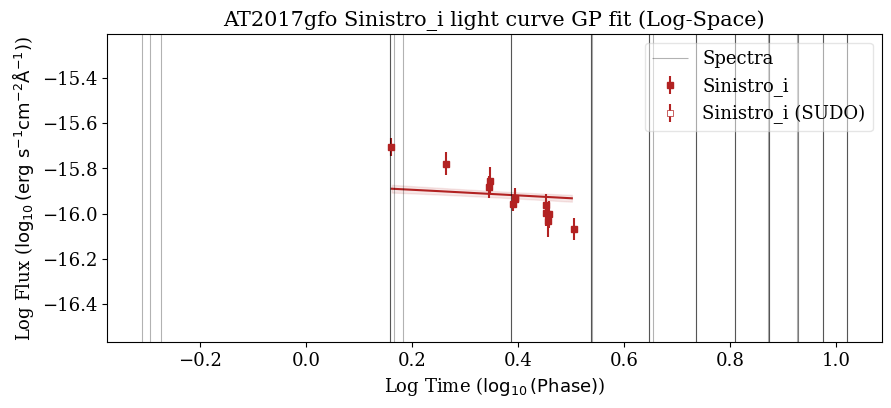

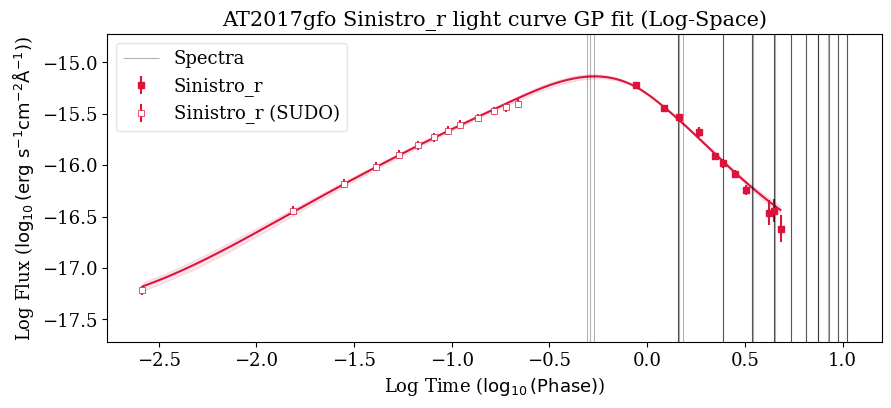

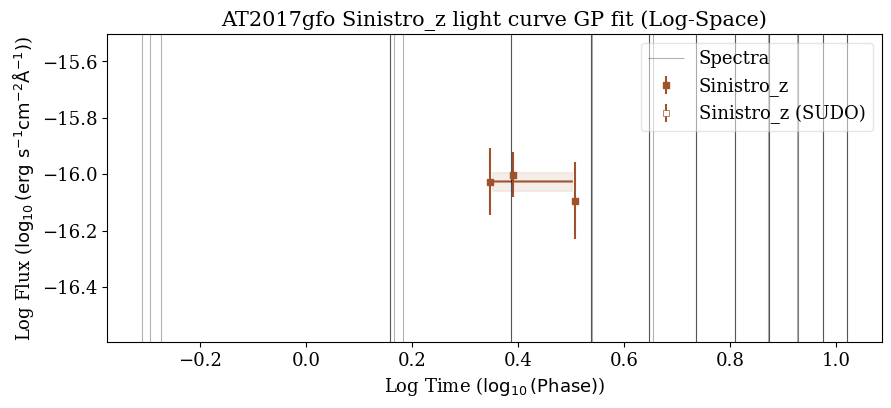

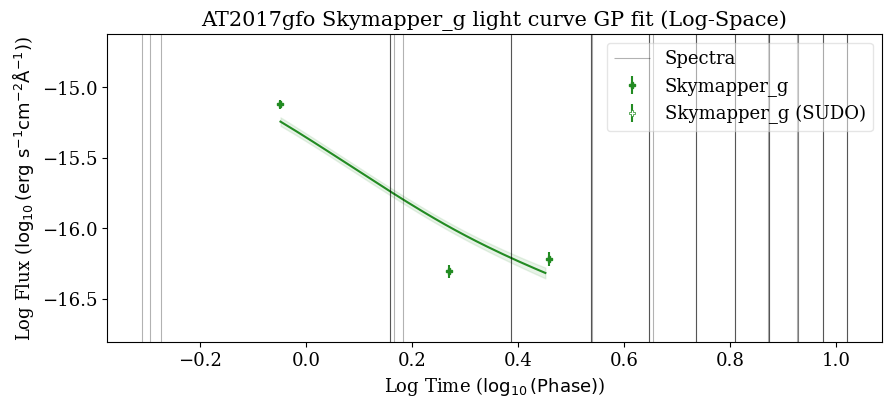

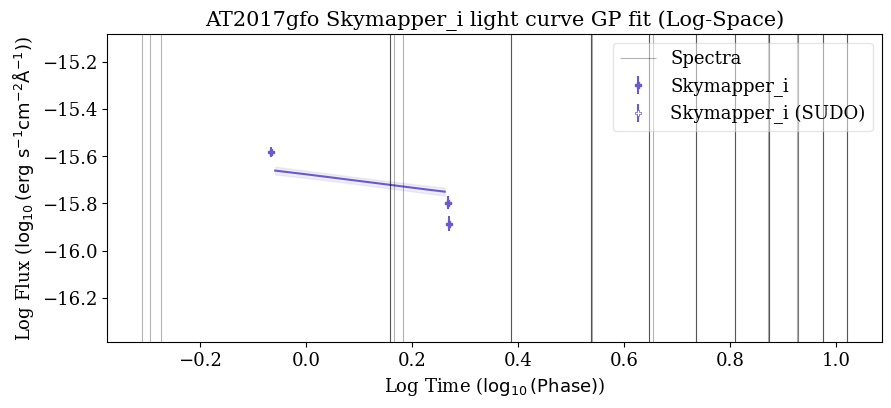

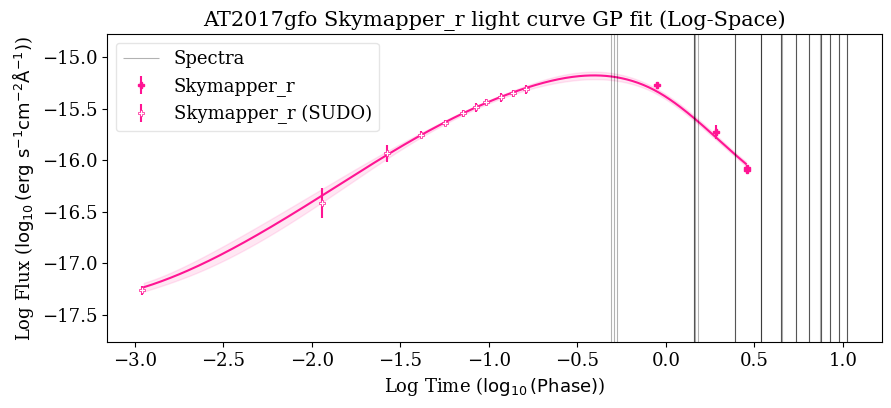

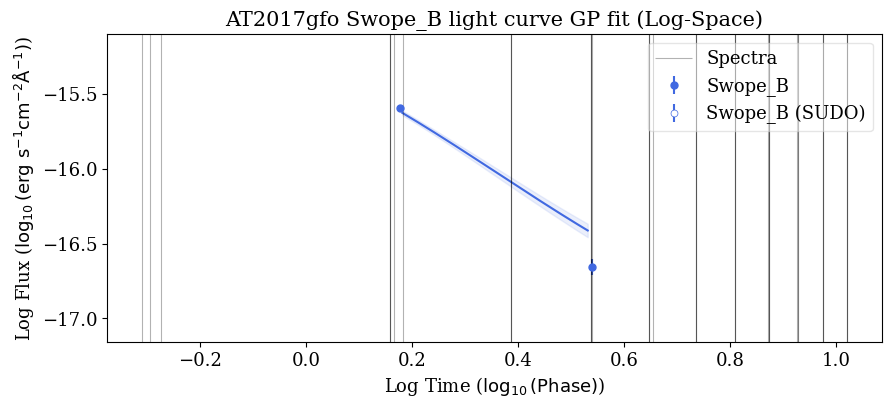

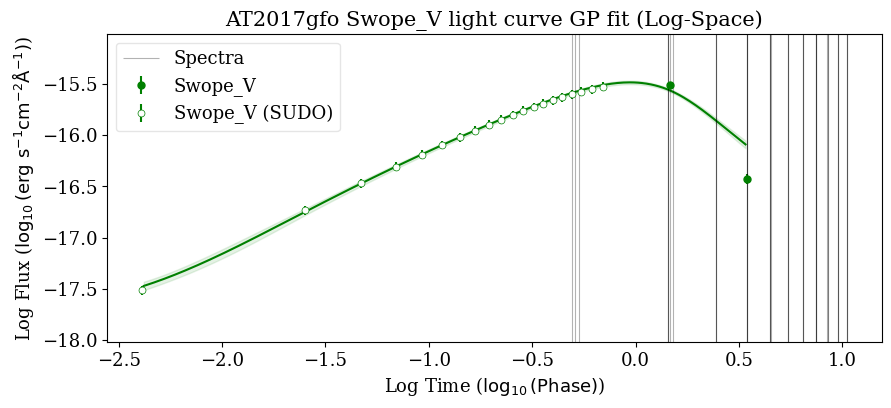

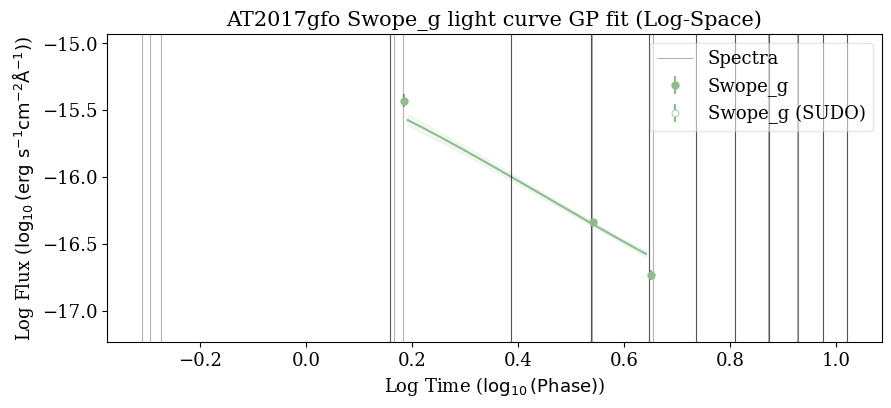

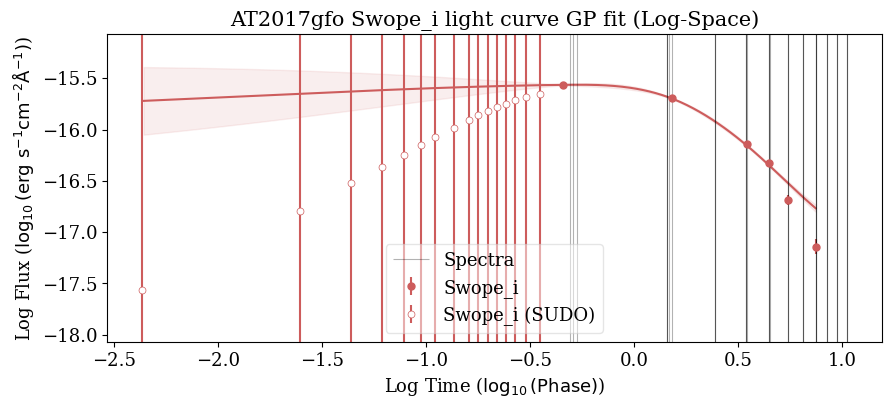

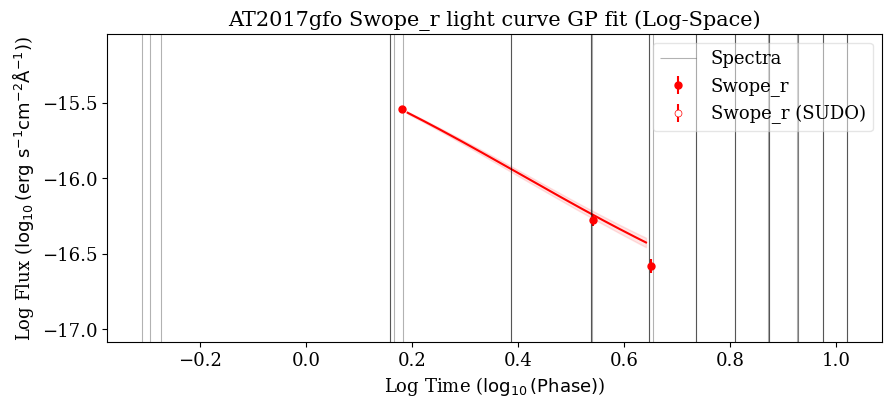

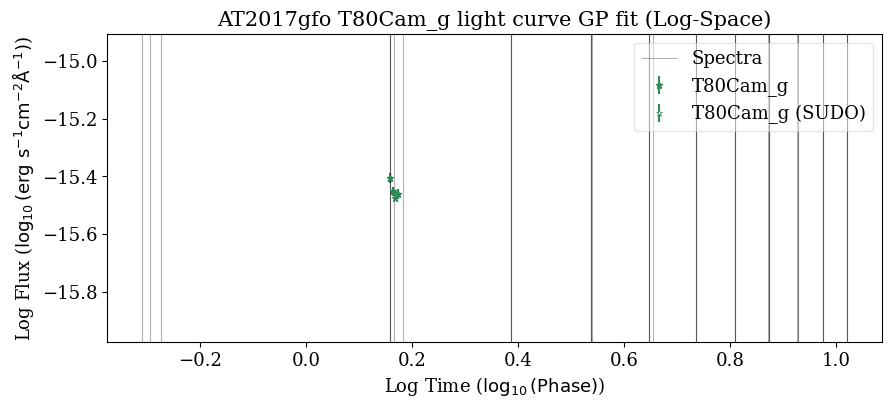

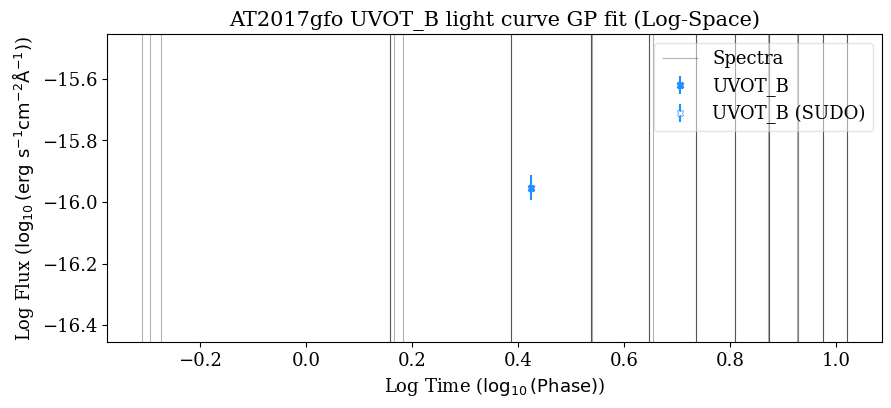

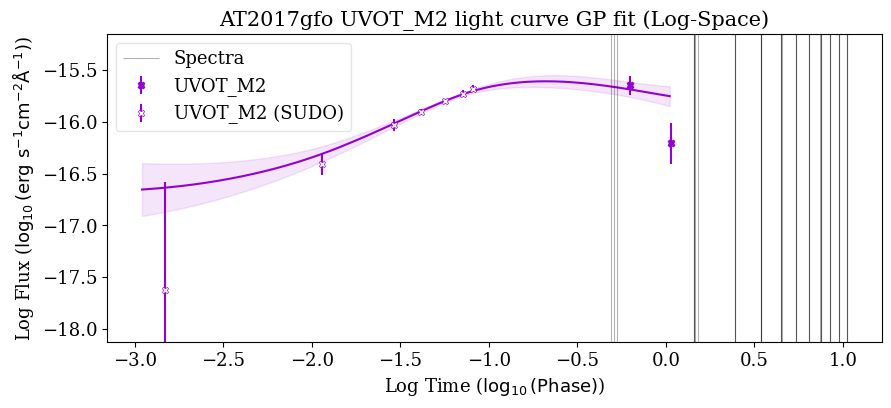

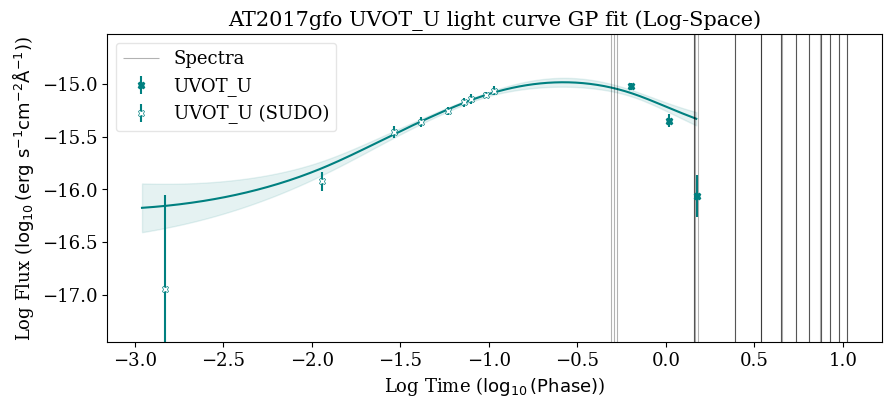

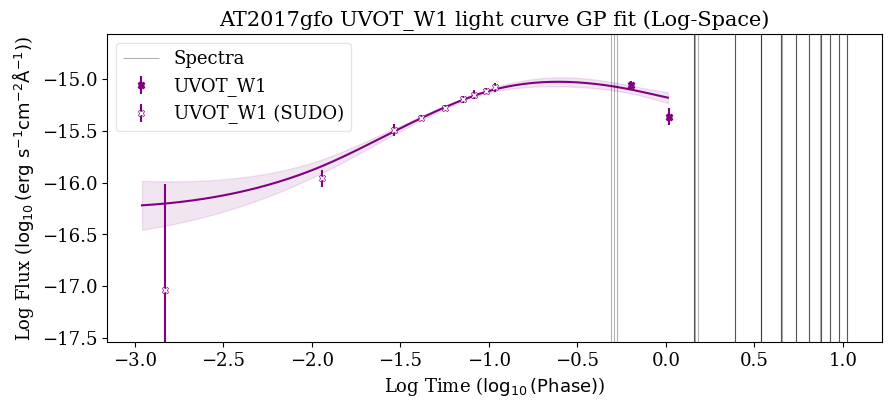

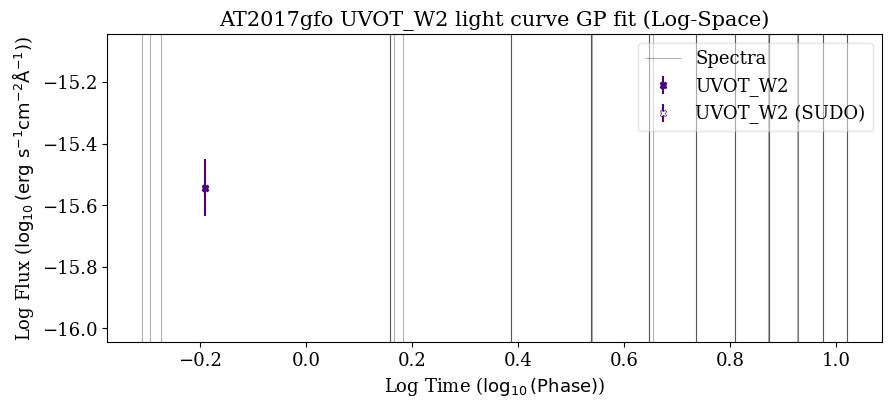

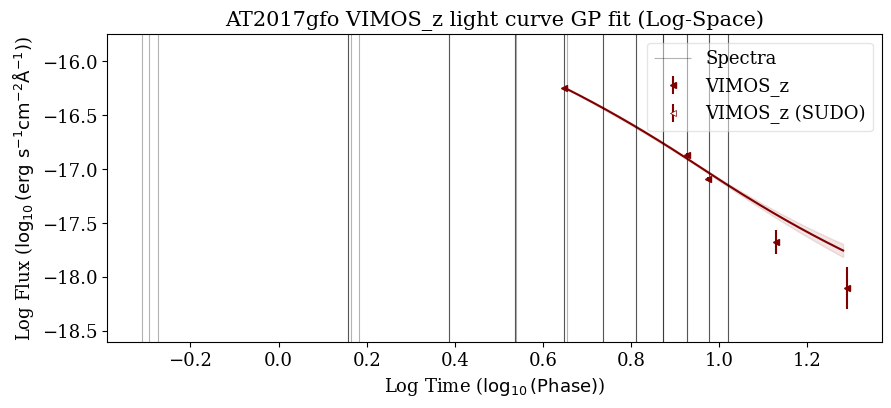

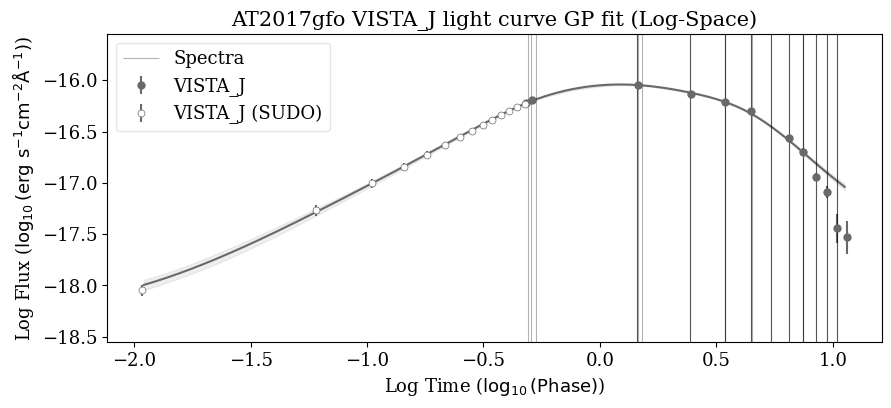

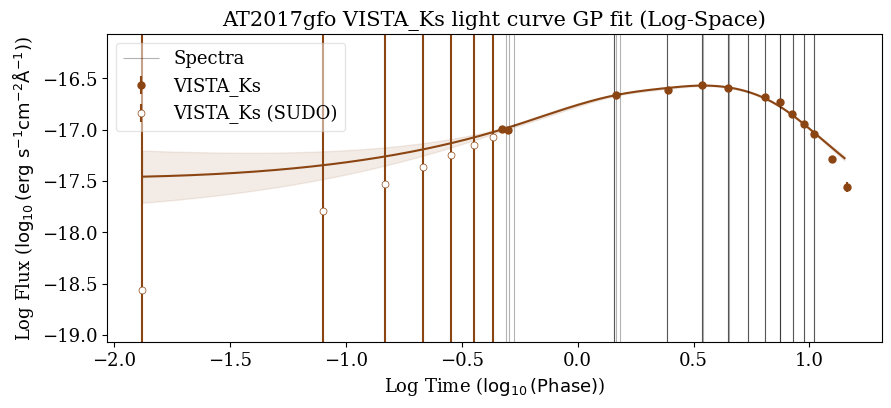

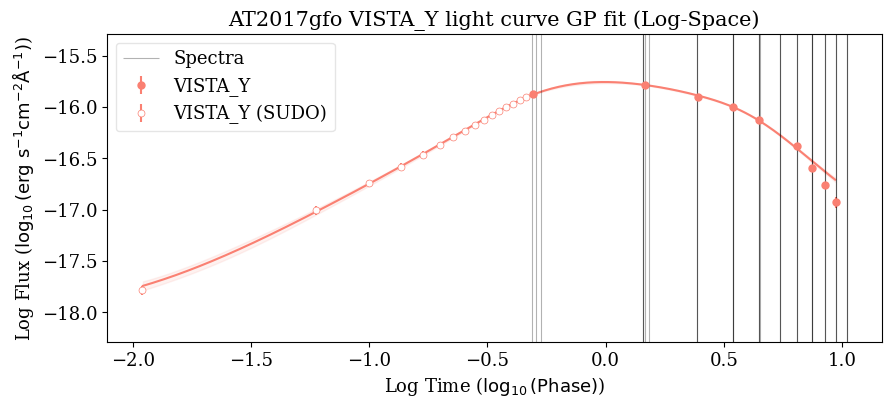

In [17]:
# Plot each filter in its own figure, but with consistent formatting
for f in SN.avail_filters:
    fig = plt.figure(figsize=(10, 4))
    plt.rc('font', family='serif')
    plt.rc('xtick', labelsize=13)
    plt.rc('ytick', labelsize=13)
    c = color_dict[f]
    
    # 1. Update variables to receive the log-space arrays
    log_phase, log_flux, err_log_flux, sudo = SN.fitted_phot[f]['clipped_extended_data']
    new_log_phase, mu, std = SN.fitted_phot[f]['fit_highcadence']
    
    if 'swift' in f:
        flabel = f.split('_')[1] + '(Swift)'
    else:
        #flabel = f.split('_')[1]
        flabel = f
        
    # Real points
    a = plt.errorbar(log_phase[~sudo], log_flux[~sudo], yerr=err_log_flux[~sudo],
                     fmt=mark_dict[f], mfc=c, ms=5, color=c,
                     linestyle='None', label=flabel)
    # SUDO points
    plt.errorbar(log_phase[sudo], log_flux[sudo], yerr=err_log_flux[sudo],
                 fmt=mark_dict[f], mfc='white', mec=c, ms=5, mew=0.5, color=c,
                 linestyle='None', label=flabel + ' (SUDO)')
                 
    # GP fit
    plt.plot(new_log_phase, mu, color=a[0].get_color())
    plt.fill_between(new_log_phase, mu+std, mu-std, color=a[0].get_color(), alpha=0.1)
    
    # Spectra lines
    if len(log_flux) > 0:
        # 2. Set safe plot boundaries for negative log fluxes
        ymin = min(log_flux) - 0.5
        ymax = max(log_flux) + 0.5
        
        # 3. Call the newly created log-phase spectra method
        spec_log_phases = SN.get_spec_log_phase()
        if len(spec_log_phases) > 0:
            plt.vlines(spec_log_phases, ymin, ymax, linestyle='-', alpha=0.3, lw=0.8, color='k', label='Spectra')
            
        plt.ylim(ymin, ymax)
        
    # 4. Update axis labels to accurately reflect log-space
    plt.xlabel(r'Log Time ($\log_{10}(\rm{Phase})$)', fontsize=13)
    plt.ylabel(r'Log Flux ($\log_{10}(\rm{erg \ s^{-1} cm^{-2} \AA^{-1}})$)', fontsize=13)
    
    plt.legend(fontsize=13, loc='best', fancybox=True, framealpha=0.5)
    plt.title(f"{SN.snname} {flabel} light curve GP fit (Log-Space)", fontsize=15)
    plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_55229/685877671.py:36: SyntaxWarning: invalid escape sequence '\s'
  plt.fill_between(hc_log_phase, hc_mu - hc_std, hc_mu + hc_std, color=a[0].get_color(), alpha=0.2, label='GP 1$\sigma$')


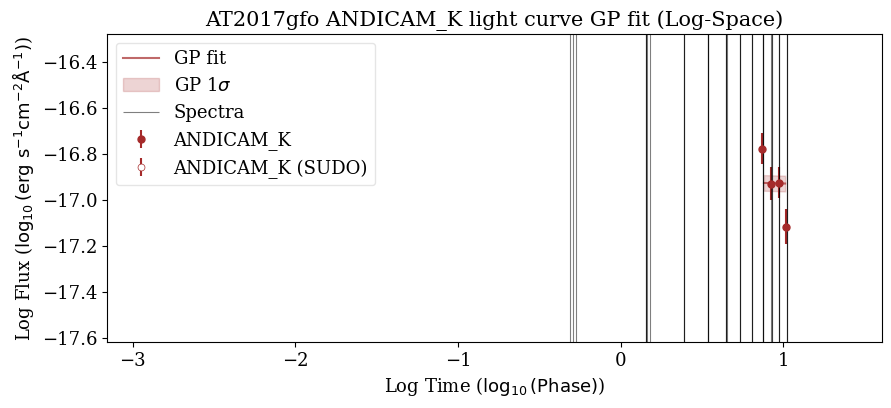

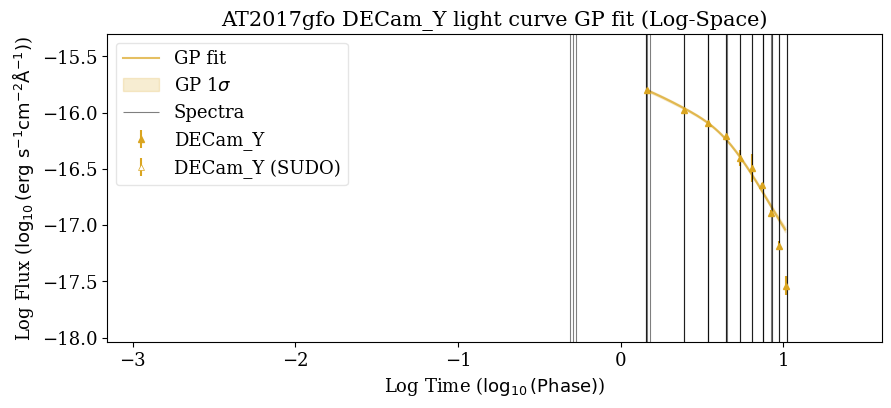

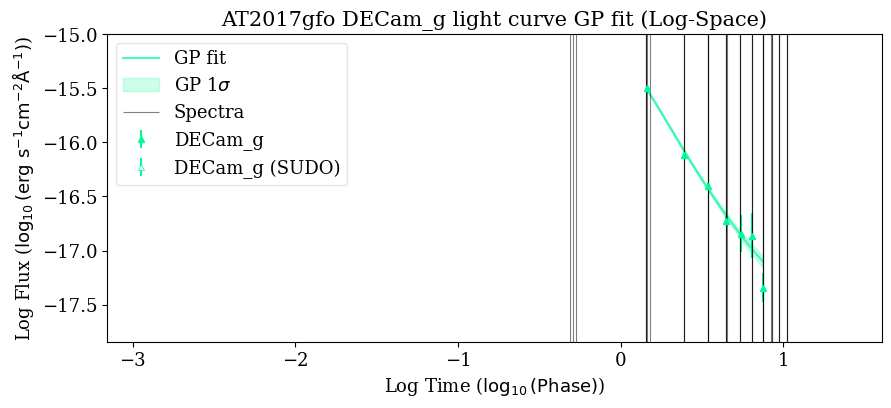

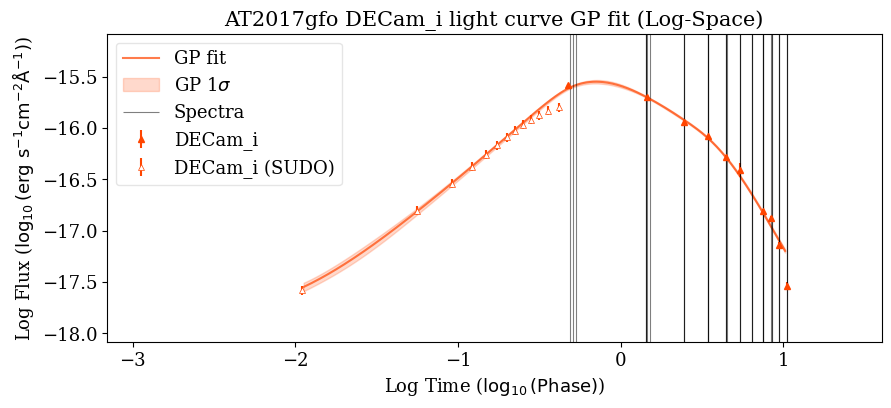

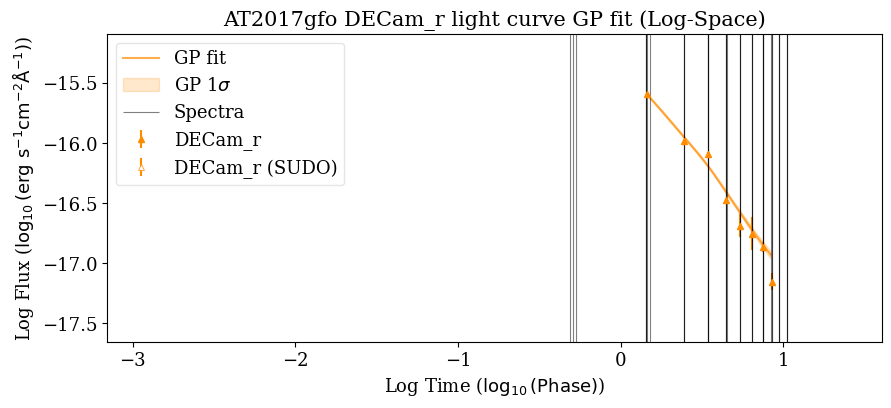

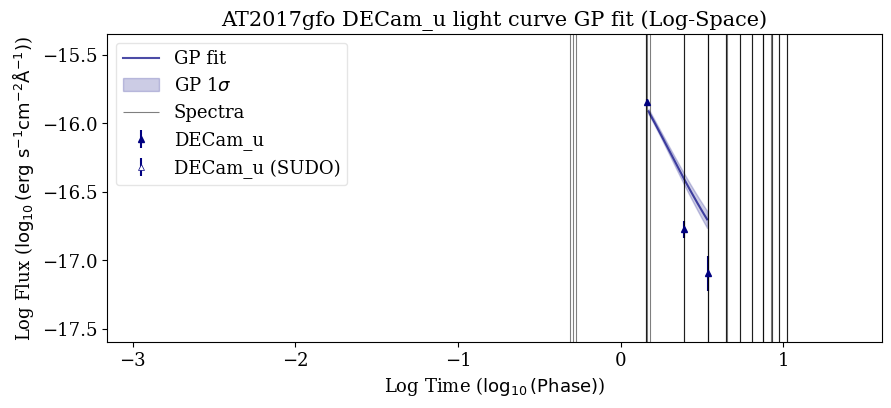

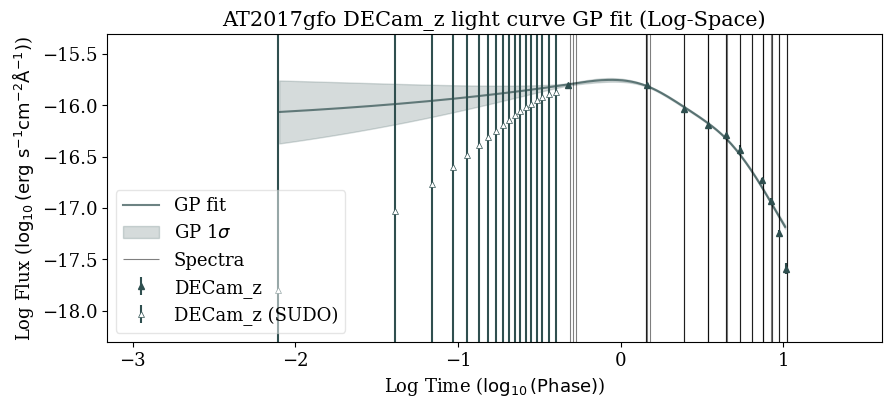

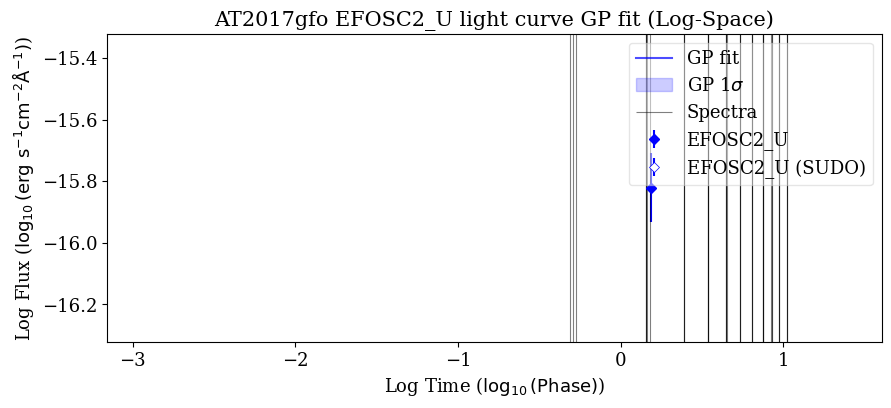

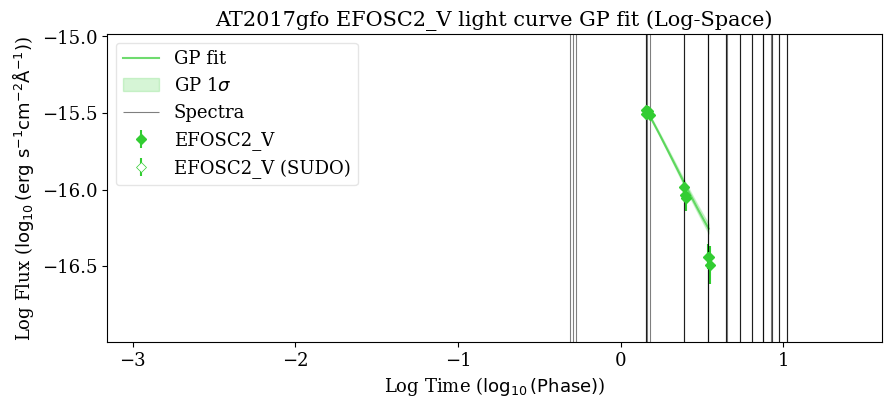

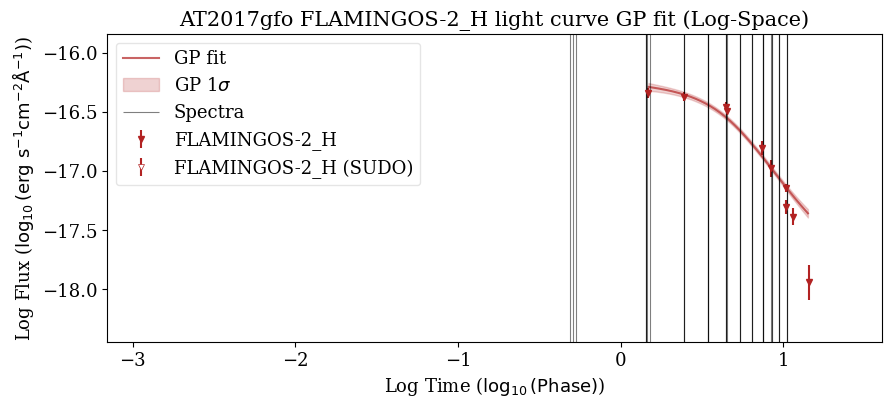

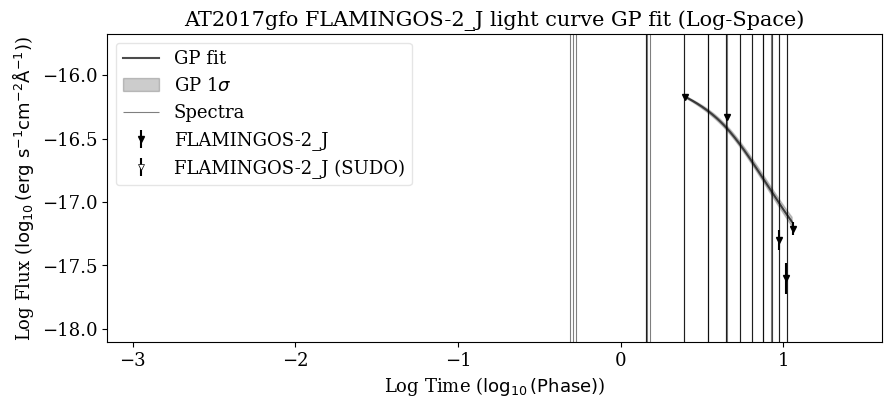

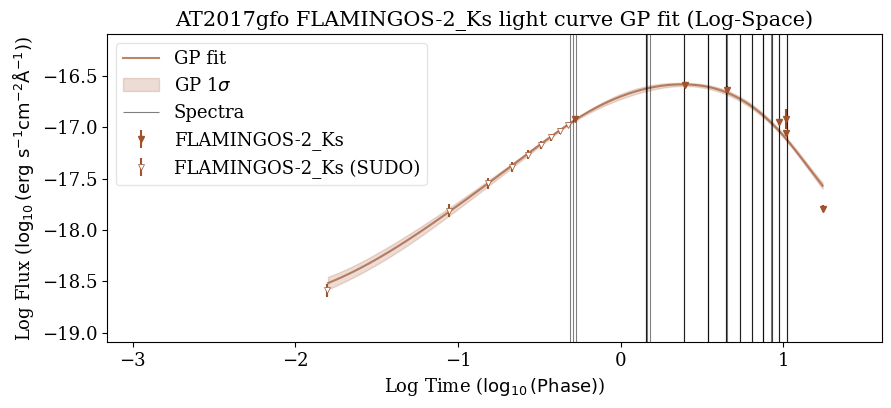

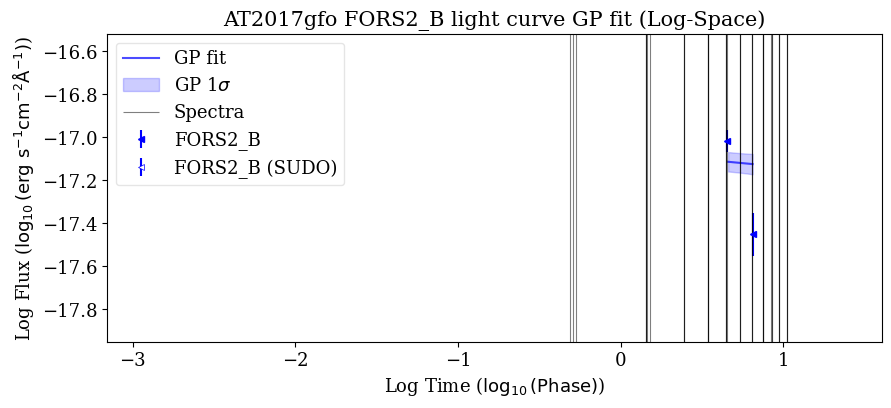

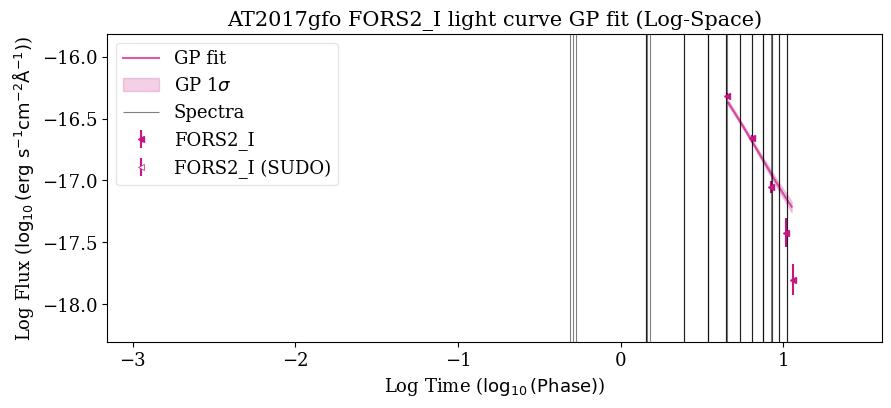

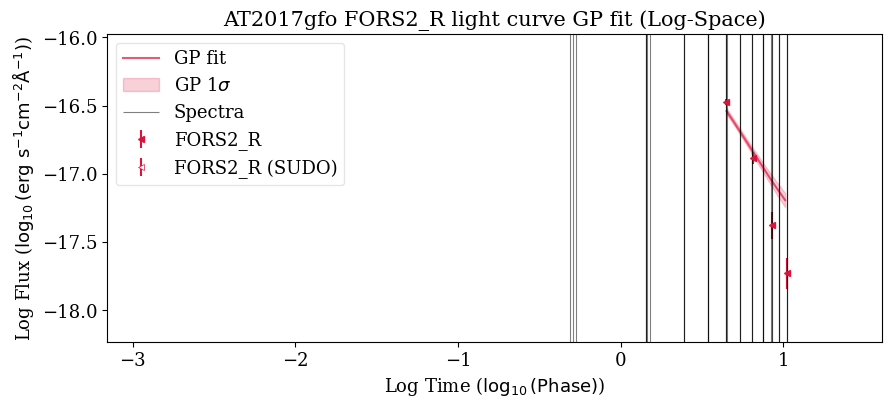

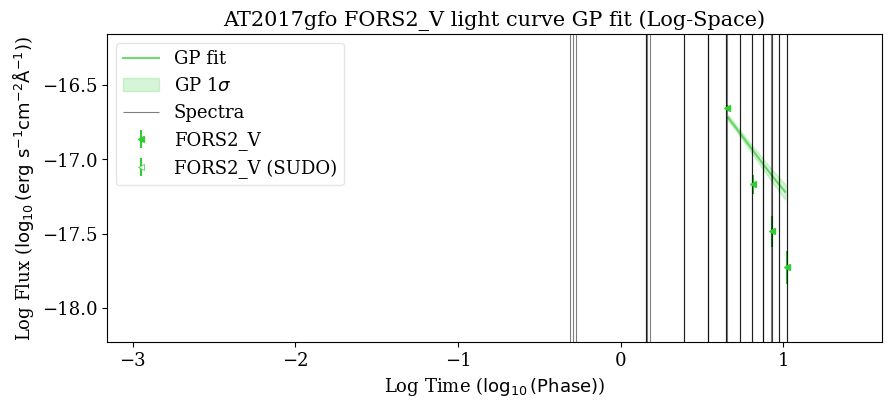

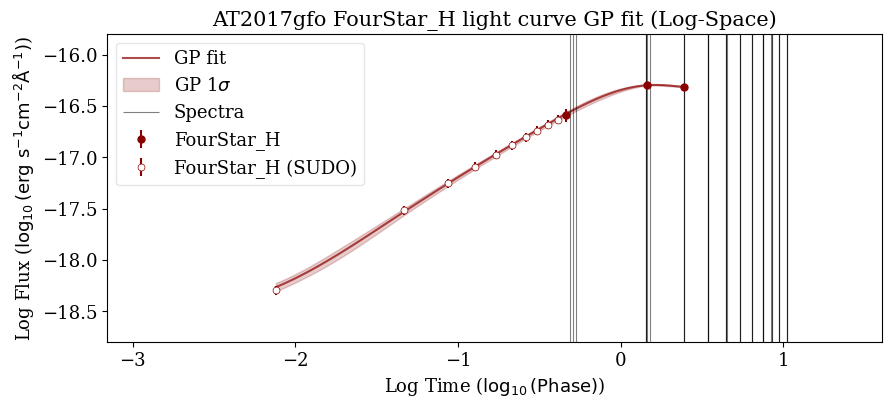

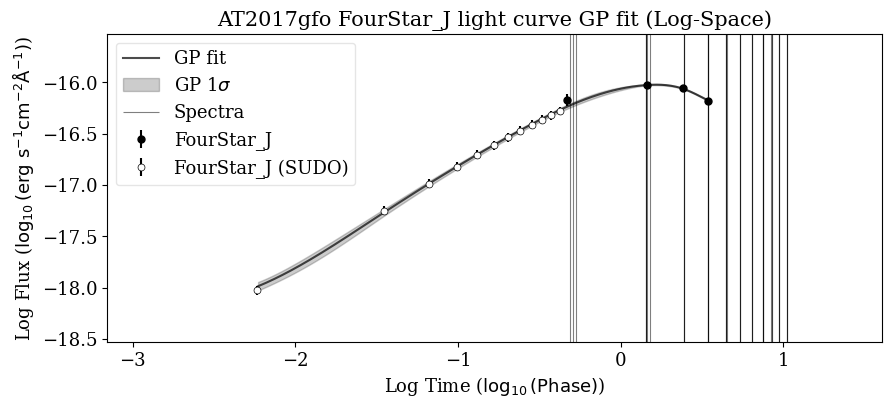

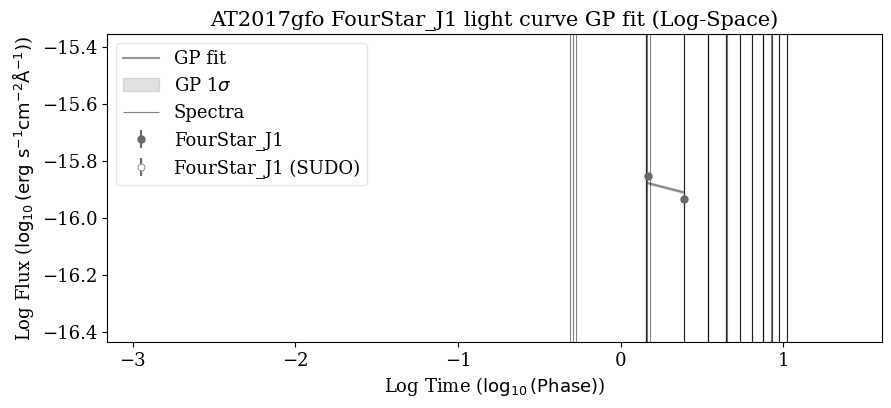

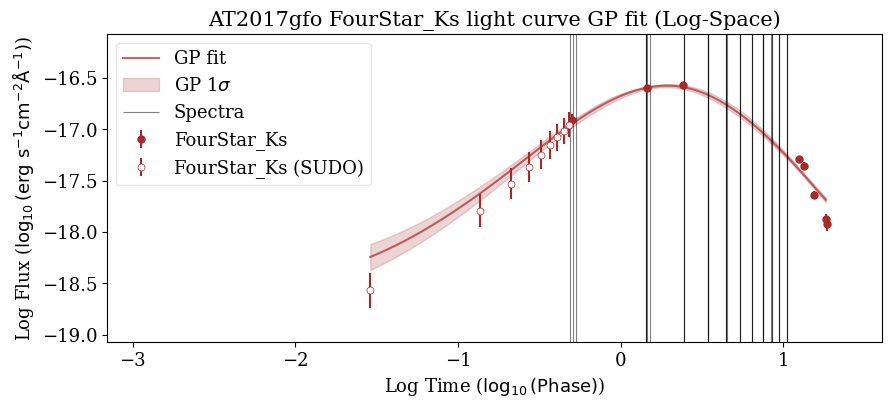

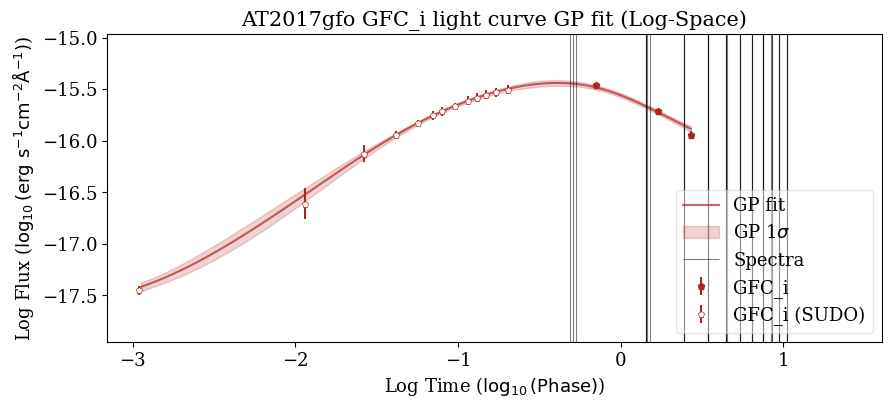

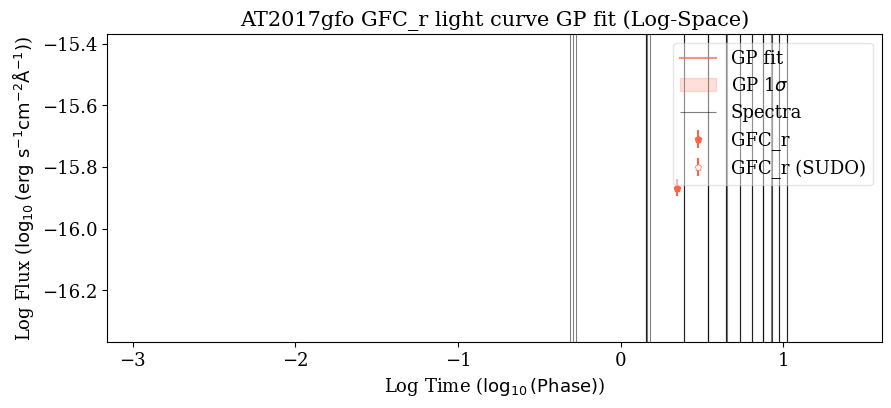

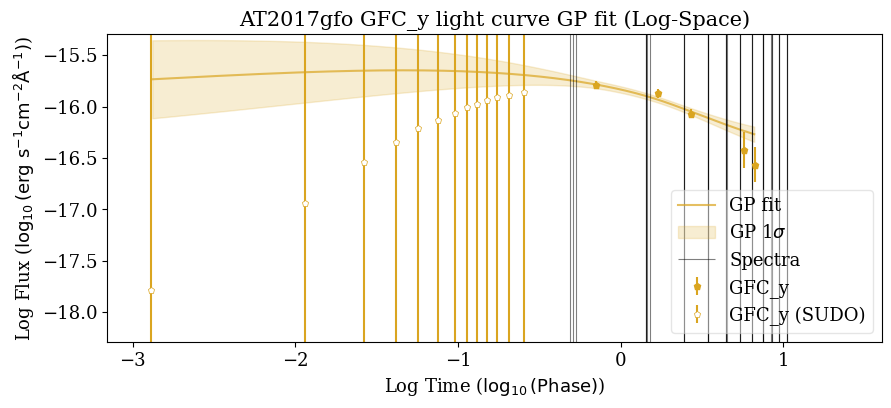

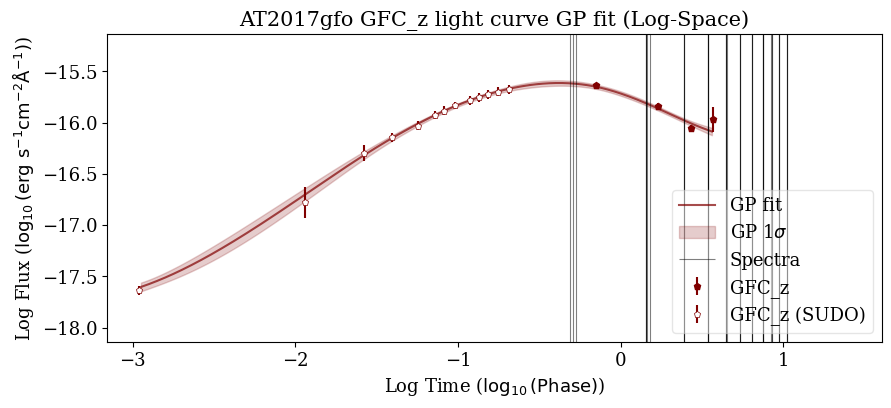

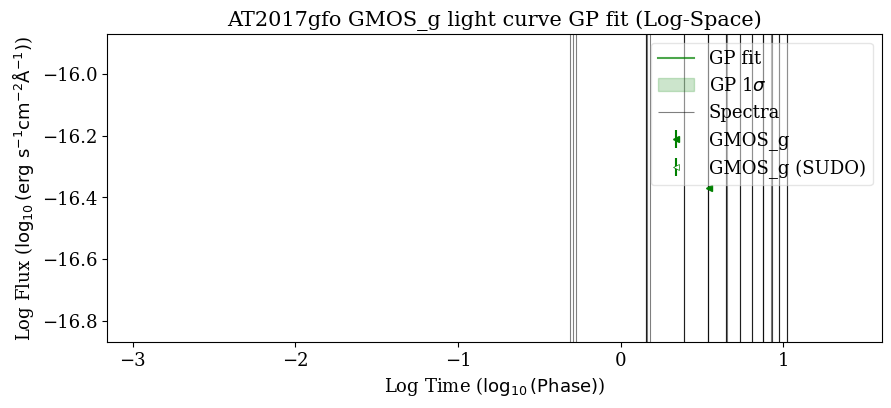

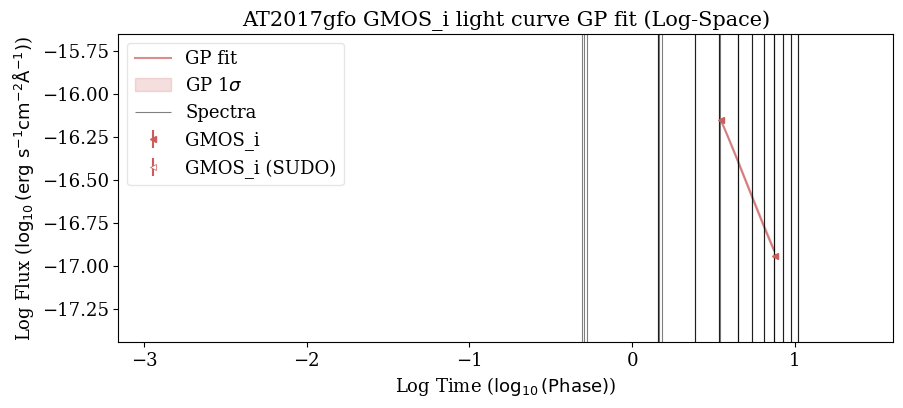

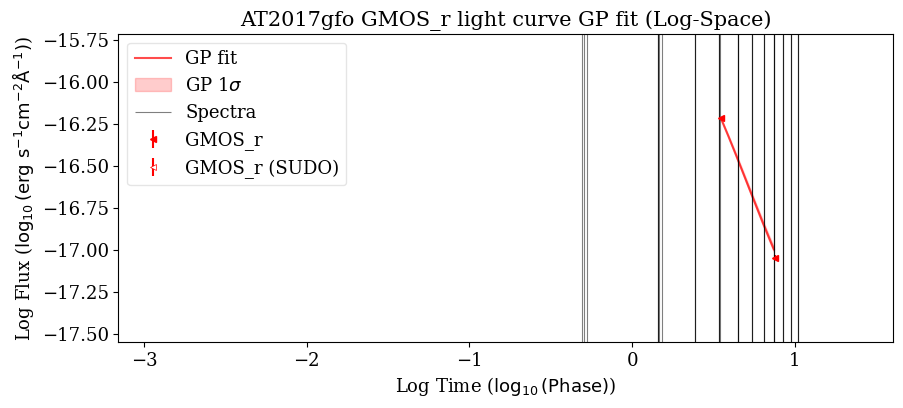

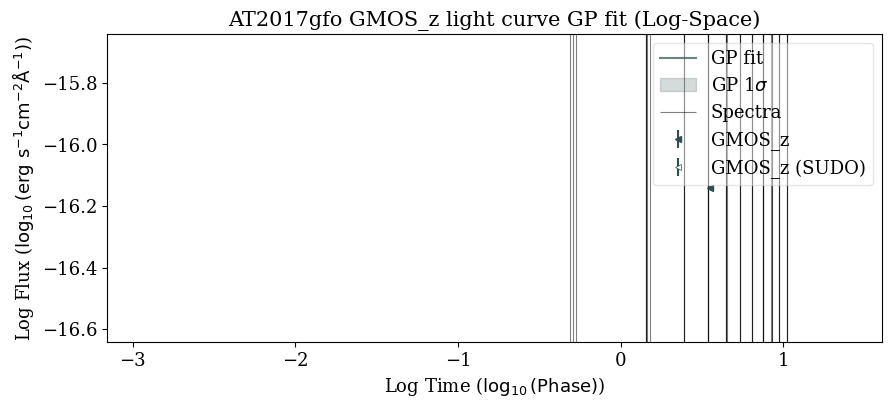

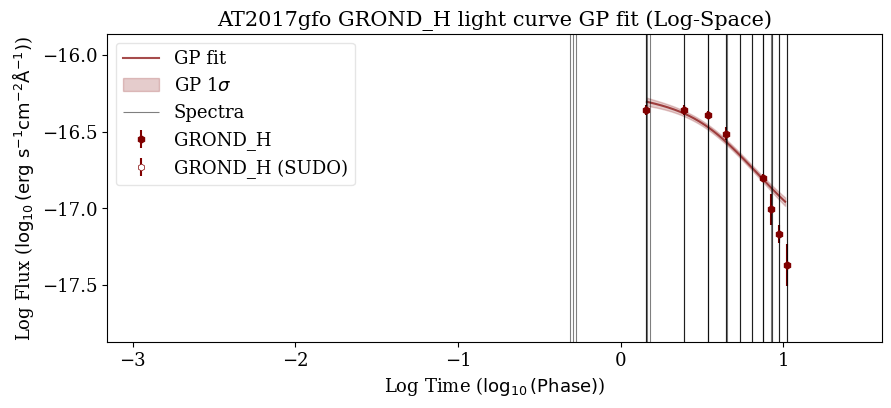

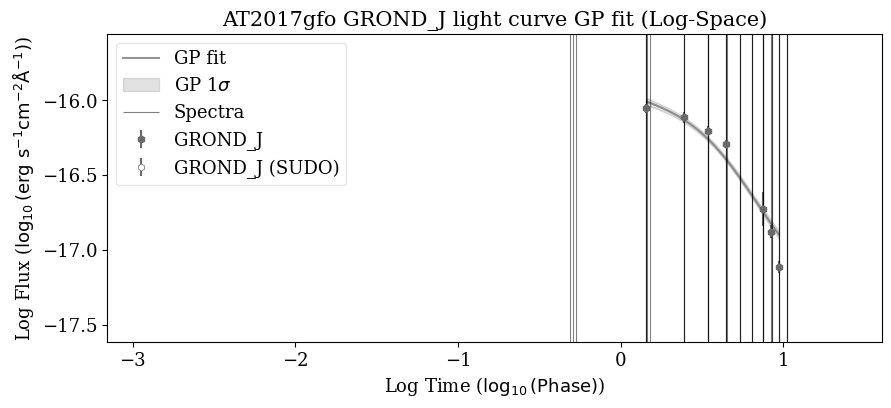

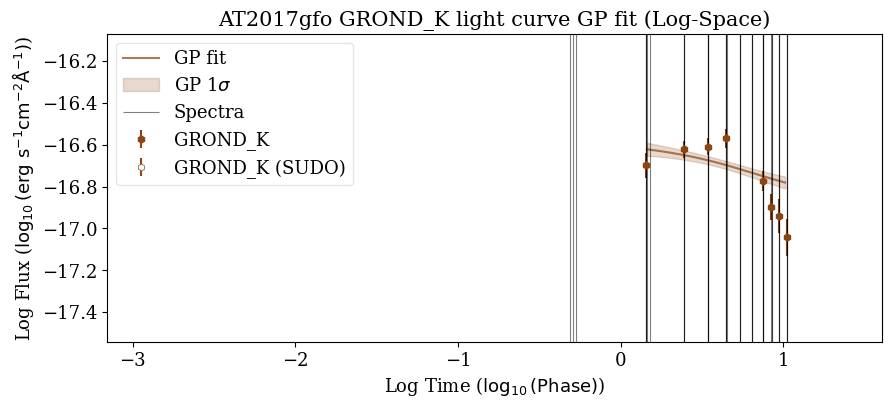

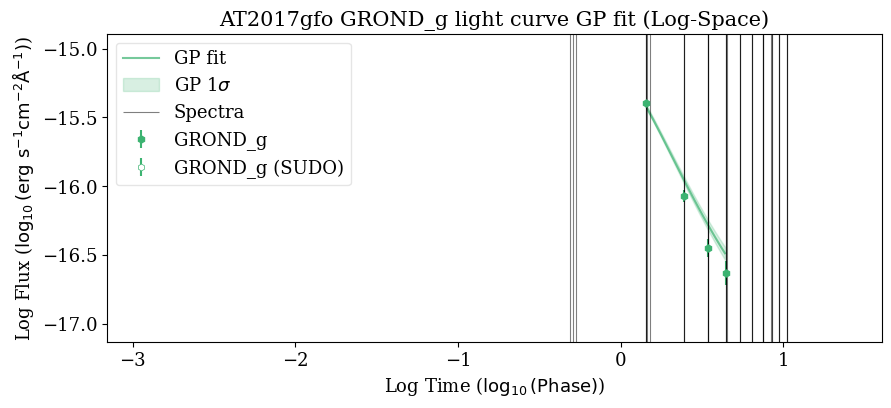

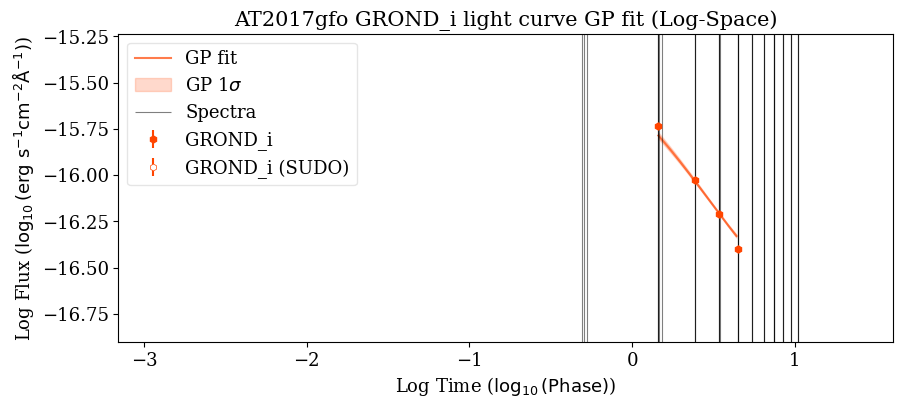

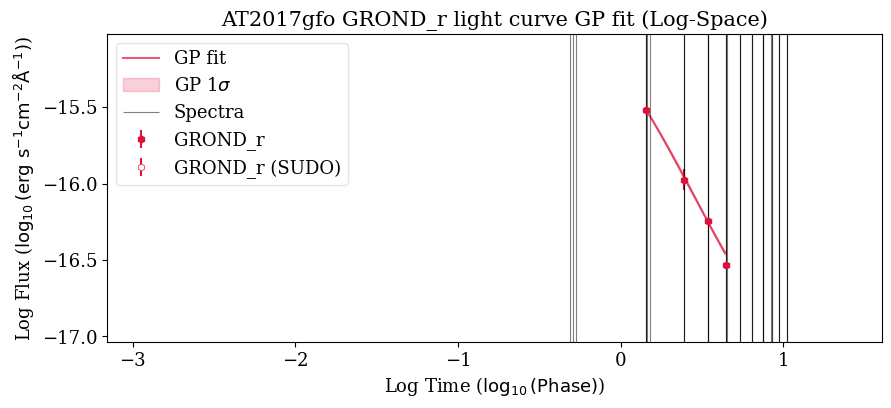

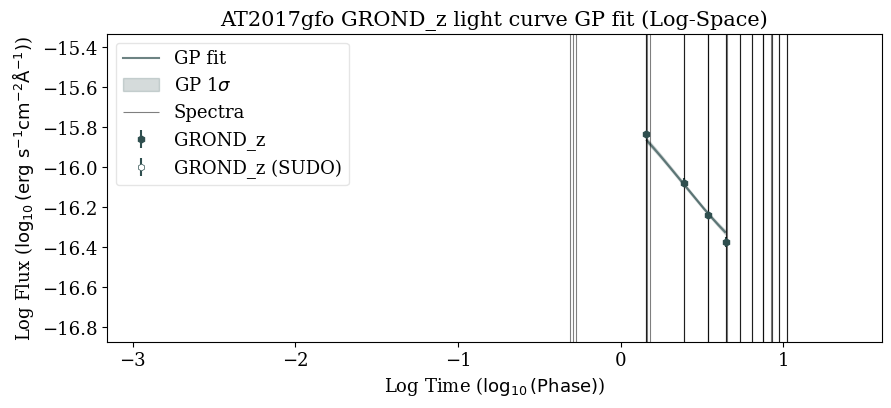

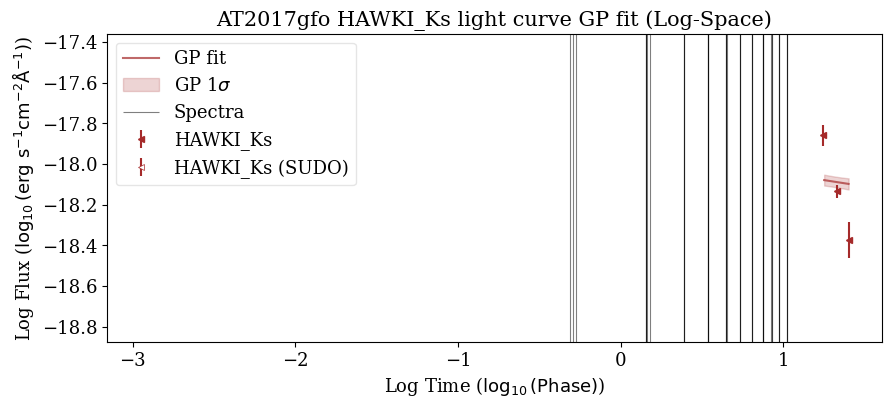

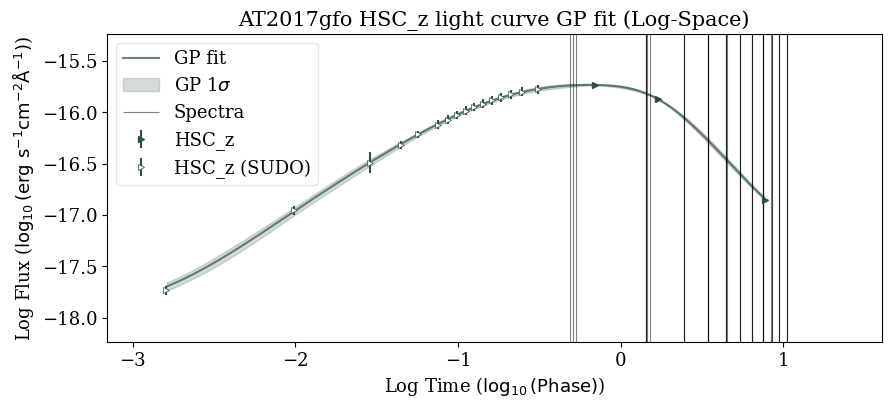

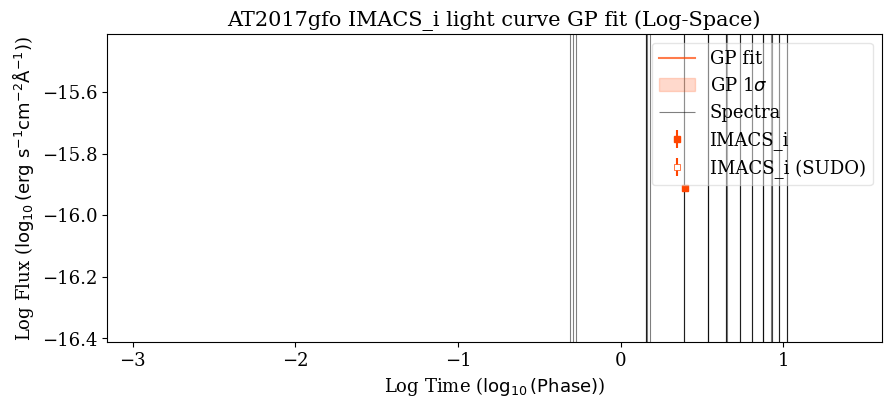

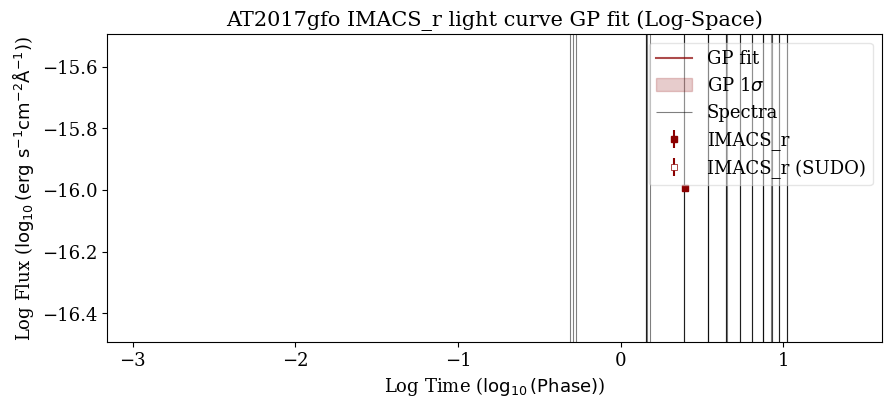

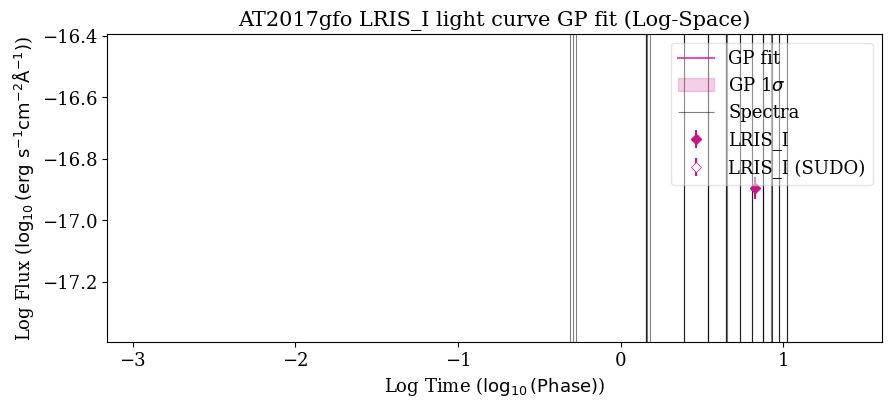

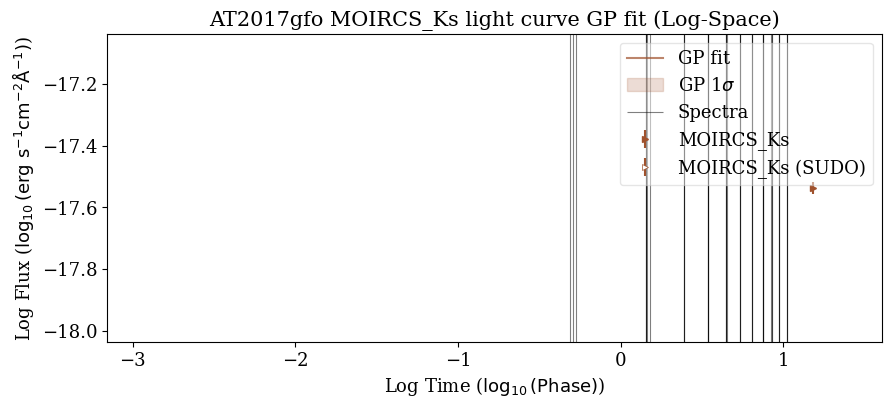

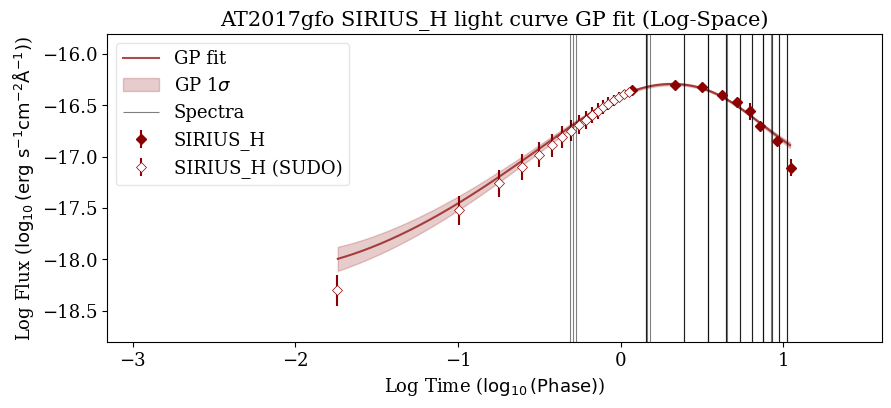

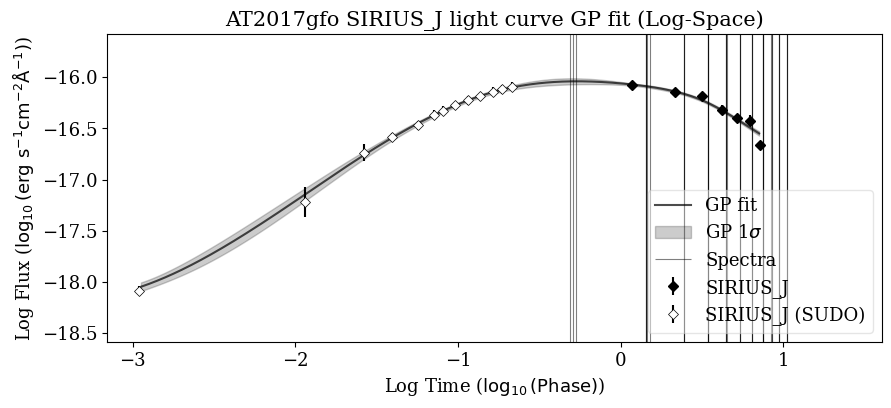

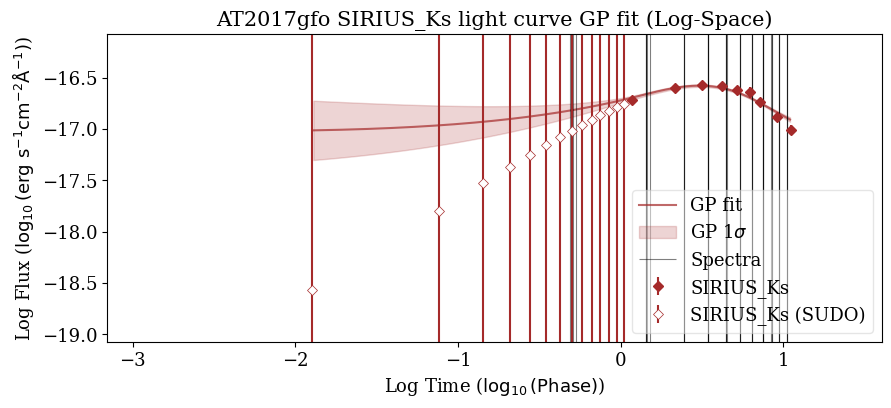

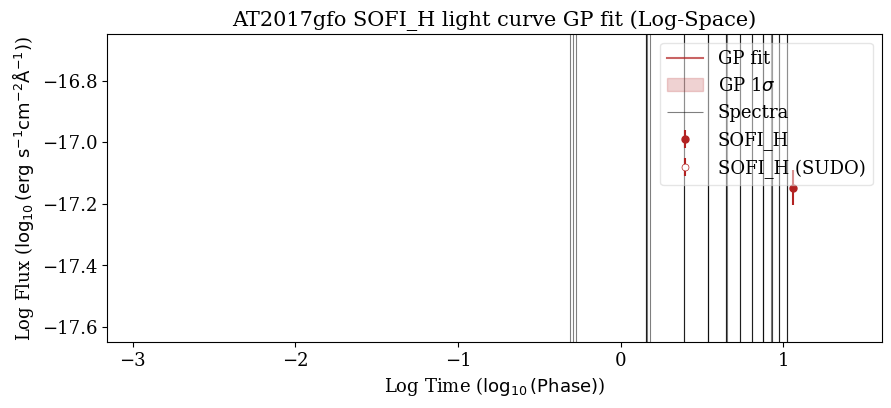

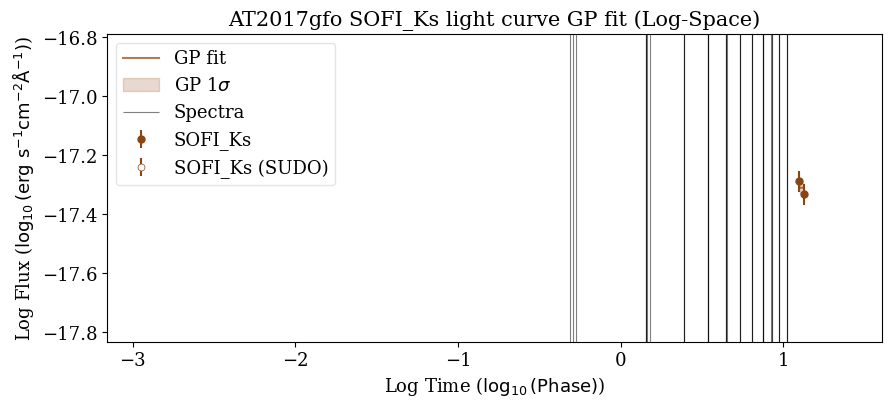

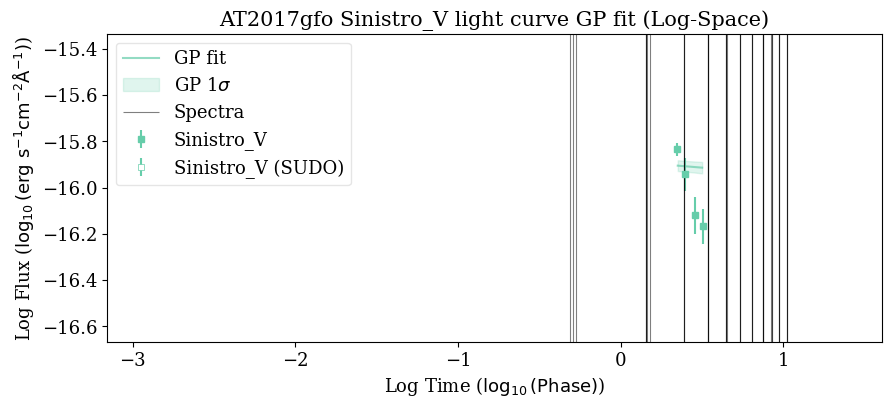

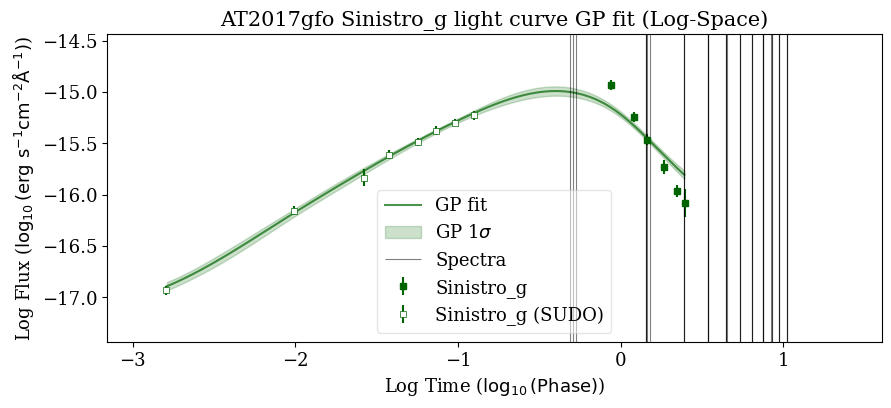

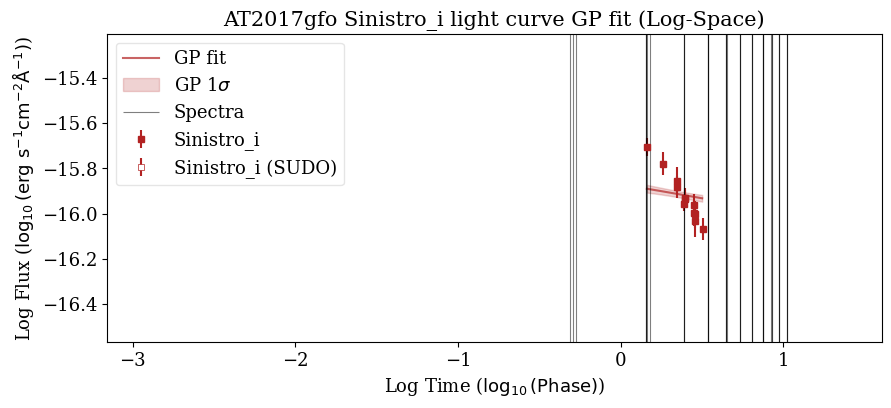

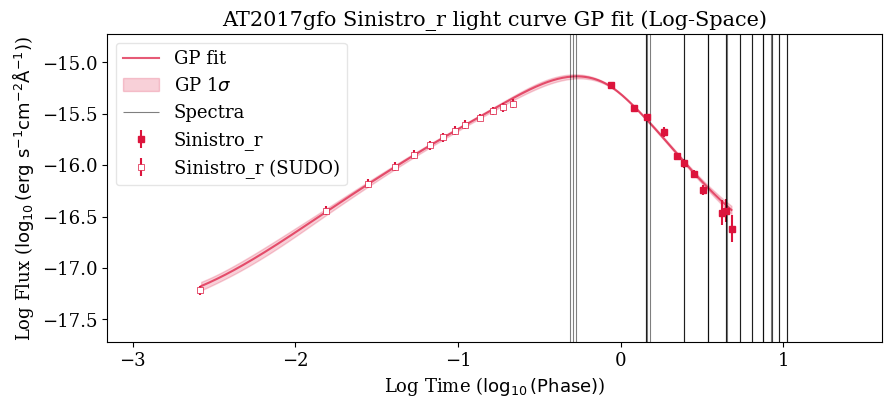

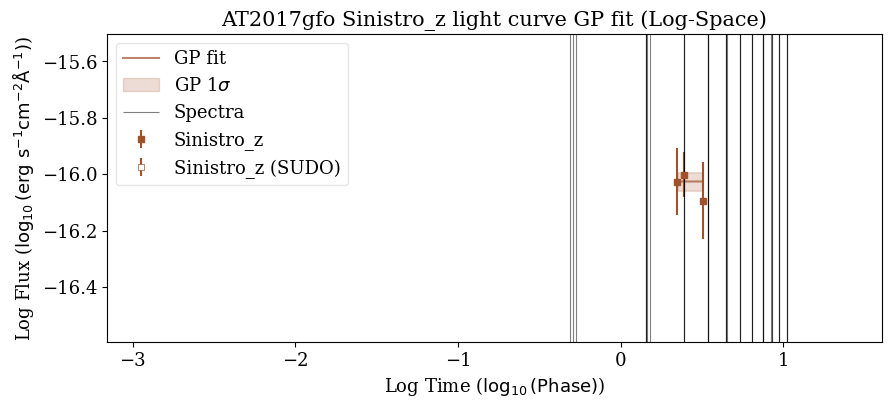

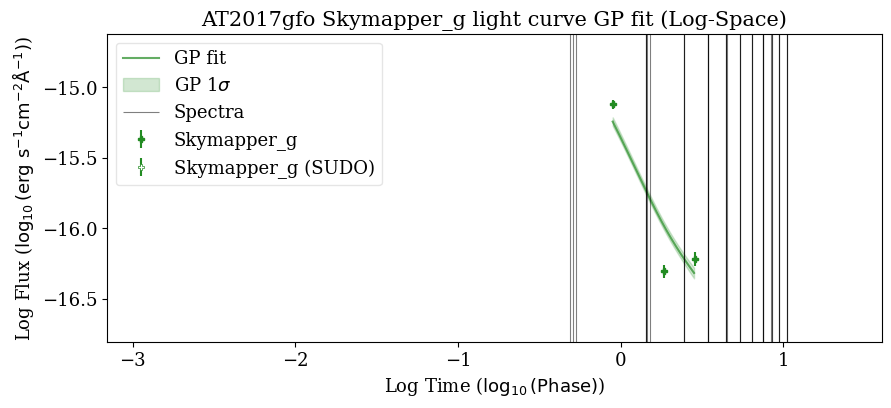

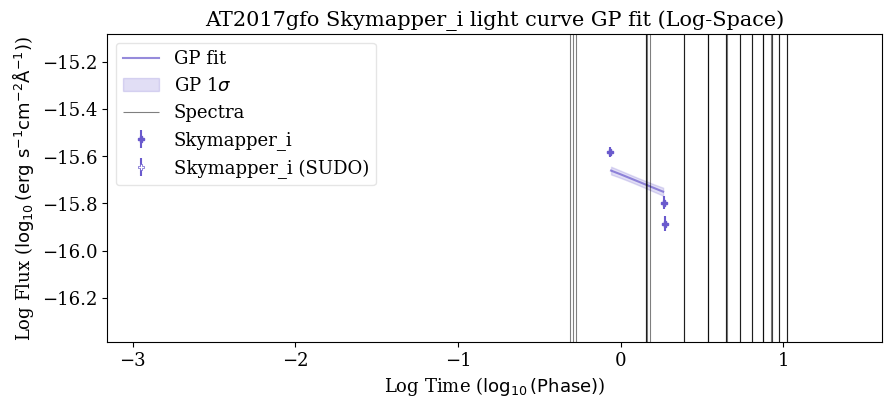

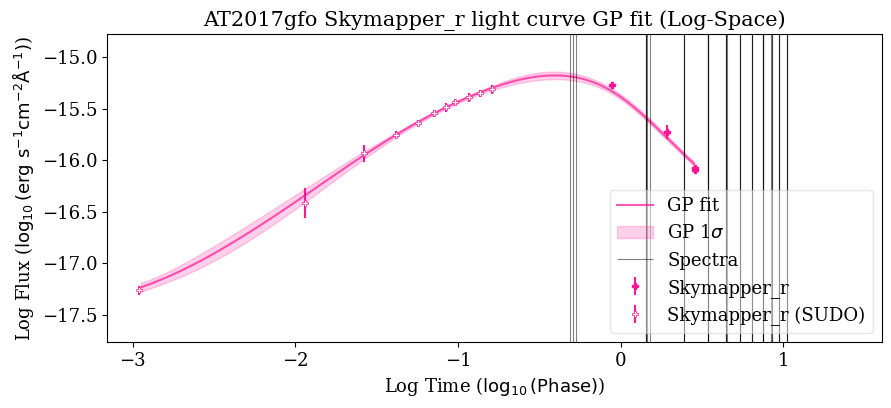

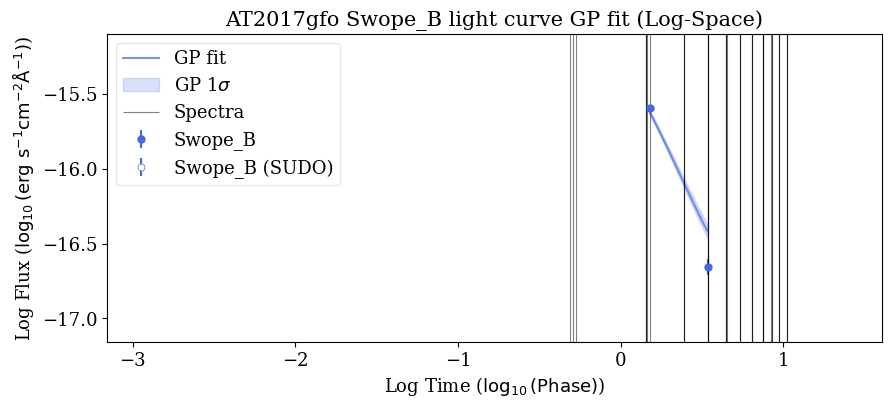

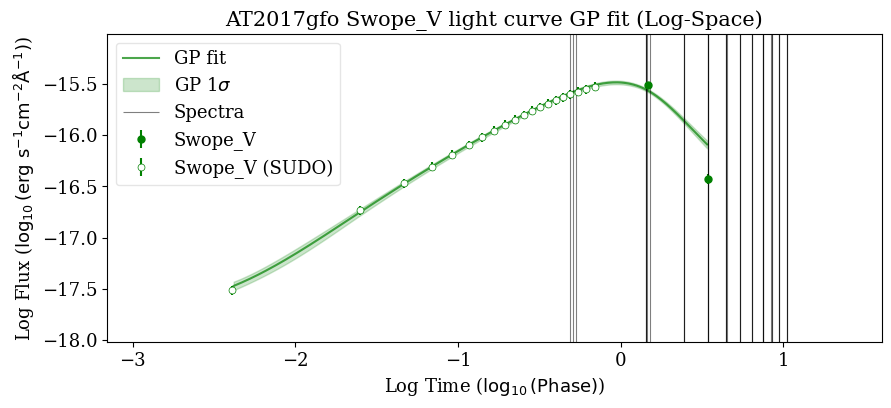

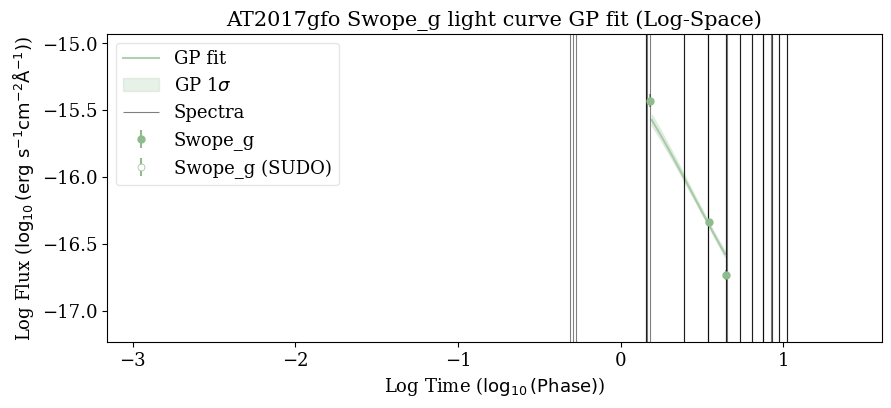

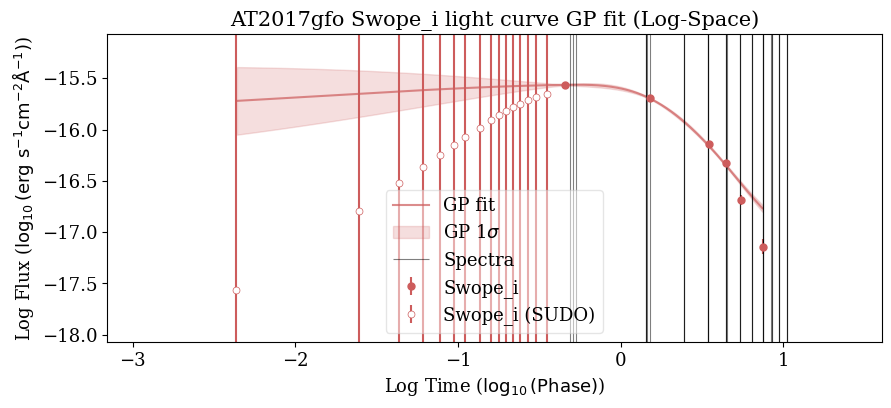

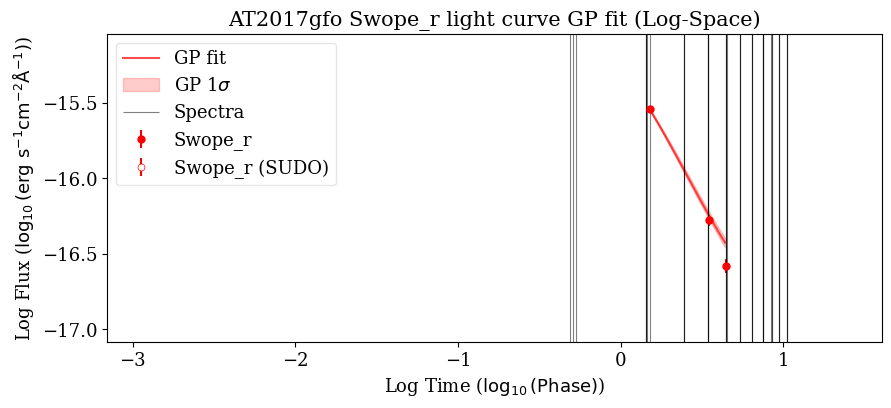

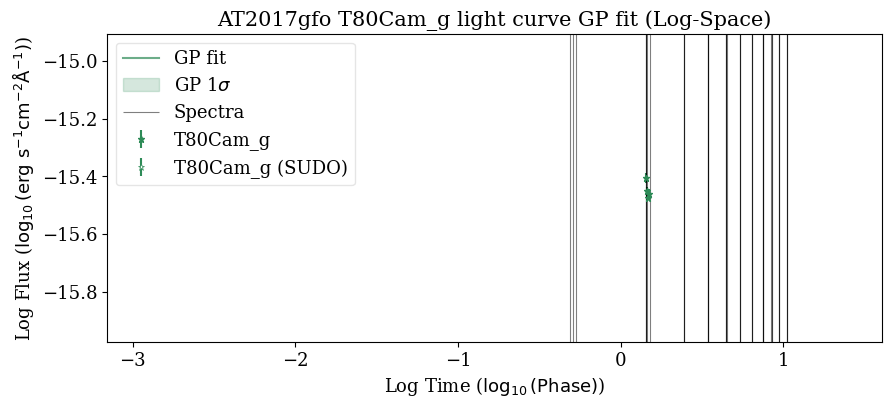

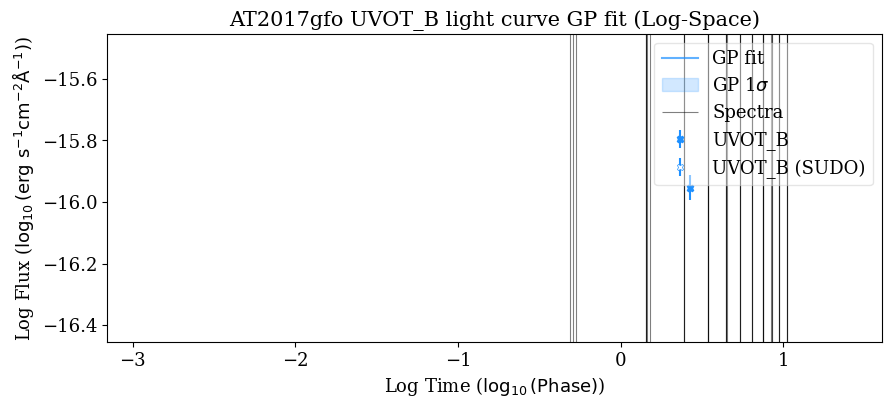

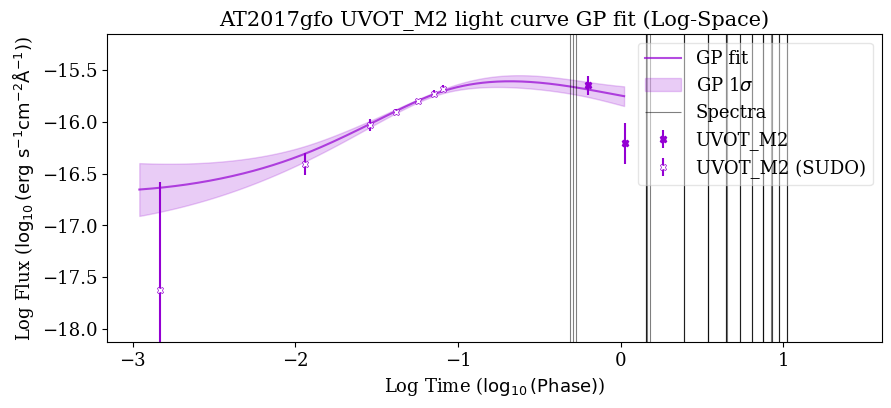

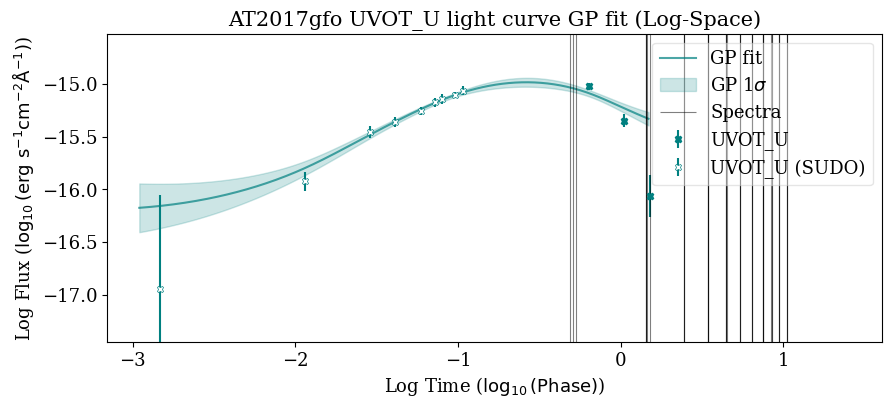

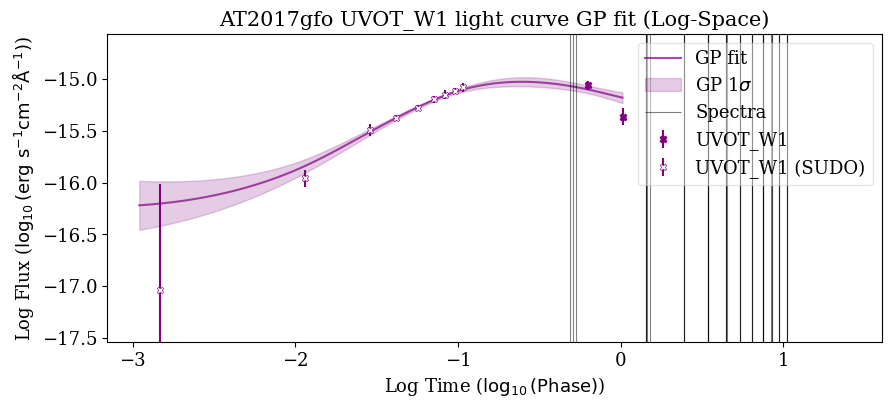

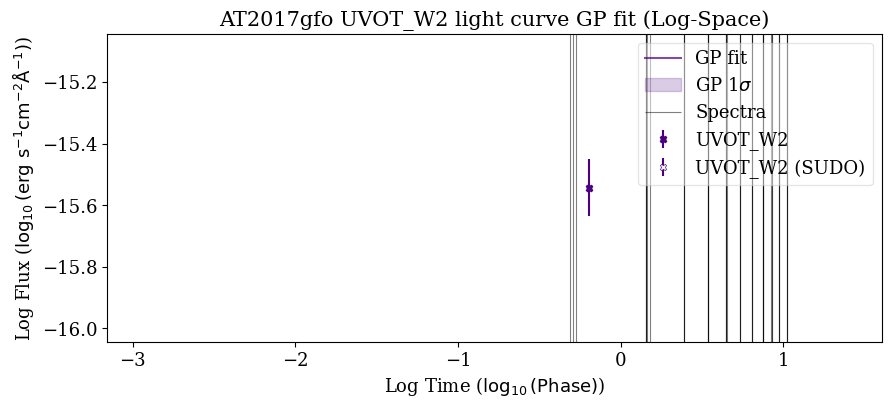

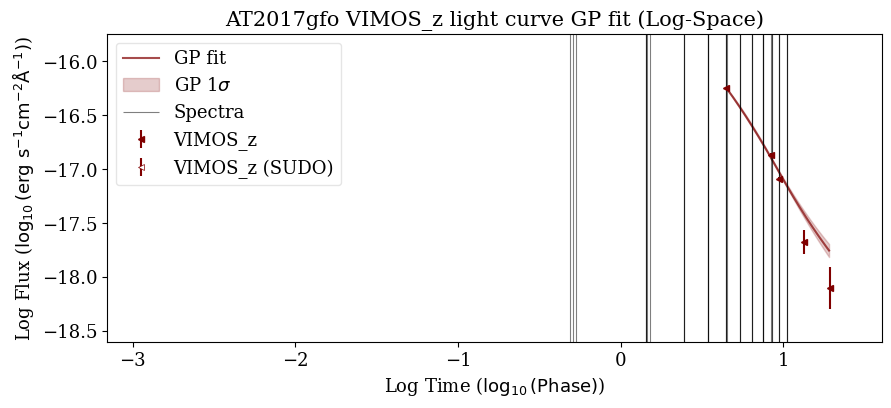

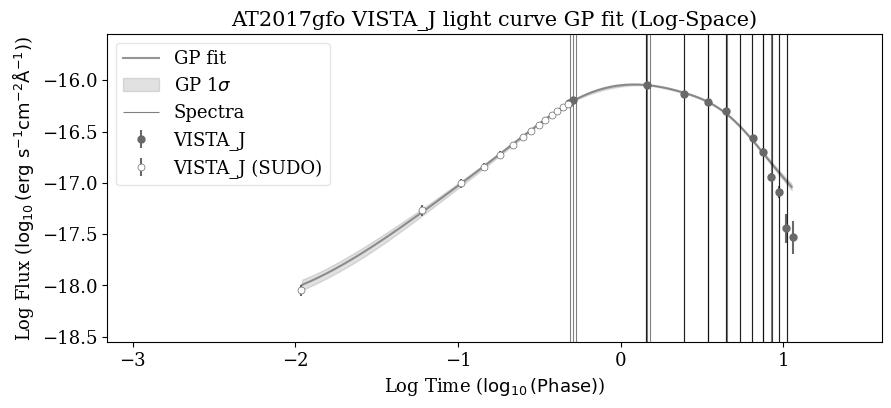

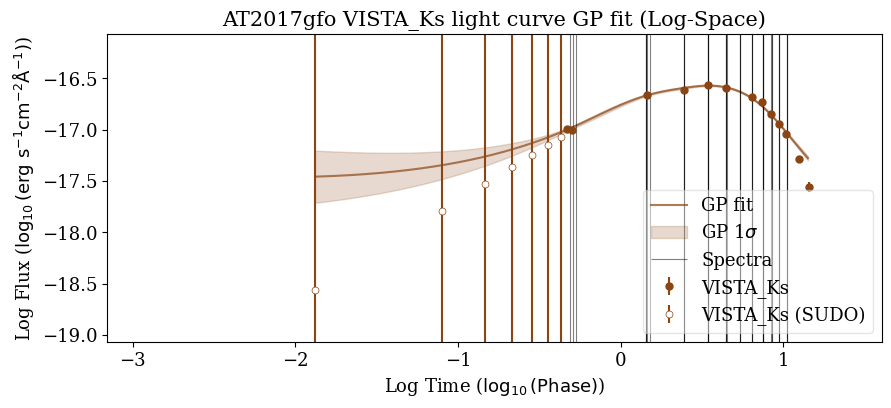

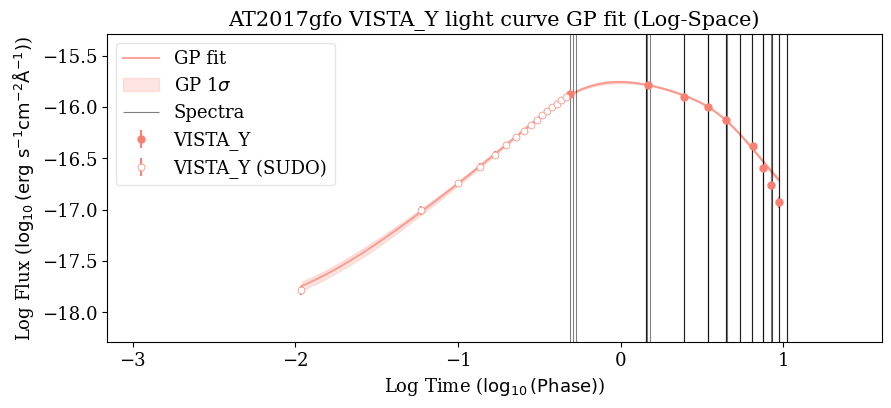

In [18]:
# Get global min/max Log_Phase for all filters for consistent x-axis
# In log-space, +/- 2 is a massive jump (two orders of magnitude), so we pad with +/- 0.2 instead
all_log_phase = np.concatenate([SN.fitted_phot[f]['clipped_extended_data'][0] for f in SN.avail_filters])
xmin = np.min(all_log_phase) - 0.2 
xmax = np.max(all_log_phase) + 0.2

for f in SN.avail_filters:
    fig = plt.figure(figsize=(10, 4))
    plt.rc('font', family='serif')
    plt.rc('xtick', labelsize=13)
    plt.rc('ytick', labelsize=13)
    
    c = color_dict[f]
    
    # Update variables to unpack the new log-space arrays
    log_phase, log_flux, err_log_flux, sudo = SN.fitted_phot[f]['clipped_extended_data']
    hc_log_phase, hc_mu, hc_std = SN.fitted_phot[f]['fit_highcadence']
    
    if 'swift' in f:
        flabel = f.split('_')[1] + '(Swift)'
    else:
        flabel = f
        
    # Real points
    a = plt.errorbar(log_phase[~sudo], log_flux[~sudo], yerr=err_log_flux[~sudo],
                     fmt=mark_dict[f], mfc=c, ms=5, color=c,
                     linestyle='None', label=flabel)
                     
    # SUDO points
    plt.errorbar(log_phase[sudo], log_flux[sudo], yerr=err_log_flux[sudo],
                 fmt=mark_dict[f], mfc='white', mec=c, ms=5, mew=0.5, color=c,
                 linestyle='None', label=flabel + ' (SUDO)')
                 
    # GP fit line and shaded error
    plt.plot(hc_log_phase, hc_mu, color=a[0].get_color(), label='GP fit', alpha=0.7)
    plt.fill_between(hc_log_phase, hc_mu - hc_std, hc_mu + hc_std, color=a[0].get_color(), alpha=0.2, label='GP 1$\sigma$')
    
    # Spectra lines
    if len(log_flux) > 0:
        # Safely pad Y-limits using addition/subtraction since log values are negative
        ymin = min(log_flux) - 0.5
        ymax = max(log_flux) + 0.5
        
        # Use the newly created log-phase method for spectra
        spec_log_phases = SN.get_spec_log_phase()
        if len(spec_log_phases) > 0:
            plt.vlines(spec_log_phases, ymin, ymax, linestyle='-', alpha=0.5, lw=0.8, color='k', label='Spectra')
            
        plt.ylim(ymin, ymax)
        
    plt.xlabel(r'Log Time ($\log_{10}(\rm{Phase})$)', fontsize=13)
    plt.ylabel(r'Log Flux ($\log_{10}(\rm{erg \ s^{-1} cm^{-2} \AA^{-1}})$)', fontsize=13)
    plt.xlim(xmin, xmax)
    
    # plt.yscale('log') <--- REMOVED! The values are natively base-10 logs now.
    
    plt.legend(fontsize=13, loc='best', fancybox=True, framealpha=0.5)
    plt.title(f"{SN.snname} {flabel} light curve GP fit (Log-Space)", fontsize=15)
    plt.show()

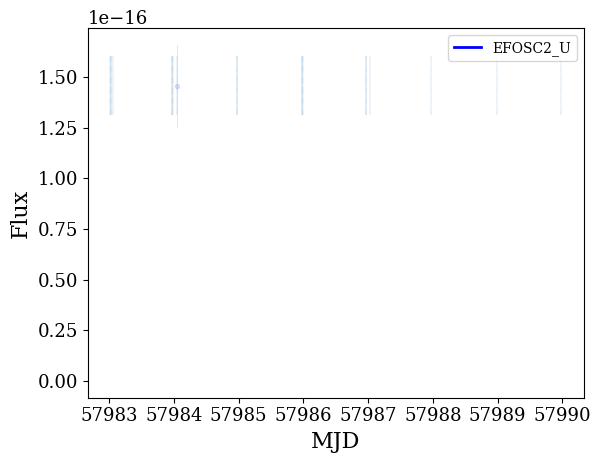

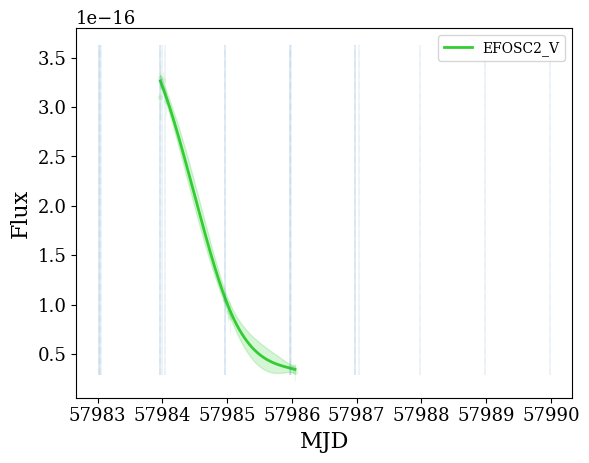

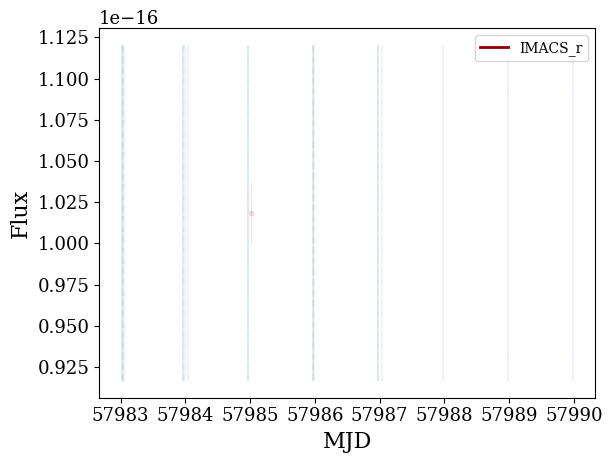

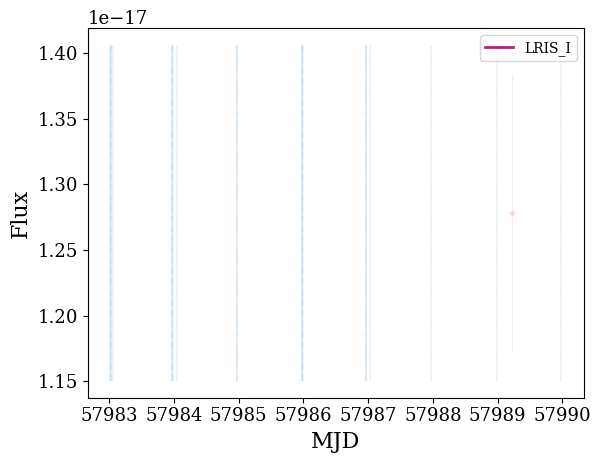

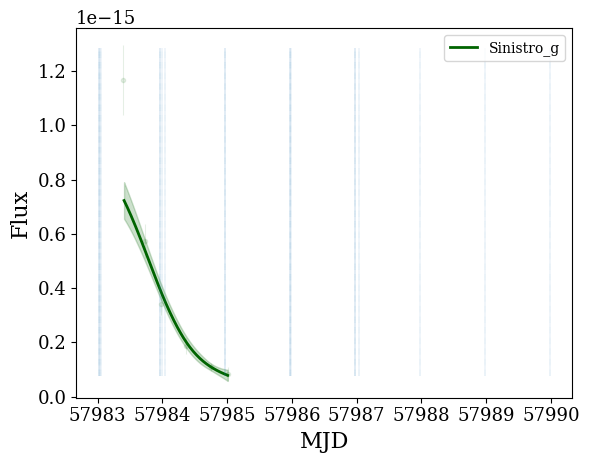

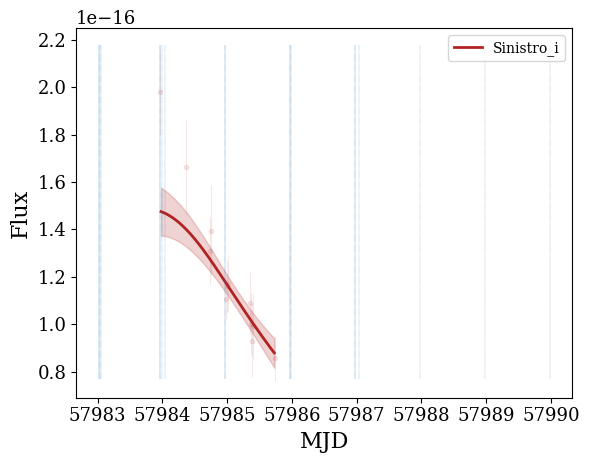

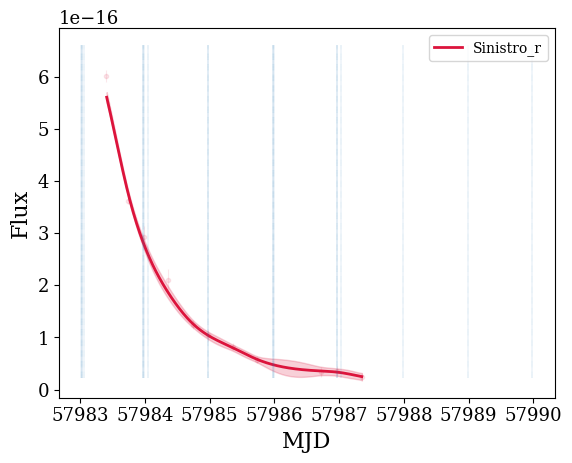

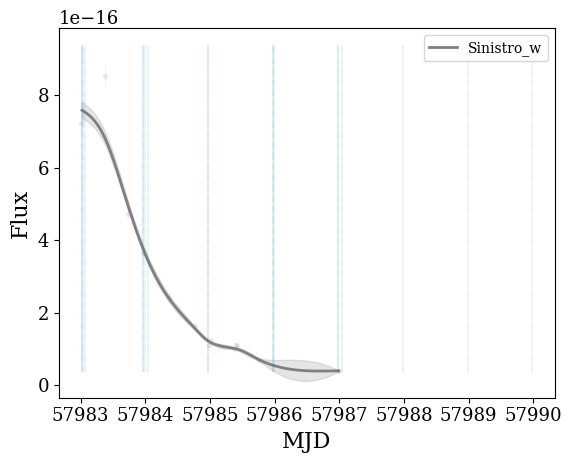

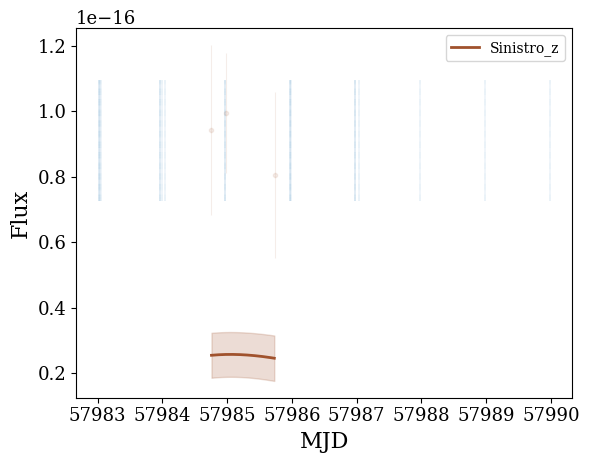

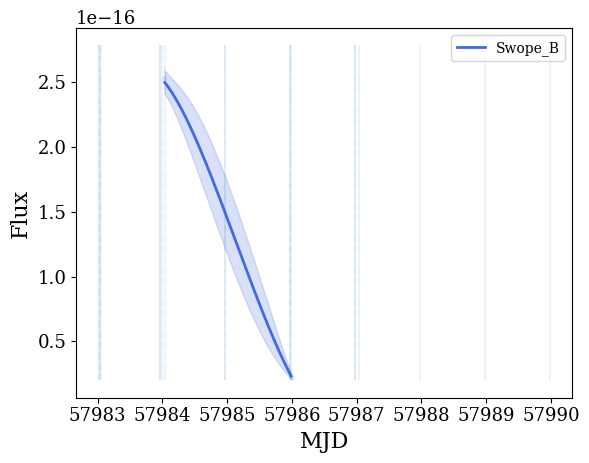

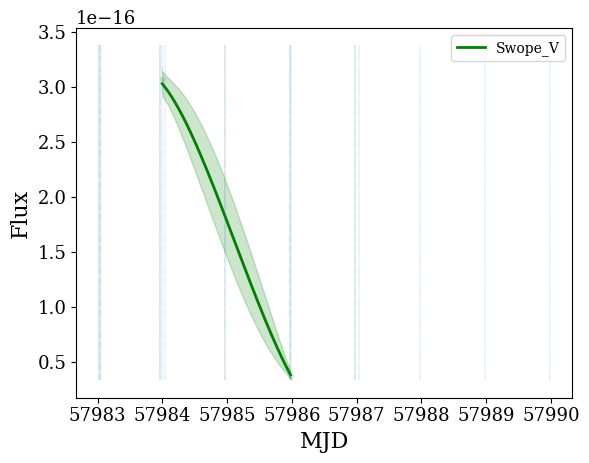

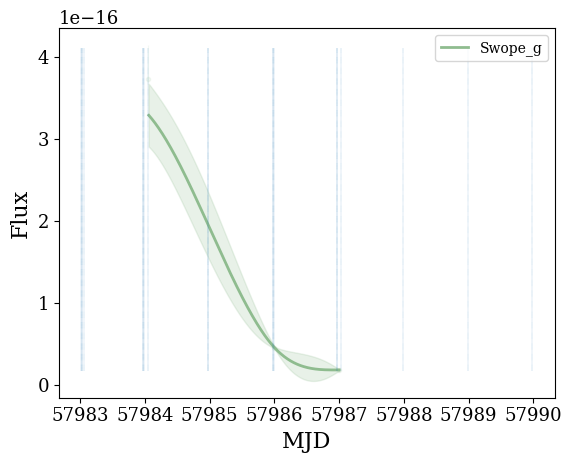

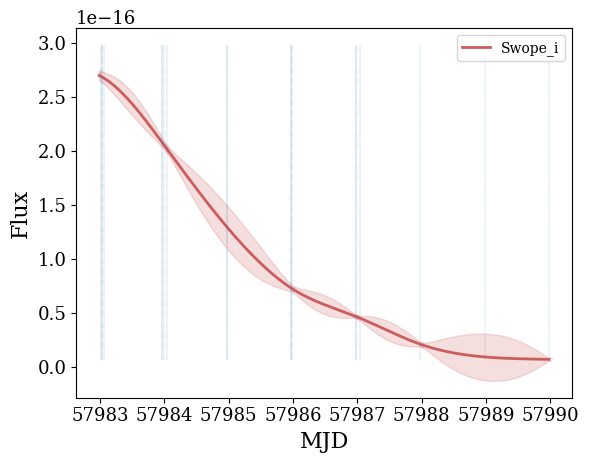

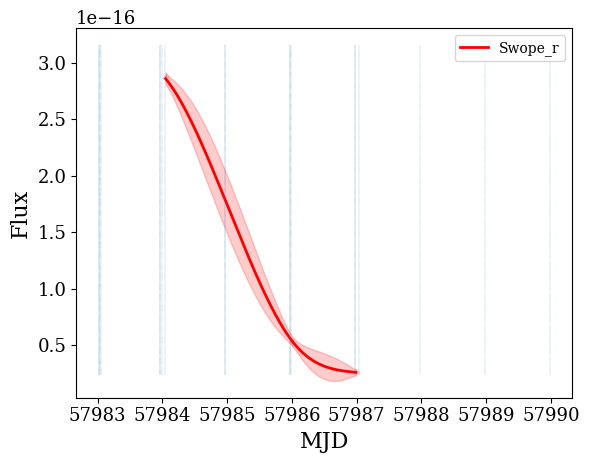

In [18]:
for f in SN.avail_filters:
    #fig = plt.figure(figsize=(10,3))
    c = color_dict[f]
    mjd, flux, err_flux, sudo = SN.fitted_phot[f]['clipped_extended_data'] 
    new_mjd, mu, std= SN.fitted_phot[f]['fit_highcadence'] 
    a=plt.errorbar(mjd[~sudo], flux[~sudo], yerr=err_flux[~sudo], fmt='.', mfc= c, \
               elinewidth=0.8, color= c,linestyle='None', alpha=0.1)
    a=plt.errorbar(mjd[sudo], flux[sudo], yerr=err_flux[sudo], fmt='o', mfc='None', \
               mec=c, elinewidth=0.8, color= c,linestyle='None', alpha=0.05)
    
    plt.plot(new_mjd, mu, color=a[0].get_color(), lw=2.,  label=f)
    plt.fill_between(new_mjd, (mu+std), (mu-std), color=a[0].get_color(), alpha=0.2)
    plt.vlines(SN.get_spec_mjd(), min(flux)*0.9, 1.1*max(flux), linestyle=':', lw=0.3)
    plt.xlabel('MJD', fontsize=16)
    plt.ylabel('Flux', fontsize=16)
    plt.legend()
    plt.show()